# 😊 Klasifikasi Emosi Wajah — GLCM + Logistic Regression
### Versi Lengkap · Visualisasi Step-by-Step · Sesuai Spesifikasi Tugas

---

**Dataset:** Subset FER2013 (48×48 px, grayscale) — `angry, happy, sad, surprise`  
**Fitur:** Gray-Level Co-occurrence Matrix (GLCM) → Contrast, Homogeneity, Energy, Correlation  
**Model:** Logistic Regression (Softmax / OvR)  

---

## Alur Kerja Notebook

```
BAGIAN 0  ──  Setup & Import Library
BAGIAN 1  ──  Load Dataset + Preprocessing
              └── Visualisasi: Before/After + Histogram Pixel
BAGIAN 2  ──  Ekstraksi Fitur GLCM (Step-by-Step Lengkap)
              ├── STEP A: Gambar Asli
              ├── STEP B: Kuantisasi & Matriks Keabuan
              ├── STEP C: Matriks Koheren (Overview)
              ├── STEP D: 4 GLCM per Sudut (Heatmap + Angka)
              ├── STEP E: Matriks Koheren Final + Tabel Fitur
              └── STEP F: Visualisasi Interpretatif (Mengapa nilai segitu?)
BAGIAN 3  ──  Pemodelan Logistic Regression
              ├── Cara Kerja LR Step-by-Step (Visualisasi)
              ├── Decision Boundary (PCA 2D)
              ├── Bobot Model (Coefficient Heatmap)
              └── Distribusi Probabilitas
BAGIAN 4  ──  Evaluasi Lengkap (6 Skenario)
              ├── Classification Report
              ├── Confusion Matrix
              ├── Perbandingan 6 Skenario
              └── Error Analysis
BAGIAN 5  ──  Analisis Wajib (Jawaban 5 Pertanyaan Tugas)
```


---
# BAGIAN 0 — Setup & Import Library

| Library | Fungsi |
|---|---|
| `numpy` | Komputasi array pixel, statistik |
| `matplotlib` / `seaborn` | Semua visualisasi |
| `PIL` / `cv2` | Buka gambar, filter Sobel |
| `skimage.feature` | `graycomatrix()` dan `graycoprops()` |
| `sklearn` | Logistic Regression, StandardScaler, PCA, t-SNE, metrik |
| `pickle` / `pathlib` | Simpan/muat cache fitur & model |


In [7]:
# ================================================================
#  CELL 0 — Import & Konfigurasi Global
# ================================================================
import os, glob, pickle, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

from PIL import Image
import cv2

from skimage.feature import graycomatrix, graycoprops

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

# ── Tampilan global ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 130,
    'font.size'       : 11,
    'axes.titlesize'  : 12,
    'axes.spines.top' : False,
    'axes.spines.right': False,
})
sns.set_palette('husl')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Konstanta dataset & GLCM ────────────────────────────────────
BASE_DIR  = 'dataset'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

CLASSES        = ['angry', 'happy', 'sad', 'surprise']
COLORS         = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
IMG_SIZE       = (48, 48)
DISTANCES      = [1]
ANGLES         = [0, np.pi/4, np.pi/2, 3*np.pi/4]
ANGLE_LABELS   = ['0°', '45°', '90°', '135°']
LEVELS_TO_TEST = [8, 16, 32]
GLCM_PROPS     = ['contrast', 'homogeneity', 'energy', 'correlation']

# ── Folder output ────────────────────────────────────────────────
OUT_ROOT    = Path('outputs')
OUT_PREPROC = OUT_ROOT / 'preprocessed'
OUT_FEAT    = OUT_ROOT / 'features'
OUT_MODELS  = OUT_ROOT / 'models'
OUT_FIGS    = OUT_ROOT / 'figures'
for f in [OUT_PREPROC, OUT_FEAT, OUT_MODELS, OUT_FIGS]:
    f.mkdir(parents=True, exist_ok=True)

print("✅ Setup selesai! Folder output berhasil dibuat.")
print(f"   GLCM Properties  : {GLCM_PROPS}")
print(f"   Levels to test   : {LEVELS_TO_TEST}")
print(f"   Angles (rad)     : {[round(a,4) for a in ANGLES]}")


✅ Setup selesai! Folder output berhasil dibuat.
   GLCM Properties  : ['contrast', 'homogeneity', 'energy', 'correlation']
   Levels to test   : [8, 16, 32]
   Angles (rad)     : [0, 0.7854, 1.5708, 2.3562]


---
# BAGIAN 1 — Load Dataset & Preprocessing

## Tahapan Preprocessing

| # | Operasi | Alasan |
|---|---|---|
| 1 | Buka dengan PIL | Format universal |
| 2 | Konversi Grayscale `'L'` | GLCM butuh array 2D 1-channel |
| 3 | Resize 48×48 LANCZOS | Seragamkan dimensi, kualitas terbaik |
| 4 | Simpan `uint8` [0–255] | Referensi asli & visualisasi |
| 5 | Normalisasi `/255.0` → float32 | Input GLCM skala [0,1] |

> **Mengapa menyimpan cache `.npy`?** Setelah ekstraksi fitur (proses berat), simpan ke disk  
> sehingga jika notebook di-restart kita langsung load tanpa hitung ulang.


In [8]:
# ================================================================
#  CELL 1.1 — Fungsi Load, Preprocess, & Cache ke Disk
# ================================================================

def load_and_preprocess(data_dir, split_name, img_size=IMG_SIZE,
                         classes=CLASSES, force_reload=False):
    path_raw    = OUT_PREPROC / f'{split_name}_raw.npy'
    path_norm   = OUT_PREPROC / f'{split_name}_norm.npy'
    path_labels = OUT_PREPROC / f'{split_name}_labels.pkl'

    if not force_reload and path_raw.exists():
        print(f"  📦 Memuat '{split_name}' dari cache...")
        images_raw  = list(np.load(str(path_raw),  allow_pickle=True))
        images_norm = list(np.load(str(path_norm), allow_pickle=True))
        with open(path_labels, 'rb') as f:
            labels = pickle.load(f)
        print(f"     ✅ {len(labels)} gambar dimuat.")
        return images_raw, images_norm, labels

    print(f"  🔄 Memproses '{split_name}'...")
    images_raw, images_norm, labels = [], [], []
    for cls in classes:
        folder_path = os.path.join(data_dir, cls)
        img_paths   = (glob.glob(os.path.join(folder_path, '*.jpg')) +
                       glob.glob(os.path.join(folder_path, '*.png')))
        print(f"     [{cls:>10}]: {len(img_paths)} gambar")
        for img_path in img_paths:
            try:
                img      = Image.open(img_path).convert('L')
                img      = img.resize(img_size, Image.LANCZOS)
                arr_raw  = np.array(img, dtype=np.uint8)
                arr_norm = arr_raw.astype(np.float32) / 255.0
                images_raw.append(arr_raw)
                images_norm.append(arr_norm)
                labels.append(cls)
            except Exception as e:
                print(f"     ⚠️  Skip: {img_path} ({e})")

    np.save(str(path_raw),  np.array(images_raw,  dtype=object))
    np.save(str(path_norm), np.array(images_norm, dtype=object))
    with open(path_labels, 'wb') as f:
        pickle.dump(labels, f)
    print(f"     💾 Disimpan ({len(labels)} gambar)")
    return images_raw, images_norm, labels


print("📂 LOADING DATASET:")
train_raw, train_norm, train_labels = load_and_preprocess(TRAIN_DIR, 'train')
test_raw,  test_norm,  test_labels  = load_and_preprocess(TEST_DIR,  'test')

print(f"\n📊 Ringkasan:")
print(f"   Training : {len(train_labels)} gambar")
print(f"   Test     : {len(test_labels)} gambar")
print(f"   Shape    : {train_raw[0].shape} per gambar")

# Distribusi kelas
from collections import Counter
tr_dist = Counter(train_labels)
te_dist = Counter(test_labels)
print("\n   Distribusi Training :", {k: tr_dist[k] for k in CLASSES})
print("   Distribusi Test     :", {k: te_dist[k] for k in CLASSES})


📂 LOADING DATASET:
  🔄 Memproses 'train'...
     [     angry]: 3100 gambar
     [     happy]: 3100 gambar
     [       sad]: 3100 gambar
     [  surprise]: 3100 gambar
     💾 Disimpan (12400 gambar)
  🔄 Memproses 'test'...
     [     angry]: 775 gambar
     [     happy]: 775 gambar
     [       sad]: 775 gambar
     [  surprise]: 775 gambar
     💾 Disimpan (3100 gambar)

📊 Ringkasan:
   Training : 12400 gambar
   Test     : 3100 gambar
   Shape    : (48, 48) per gambar

   Distribusi Training : {'angry': 3100, 'happy': 3100, 'sad': 3100, 'surprise': 3100}
   Distribusi Test     : {'angry': 775, 'happy': 775, 'sad': 775, 'surprise': 775}


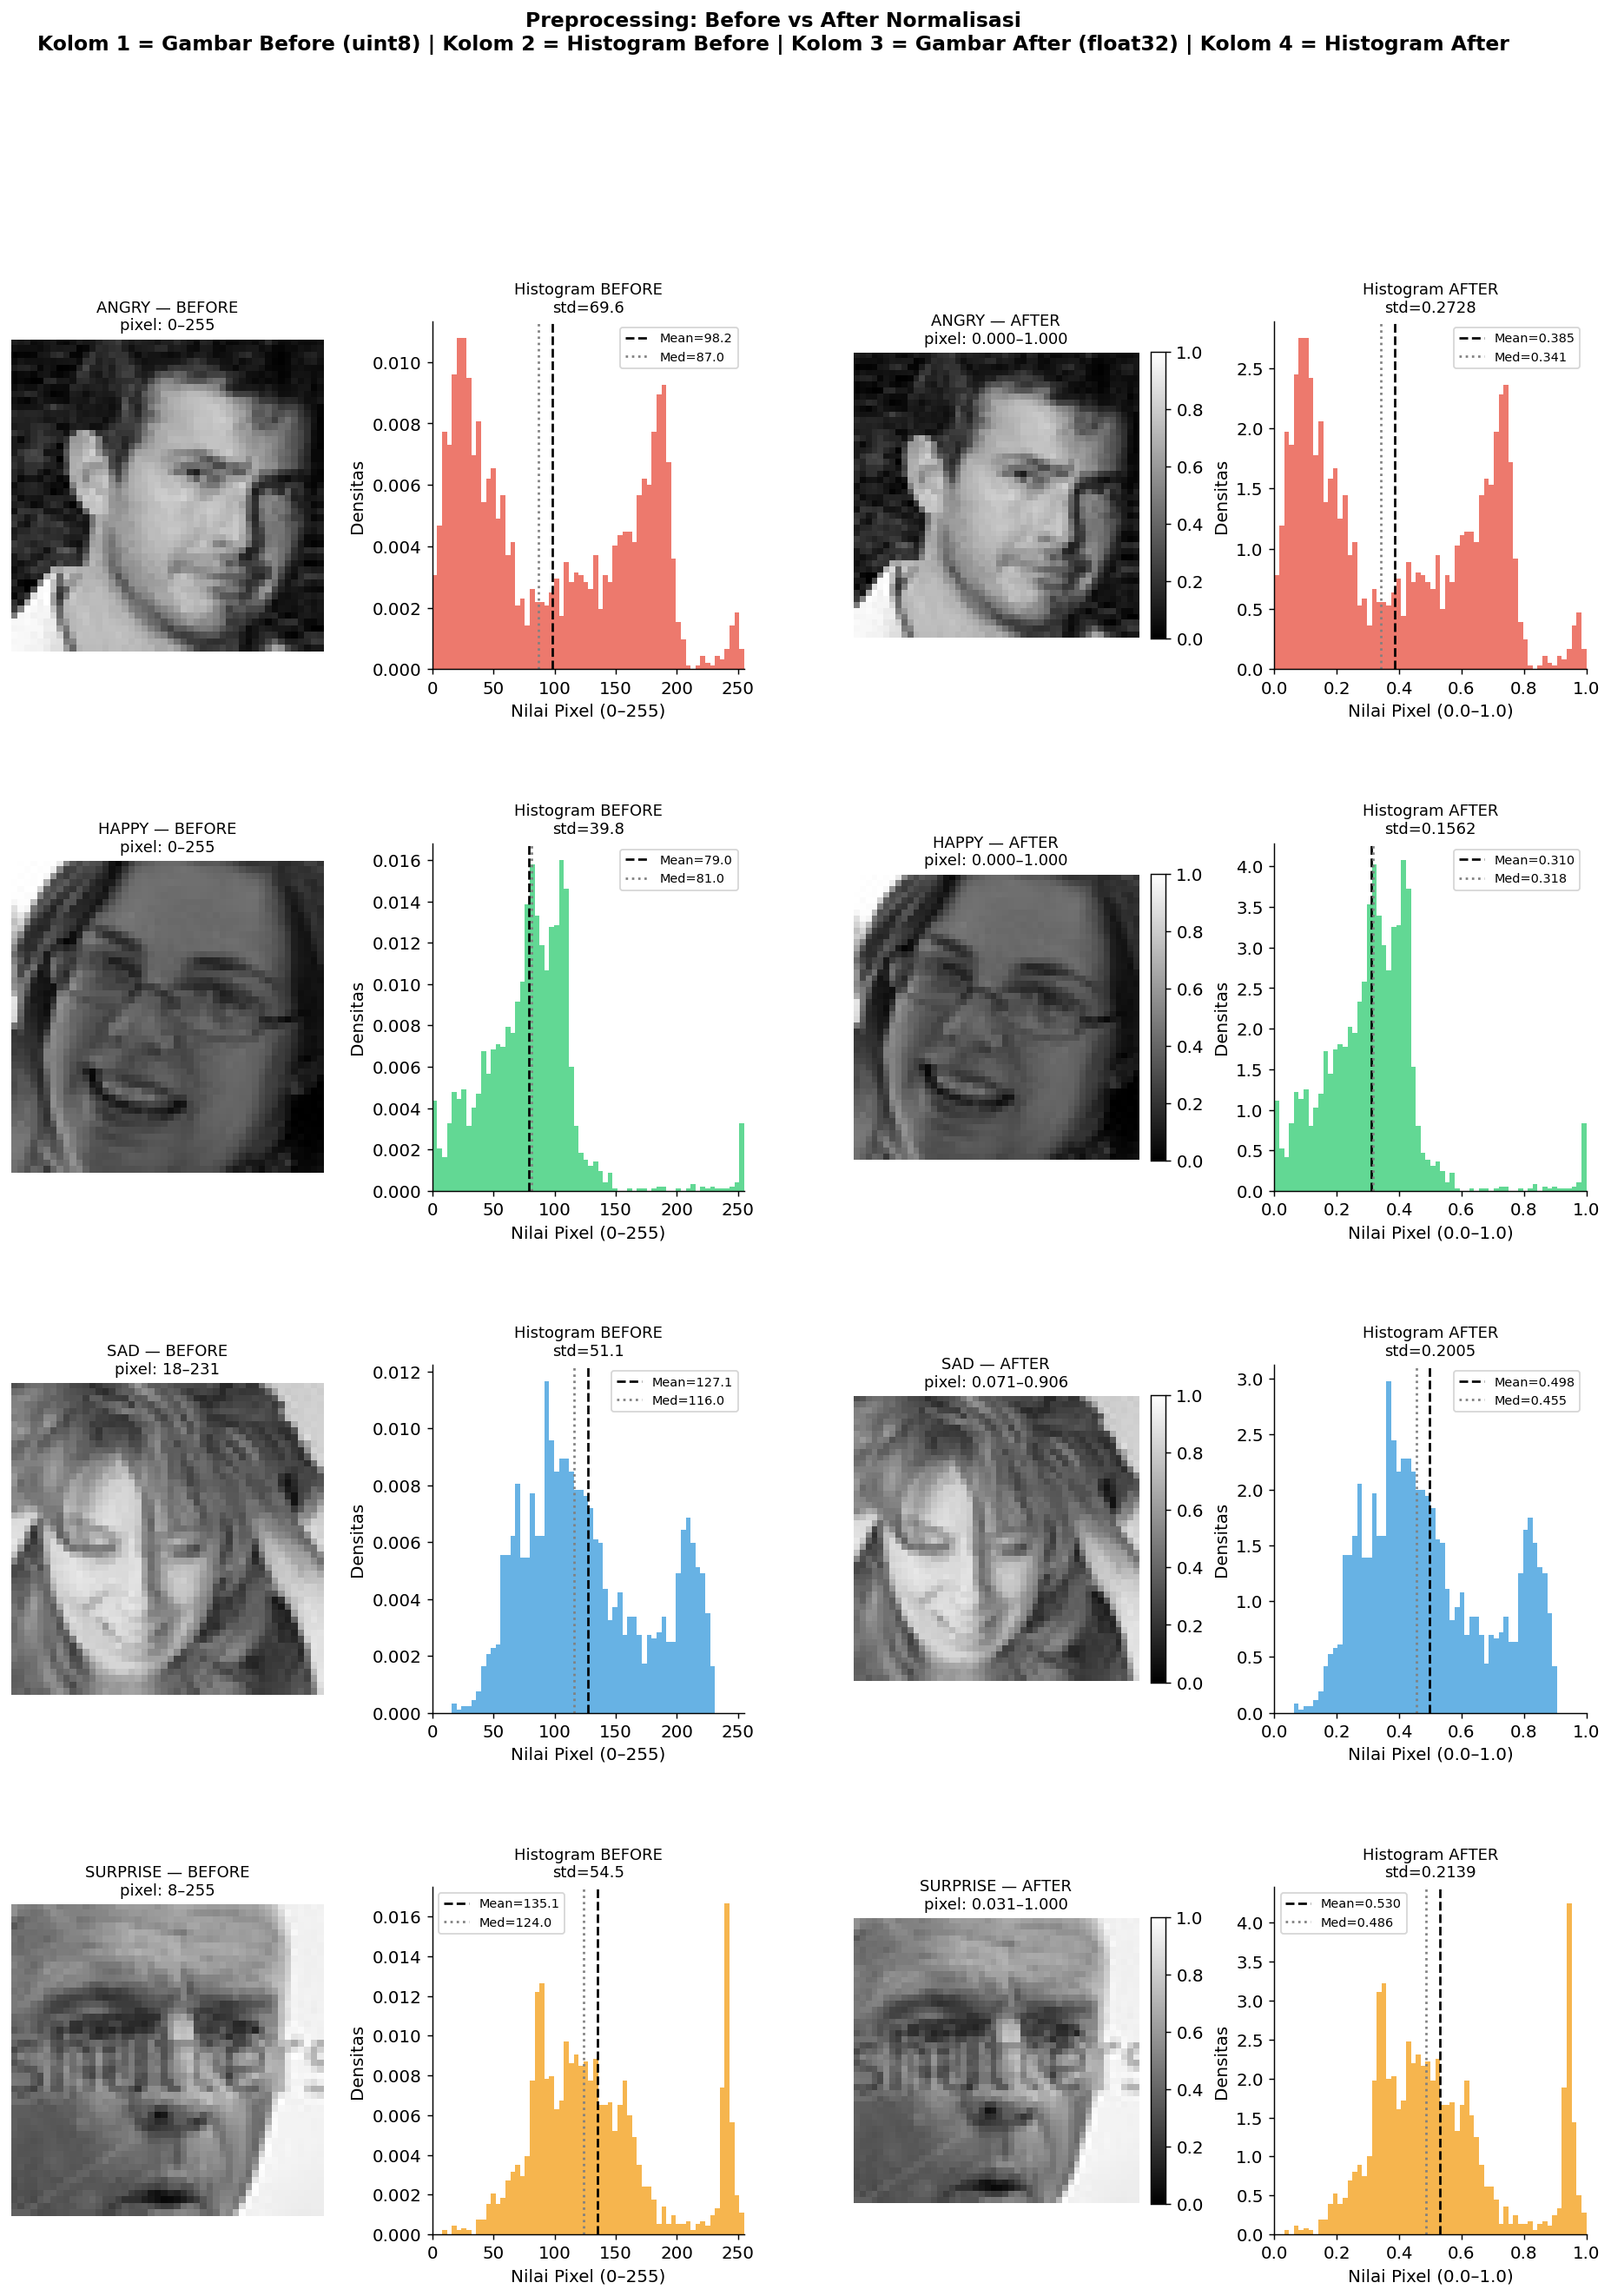

💾 Disimpan: outputs\figures\01_before_after.png


In [9]:
# ================================================================
#  CELL 1.2 — Visualisasi Before/After Normalisasi + Histogram
# ================================================================

def get_sample_per_class(raw_list, norm_list, label_list, classes=CLASSES):
    return {
        cls: {'raw': raw_list[label_list.index(cls)],
              'norm': norm_list[label_list.index(cls)]}
        for cls in classes
    }

samples = get_sample_per_class(train_raw, train_norm, train_labels)

fig = plt.figure(figsize=(18, 5.5 * len(CLASSES)))
fig.suptitle(
    'Preprocessing: Before vs After Normalisasi\n'
    'Kolom 1 = Gambar Before (uint8) | Kolom 2 = Histogram Before | '
    'Kolom 3 = Gambar After (float32) | Kolom 4 = Histogram After',
    fontsize=13, fontweight='bold', y=1.005
)
gs = gridspec.GridSpec(len(CLASSES), 4, figure=fig, hspace=0.5, wspace=0.35)

for row, (cls, color) in enumerate(zip(CLASSES, COLORS)):
    img_raw  = samples[cls]['raw']
    img_norm = samples[cls]['norm']

    # ── Gambar BEFORE ──
    ax = fig.add_subplot(gs[row, 0])
    ax.imshow(img_raw, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{cls.upper()} — BEFORE\npixel: {img_raw.min()}–{img_raw.max()}', fontsize=10)
    ax.axis('off')
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_edgecolor(color); sp.set_linewidth(2.5)

    # ── Histogram BEFORE ──
    ax = fig.add_subplot(gs[row, 1])
    ax.hist(img_raw.ravel(), bins=64, range=(0,255), color=color, alpha=0.75, density=True)
    ax.axvline(img_raw.mean(), color='black', lw=1.5, ls='--',
               label=f'Mean={img_raw.mean():.1f}')
    ax.axvline(np.median(img_raw), color='gray', lw=1.5, ls=':',
               label=f'Med={np.median(img_raw):.1f}')
    ax.set_title(f'Histogram BEFORE\nstd={img_raw.std():.1f}', fontsize=10)
    ax.set_xlabel('Nilai Pixel (0–255)'); ax.set_ylabel('Densitas')
    ax.legend(fontsize=8); ax.set_xlim(0, 255)

    # ── Gambar AFTER ──
    ax = fig.add_subplot(gs[row, 2])
    im = ax.imshow(img_norm, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'{cls.upper()} — AFTER\npixel: {img_norm.min():.3f}–{img_norm.max():.3f}',
                 fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_edgecolor(color); sp.set_linewidth(2.5)

    # ── Histogram AFTER ──
    ax = fig.add_subplot(gs[row, 3])
    ax.hist(img_norm.ravel(), bins=64, range=(0,1), color=color, alpha=0.75, density=True)
    ax.axvline(img_norm.mean(), color='black', lw=1.5, ls='--',
               label=f'Mean={img_norm.mean():.3f}')
    ax.axvline(np.median(img_norm), color='gray', lw=1.5, ls=':',
               label=f'Med={np.median(img_norm):.3f}')
    ax.set_title(f'Histogram AFTER\nstd={img_norm.std():.4f}', fontsize=10)
    ax.set_xlabel('Nilai Pixel (0.0–1.0)'); ax.set_ylabel('Densitas')
    ax.legend(fontsize=8); ax.set_xlim(0, 1)

plt.savefig(str(OUT_FIGS / '01_before_after.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Disimpan:", OUT_FIGS / '01_before_after.png')


---
# BAGIAN 2 — Representasi Fitur: GLCM (Step-by-Step Lengkap)

---

## 🔷 Apa itu GLCM?

**Gray-Level Co-occurrence Matrix (GLCM)** adalah matriks statistik tekstur yang  
merekam **seberapa sering dua piksel dengan nilai keabuan tertentu muncul bertetangga**  
pada jarak `d` dan arah `θ` tertentu.

> 💡 **Ide inti:** Bukan melihat nilai piksel satu per satu, melainkan  
> melihat **hubungan antar piksel yang berdekatan** — inilah yang disebut "tekstur".

```
GLCM[i][j] = berapa kali piksel bernilai i bersebelahan dengan piksel bernilai j
             (pada jarak d dan arah θ)
```

---

## 🔷 Langkah 1 — Kuantisasi: Mengapa Diperlukan?

Gambar grayscale asli memiliki **256 nilai** (0–255).  
Jika langsung dipakai → GLCM berukuran **256 × 256 = 65.536 sel** → sangat jarang (*sparse*)!

**Solusi: Kuantisasi** — perkecil jumlah level ke 8, 16, atau 32:

```
Rumus: level = ⌊ pixel_norm × L ⌋   di mana L = jumlah level

Contoh (L = 8):
  pixel=200 → norm=0.784 → ⌊0.784 × 8⌋ = 6
  pixel= 90 → norm=0.353 → ⌊0.353 × 8⌋ = 2
  pixel= 30 → norm=0.118 → ⌊0.118 × 8⌋ = 0
```

| Level (L) | Ukuran GLCM | Sel Total | Karakteristik |
|:---------:|:-----------:|:---------:|:-------------|
| **8**     | 8 × 8       | 64        | Kasar, cepat, padat |
| **16**    | 16 × 16     | 256       | ⭐ Keseimbangan terbaik |
| **32**    | 32 × 32     | 1.024     | Detail, tapi banyak sel kosong |
| 256       | 256 × 256   | 65.536    | ❌ Terlalu sparse |

---

## 🔷 Langkah 2 — Membangun GLCM dari Nol (Ilustrasi 3×3)

**Contoh gambar 3×3 setelah kuantisasi 4-level:**

```
Gambar asli (0–255):    Setelah kuantisasi L=4:
┌─────────────────┐     ┌───────────┐
│ 200  150   80   │     │  3   2   1│
│ 120   90   60   │ →   │  2   1   0│
│  50   40   30   │     │  0   0   0│
└─────────────────┘     └───────────┘
```

**Sudut 0° (arah horizontal →), d=1:**  
Setiap piksel dipasangkan dengan tetangga di sebelah KANAN-nya:

```
Baris 0:  (3→2), (2→1)
Baris 1:  (2→1), (1→0)
Baris 2:  (0→0), (0→0)

Total pasangan: 6
Dengan symmetric=True, setiap pasangan (i→j) juga dihitung sebagai (j→i)
Total setelah symmetric: 12
```

**GLCM Frekuensi (sebelum dinormalisasi):**

```
        j=0  j=1  j=2  j=3
   i=0 [  4    1    0    0 ]   ← (0,0)×4 dari dua pasangan (0→0) + symmetric
   i=1 [  1    0    2    0 ]   ← (1,0)×1, (1,2)×2 (dari (2,1) symmetric)
   i=2 [  0    2    0    2 ]   ← (2,1)×2, (2,3)×2 (dari (3,2) symmetric)
   i=3 [  0    0    2    0 ]   ← (3,2)×2 symmetric
```

**GLCM Probabilitas (normed=True, dibagi 12):**

```
        j=0    j=1    j=2    j=3
   i=0 [0.333  0.083  0.000  0.000]
   i=1 [0.083  0.000  0.167  0.000]
   i=2 [0.000  0.167  0.000  0.167]
   i=3 [0.000  0.000  0.167  0.000]
                           Σ semua = 1.000 ✓
```

> ✅ **Diagonal tinggi** → banyak pasangan piksel yang bernilai sama → **tekstur halus/homogen**  
> ❌ **Off-diagonal tinggi** → banyak pasangan yang nilai berbeda jauh → **tekstur kasar/kontras**

---

## 🔷 Langkah 3 — 4 Sudut untuk Rotational Invariance

GLCM dihitung untuk **4 arah** agar tidak bergantung pada orientasi gambar:

```
  Sudut 0°  → piksel tetangga di KANAN       (baris sama, kolom+1)
  Sudut 45° → piksel tetangga di KANAN-BAWAH (baris+1,  kolom+1)
  Sudut 90° → piksel tetangga di BAWAH       (baris+1,  kolom sama)
  Sudut 135°→ piksel tetangga di KIRI-BAWAH  (baris+1,  kolom-1)

  Parameter: symmetric=True → (i,j) dan (j,i) dihitung bersamaan
             normed=True    → dibagi total → probabilitas [0,1]
```

---

## 🔷 Langkah 4 — Ekstraksi 4 Fitur Statistik

Dari matriks probabilitas `P(i,j)`, dihitung 4 properti:

---

### 📊 Fitur 1: CONTRAST

$$\text{Contrast} = \sum_{i,j} (i - j)^2 \cdot P(i,j)$$

**Cara kerja:**
- Setiap pasangan piksel `(i,j)` diberi **bobot `(i-j)²`**
- Piksel yang nilainya **sama** → `(i-j)²=0` → kontribusi **NOL**
- Piksel yang nilainya **sangat berbeda** → `(i-j)²` besar → kontribusi **BESAR**

```
Contoh manual dari matriks di atas:
  P(0,0)=0.333 → bobot (0-0)²=0   → kontribusi = 0.333 × 0   = 0.000
  P(1,0)=0.083 → bobot (1-0)²=1   → kontribusi = 0.083 × 1   = 0.083
  P(2,1)=0.167 → bobot (2-1)²=1   → kontribusi = 0.167 × 1   = 0.167
  P(3,2)=0.167 → bobot (3-2)²=1   → kontribusi = 0.167 × 1   = 0.167
  ...
  Contrast = Σ semua kontribusi
```

> 🔑 **Wajah emosi**: Happy biasanya punya **Contrast lebih tinggi** (tepi mulut senyum tajam)  
> dibanding Sad yang lebih flat.

---

### 📊 Fitur 2: HOMOGENEITY (Inverse Difference Moment)

$$\text{Homogeneity} = \sum_{i,j} \frac{P(i,j)}{1 + |i - j|}$$

**Cara kerja:**
- Setiap pasangan `(i,j)` dibagi dengan `(1 + |i-j|)`
- Piksel **diagonal** `i=j` → penyebut `=1` → kontribusi **PENUH** = P(i,j)
- Piksel **jauh dari diagonal** → penyebut besar → kontribusi **KECIL**

```
Contoh:
  P(0,0)=0.333 → dibagi (1+|0-0|)=1 → kontribusi = 0.333
  P(1,0)=0.083 → dibagi (1+|1-0|)=2 → kontribusi = 0.042
  P(2,1)=0.167 → dibagi (1+|2-1|)=2 → kontribusi = 0.083
  P(3,2)=0.167 → dibagi (1+|3-2|)=2 → kontribusi = 0.083
  Homogeneity = Σ semua kontribusi
```

> 🔑 **Homogeneity tinggi** → area wajah seragam (kulit polos) → tidak banyak variasi tekstur

---

### 📊 Fitur 3: ENERGY (Angular Second Moment)

$$\text{Energy} = \sum_{i,j} P(i,j)^2$$

**Cara kerja:**
- Setiap nilai probabilitas **dikuadratkan**, lalu dijumlah
- Jika GLCM memiliki **1 sel dominan** (nilai besar, sel lain kecil) → `P²` besar → Energy **tinggi**
- Jika GLCM **tersebar merata** di semua sel → tiap `P` kecil → `P²` sangat kecil → Energy **rendah**

```
Contoh:
  P(0,0)=0.333 → 0.333² = 0.111
  P(1,0)=0.083 → 0.083² = 0.007
  P(2,1)=0.167 → 0.167² = 0.028
  ...
  Energy = 0.111 + 0.007 + 0.028 + ... = Σ P²
```

> 🔑 **Energy tinggi** → tekstur sangat seragam/berulang (seperti dahi polos)  
> **Energy rendah** → tekstur kompleks dan bervariasi (seperti area mulut saat senyum)

---

### 📊 Fitur 4: CORRELATION

$$\text{Correlation} = \sum_{i,j} \frac{(i - \mu_i)(j - \mu_j) \cdot P(i,j)}{\sigma_i \cdot \sigma_j}$$

Di mana `μ` = mean dan `σ` = standar deviasi distribusi marginal GLCM:

```
μᵢ = Σᵢ [ i × P(i,:) ]     (rata-rata level baris)
σᵢ = √[ Σᵢ (i−μᵢ)² × P(i,:) ]  (std dev level baris)

μⱼ dan σⱼ sama untuk kolom (karena symmetric)
```

**Cara kerja:**
- Mengukur **seberapa linear hubungan** antara level piksel `i` dan tetangganya `j`
- Jika piksel terang selalu bertetangga dengan piksel terang → **Correlation tinggi (mendekati +1)**
- Jika hubungan acak → **Correlation mendekati 0**
- Range: **-1 sampai +1**

```
Contoh:
  Hitung μi dan σi dulu dari distribusi marginal P(i,:)
  Kemudian untuk setiap (i,j) yang nonzero:
    contrib = (i - μi) × (j - μj) × P(i,j)
  Bagi total dengan (σi × σj)
```

> 🔑 **Correlation tinggi** → ada pola gradasi yang konsisten (seperti bayangan di wajah)

---

## 🔷 Langkah 5 — Agregasi: Mean vs Concat

Setelah mendapat 4 nilai per fitur × 4 sudut = **16 angka total**:

```
             0°      45°     90°    135°
Contrast:  [0.42,   0.38,   0.45,  0.40]
Homog:     [0.71,   0.73,   0.70,  0.72]
Energy:    [0.08,   0.09,   0.07,  0.08]
Corr:      [0.89,   0.87,   0.88,  0.90]
```

**Strategi MEAN (→ 4D):**
```
Rata-rata tiap baris:
  Contrast_mean    = (0.42+0.38+0.45+0.40)/4 = 0.413
  Homog_mean       = (0.71+0.73+0.70+0.72)/4 = 0.715
  Energy_mean      = (0.08+0.09+0.07+0.08)/4 = 0.080
  Corr_mean        = (0.89+0.87+0.88+0.90)/4 = 0.885

Vektor fitur = [0.413, 0.715, 0.080, 0.885]  ← 4 angka saja
✅ Rotational invariant (gambar diputar → fitur sama)
```

**Strategi CONCAT (→ 16D):**
```
Gabungkan semua nilai:
  [0.42, 0.38, 0.45, 0.40,   ← Contrast 4 sudut
   0.71, 0.73, 0.70, 0.72,   ← Homogeneity 4 sudut
   0.08, 0.09, 0.07, 0.08,   ← Energy 4 sudut
   0.89, 0.87, 0.88, 0.90]   ← Correlation 4 sudut

Vektor fitur = 16 angka
✅ Menyimpan informasi orientasi tekstur
⚠️ Sensitif rotasi, risiko overfitting lebih tinggi
```

| Aspek | MEAN (4D) | CONCAT (16D) |
|:------|:---------:|:------------:|
| Dimensi | 4 | 16 |
| Rotasi gambar | Fitur SAMA | Fitur BEDA |
| Info arah tekstur | ❌ Hilang | ✅ Tersimpan |
| Risiko overfitting | Rendah | Lebih tinggi |
| Rekomendasi | Foto frontal seragam | Jika orientasi penting |

---

## 🔷 Pipeline Lengkap

```
Gambar Asli (uint8, 48×48, 0–255)
         │
         │ ÷ 255.0
         ▼
Gambar Ternormalisasi (float32, 0–1)
         │
         │ ⌊pixel × L⌋  (L = jumlah level)
         ▼
Gambar Terkuantisasi (int, 0 … L-1)
         │
         │ graycomatrix(distances=[1], angles=[0°,45°,90°,135°],
         │              symmetric=True, normed=True)
         ▼
GLCM per Sudut: shape = (L, L, 1, 4)
         │
         │ graycoprops(glcm, 'contrast')   → shape (1,4) → 4 nilai
         │ graycoprops(glcm, 'homogeneity')
         │ graycoprops(glcm, 'energy')
         │ graycoprops(glcm, 'correlation')
         ▼
16 Nilai Fitur (4 properti × 4 sudut)
         │
         ├─── agregasi MEAN   → Vektor 4D  (input Logistic Regression)
         └─── agregasi CONCAT → Vektor 16D (input Logistic Regression)
```


In [10]:
# ================================================================
#  CELL 2.0 — Fungsi Inti GLCM (Kuantisasi + Ekstraksi)
# ================================================================

def quantize_image(img_norm, levels):
    """
    Kuantisasi gambar float [0,1] → integer [0, levels-1].

    Cara kerja:
      pixel_norm × levels  →  ambil floor  →  clip ke [0, levels-1]
    Contoh (levels=16):
      0.75 → floor(0.75*16) = 12   (level ke-12 dari 0..15)
      1.00 → clip(16) = 15         (bukan 16, agar tidak out-of-bounds)
    """
    return np.clip(np.floor(img_norm * levels).astype(np.int32), 0, levels - 1)


def extract_glcm_features(img_norm, levels,
                           distances=DISTANCES, angles=ANGLES,
                           props=GLCM_PROPS, aggregation='mean'):
    """
    Ekstrak vektor fitur GLCM dari gambar grayscale.

    aggregation='mean'   → rata-rata 4 sudut → vektor 4D
    aggregation='concat' → concatenate 4 sudut → vektor 16D

    Returns
    -------
    feature_vector : np.ndarray  Vektor fitur 1D
    glcm_raw       : np.ndarray  Matriks GLCM mentah (L,L,1,4)
    """
    img_q = quantize_image(img_norm, levels)
    glcm  = graycomatrix(
        img_q,
        distances=distances, angles=angles, levels=levels,
        symmetric=True,   # GLCM(i,j) + GLCM(j,i) → simetris, lebih stabil
        normed=True       # Bagi total → nilai probabilitas [0,1]
    )
    feature_vector = []
    if aggregation == 'mean':
        for prop in props:
            feature_vector.append(graycoprops(glcm, prop).mean())
    elif aggregation == 'concat':
        for prop in props:
            feature_vector.extend(graycoprops(glcm, prop).flatten())
    return np.array(feature_vector, dtype=np.float32), glcm


def compute_coherence_matrix(glcm_4d, aggregation='mean'):
    """
    Hitung Matriks Koheren = agregasi GLCM dari semua sudut.

    C(i,j) = (1/n_angles) × Σ_θ GLCM_θ(i,j)

    Matriks ini merepresentasikan pola ko-okurens yang
    bersifat 'rotational invariant' (tidak bergantung arah).

    Returns
    -------
    coherence : np.ndarray  Shape (L, L)
    """
    glcm_3d = glcm_4d[:, :, 0, :]   # (L, L, n_angles)
    if aggregation == 'mean':
        return glcm_3d.mean(axis=-1)
    elif aggregation == 'max':
        return glcm_3d.max(axis=-1)
    return glcm_3d.mean(axis=-1)


# ── Test fungsi ──────────────────────────────────────────────────
feat_test, glcm_test = extract_glcm_features(train_norm[0], levels=16, aggregation='mean')
print("✅ Fungsi GLCM berjalan normal.")
print(f"   Fitur (mean, L=16) : {np.round(feat_test, 4)}")
print(f"   Shape GLCM         : {glcm_test.shape}  ← (levels, levels, 1, 4_sudut)")
print(f"\n   Interpretasi fitur pertama:")
for prop, val in zip(GLCM_PROPS, feat_test):
    print(f"   {prop:15s} = {val:.6f}")


✅ Fungsi GLCM berjalan normal.
   Fitur (mean, L=16) : [3.1831 0.6025 0.1629 0.9145]
   Shape GLCM         : (16, 16, 1, 4)  ← (levels, levels, 1, 4_sudut)

   Interpretasi fitur pertama:
   contrast        = 3.183138
   homogeneity     = 0.602526
   energy          = 0.162874
   correlation     = 0.914545


## STEP A — Gambar Asli + Histogram Distribusi Intensitas

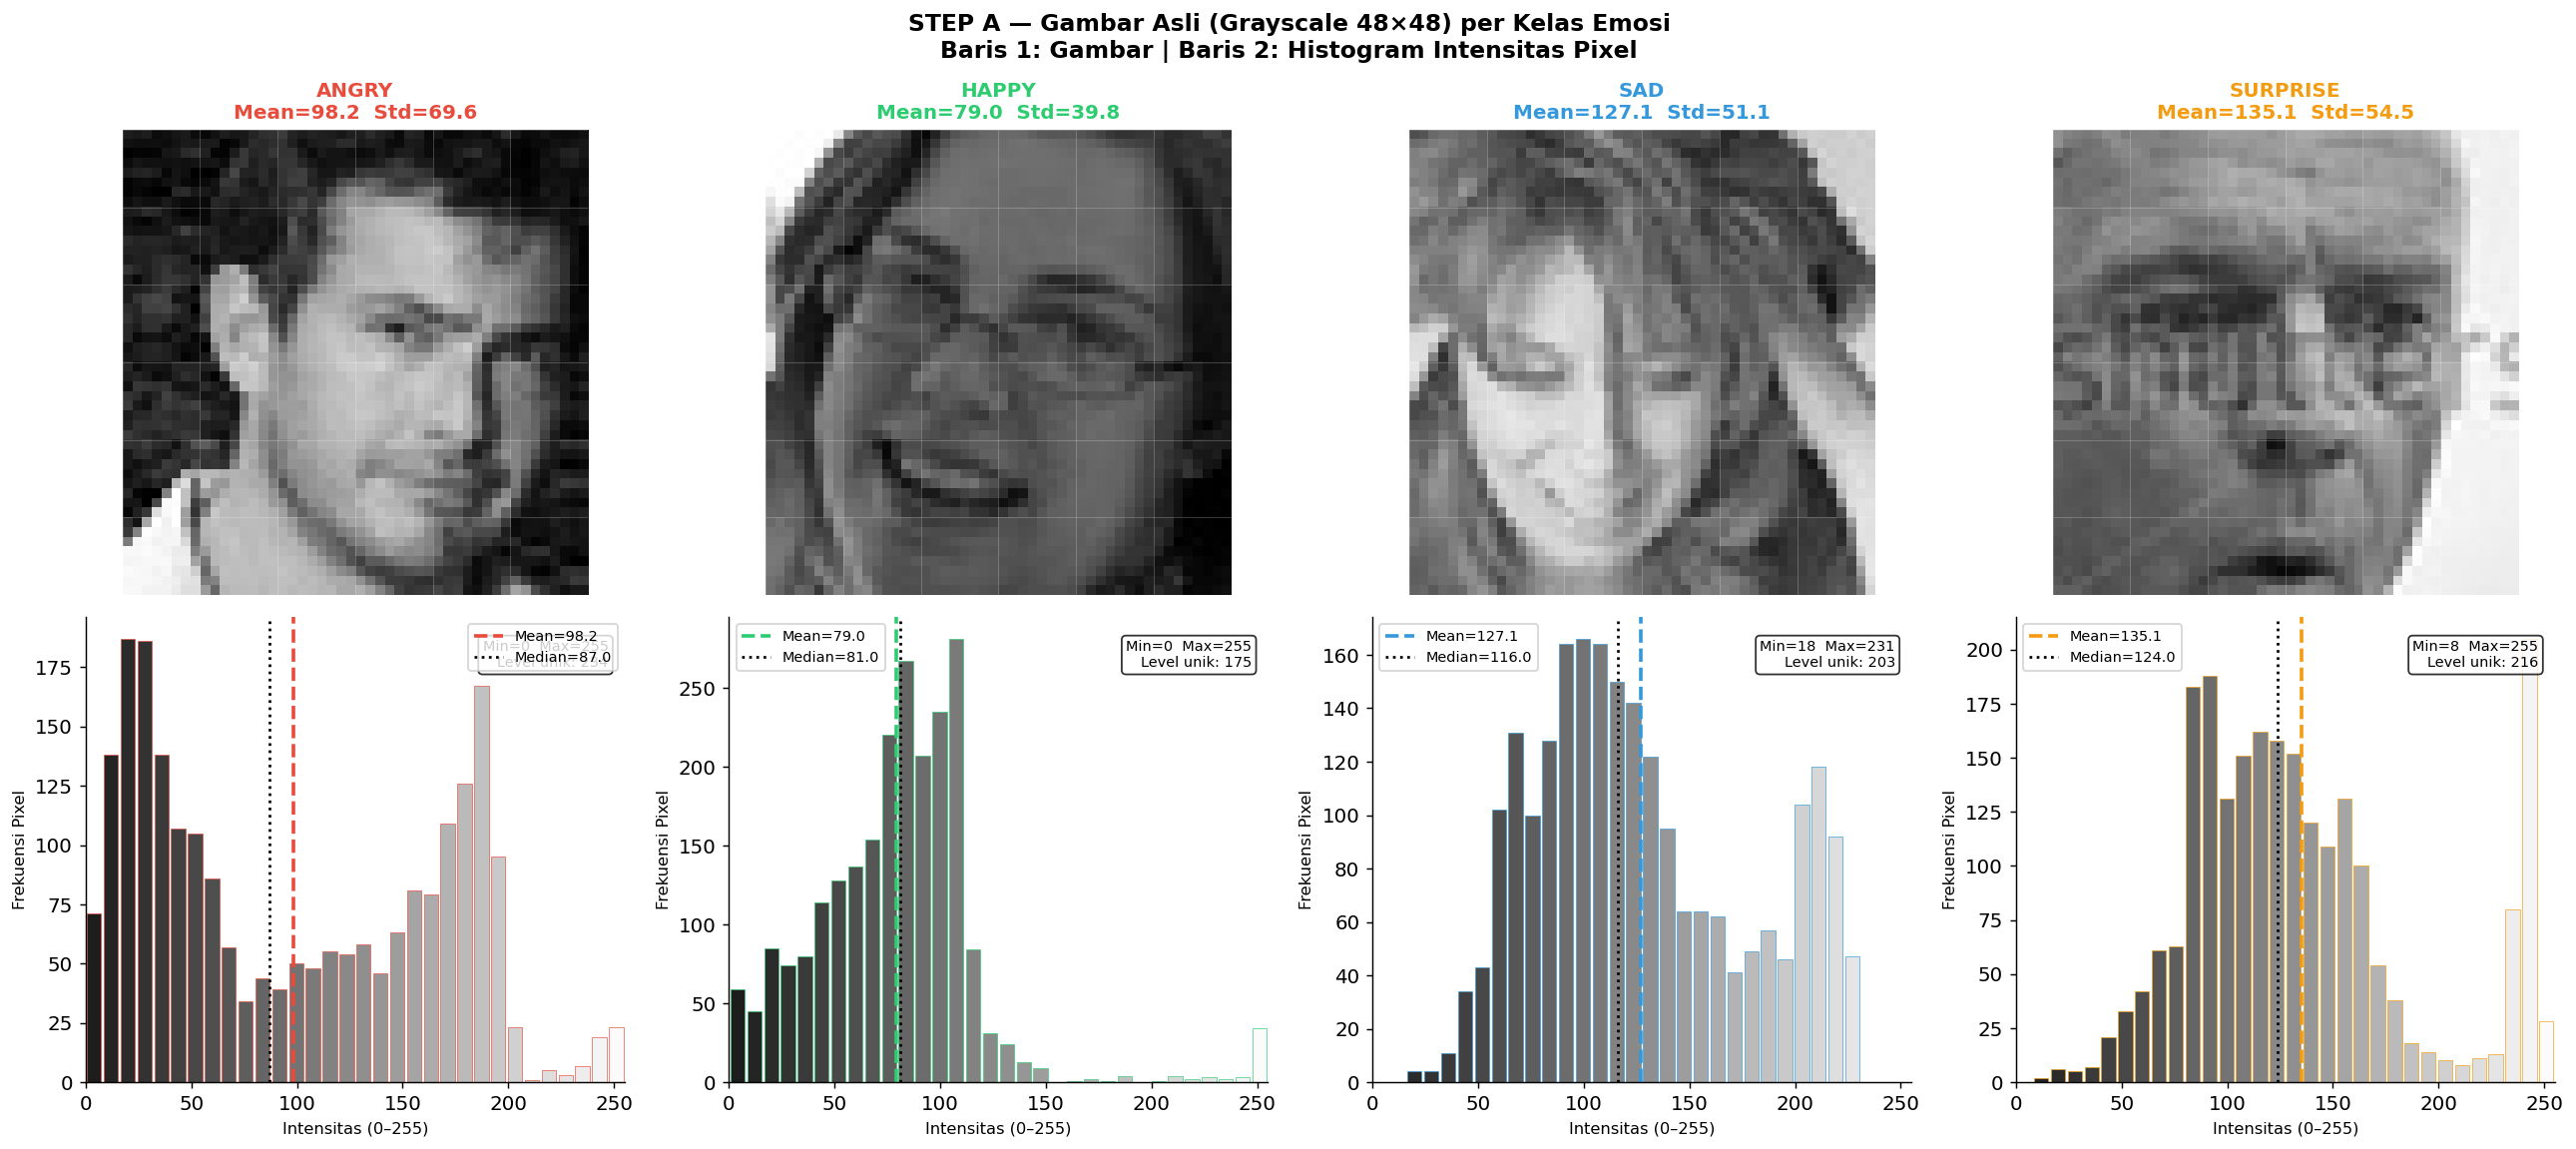

💾 Disimpan: outputs\figures\02_step_a_gambar_asli.png


In [11]:
# ================================================================
#  CELL 2.1 — STEP A: Gambar Asli per Kelas
# ================================================================
# Untuk setiap kelas emosi, tampilkan:
#   - Gambar asli grayscale
#   - Histogram distribusi intensitas pixel

fig, axes = plt.subplots(2, len(CLASSES), figsize=(5*len(CLASSES), 9))
fig.suptitle(
    'STEP A — Gambar Asli (Grayscale 48×48) per Kelas Emosi\n'
    'Baris 1: Gambar | Baris 2: Histogram Intensitas Pixel',
    fontsize=13, fontweight='bold'
)

for col, (cls, color) in enumerate(zip(CLASSES, COLORS)):
    img_raw = samples[cls]['raw']

    # ── Baris 0: Gambar ──
    ax = axes[0, col]
    ax.imshow(img_raw, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'{cls.upper()}\n'
                 f'Mean={img_raw.mean():.1f}  Std={img_raw.std():.1f}',
                 fontsize=11, color=color, fontweight='bold')
    ax.axis('off')
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_edgecolor(color); sp.set_linewidth(3)

    # ── Overlay grid koordinat ──
    for x in range(0, 49, 8):
        ax.axvline(x - 0.5, color='white', lw=0.3, alpha=0.4)
    for y in range(0, 49, 8):
        ax.axhline(y - 0.5, color='white', lw=0.3, alpha=0.4)

    # ── Baris 1: Histogram ──
    ax = axes[1, col]
    hist_vals, bin_edges = np.histogram(img_raw.ravel(), bins=32, range=(0,255))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Warna bar berdasarkan intensitas (grayscale)
    for bv, bc in zip(hist_vals, bin_centers):
        gv = bc / 255.0
        ax.bar(bc, bv, width=(bin_edges[1]-bin_edges[0])*0.85,
               color=(gv, gv, gv), edgecolor=color, linewidth=0.4, alpha=0.9)

    ax.axvline(img_raw.mean(),      color=color,   lw=2, ls='--',
               label=f'Mean={img_raw.mean():.1f}')
    ax.axvline(np.median(img_raw),  color='black', lw=1.5, ls=':',
               label=f'Median={np.median(img_raw):.1f}')

    ax.set_xlabel('Intensitas (0–255)', fontsize=9)
    ax.set_ylabel('Frekuensi Pixel', fontsize=9)
    ax.set_xlim(0, 255)
    ax.legend(fontsize=8)

    # Anotasi statistik
    stats = (f"Min={img_raw.min()}  Max={img_raw.max()}\n"
             f"Level unik: {len(np.unique(img_raw))}")
    ax.text(0.97, 0.95, stats, transform=ax.transAxes,
            va='top', ha='right', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '02_step_a_gambar_asli.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Disimpan:", OUT_FIGS / '02_step_a_gambar_asli.png')


## STEP B — Matriks Keabuan: Nilai Pixel & Kuantisasi

Sebelum membangun GLCM, gambar harus **dikuantisasi** ke jumlah level yang lebih kecil.

> **Mengapa Kuantisasi?**  
> Gambar 256-level → GLCM **256×256 = 65.536 sel** (sangat jarang/sparse).  
> Dengan kuantisasi ke 16 level → GLCM **16×16 = 256 sel** (lebih padat, informatif).

**Rumus:** `level = ⌊pixel_norm × L⌋`  clipped ke `[0, L-1]`


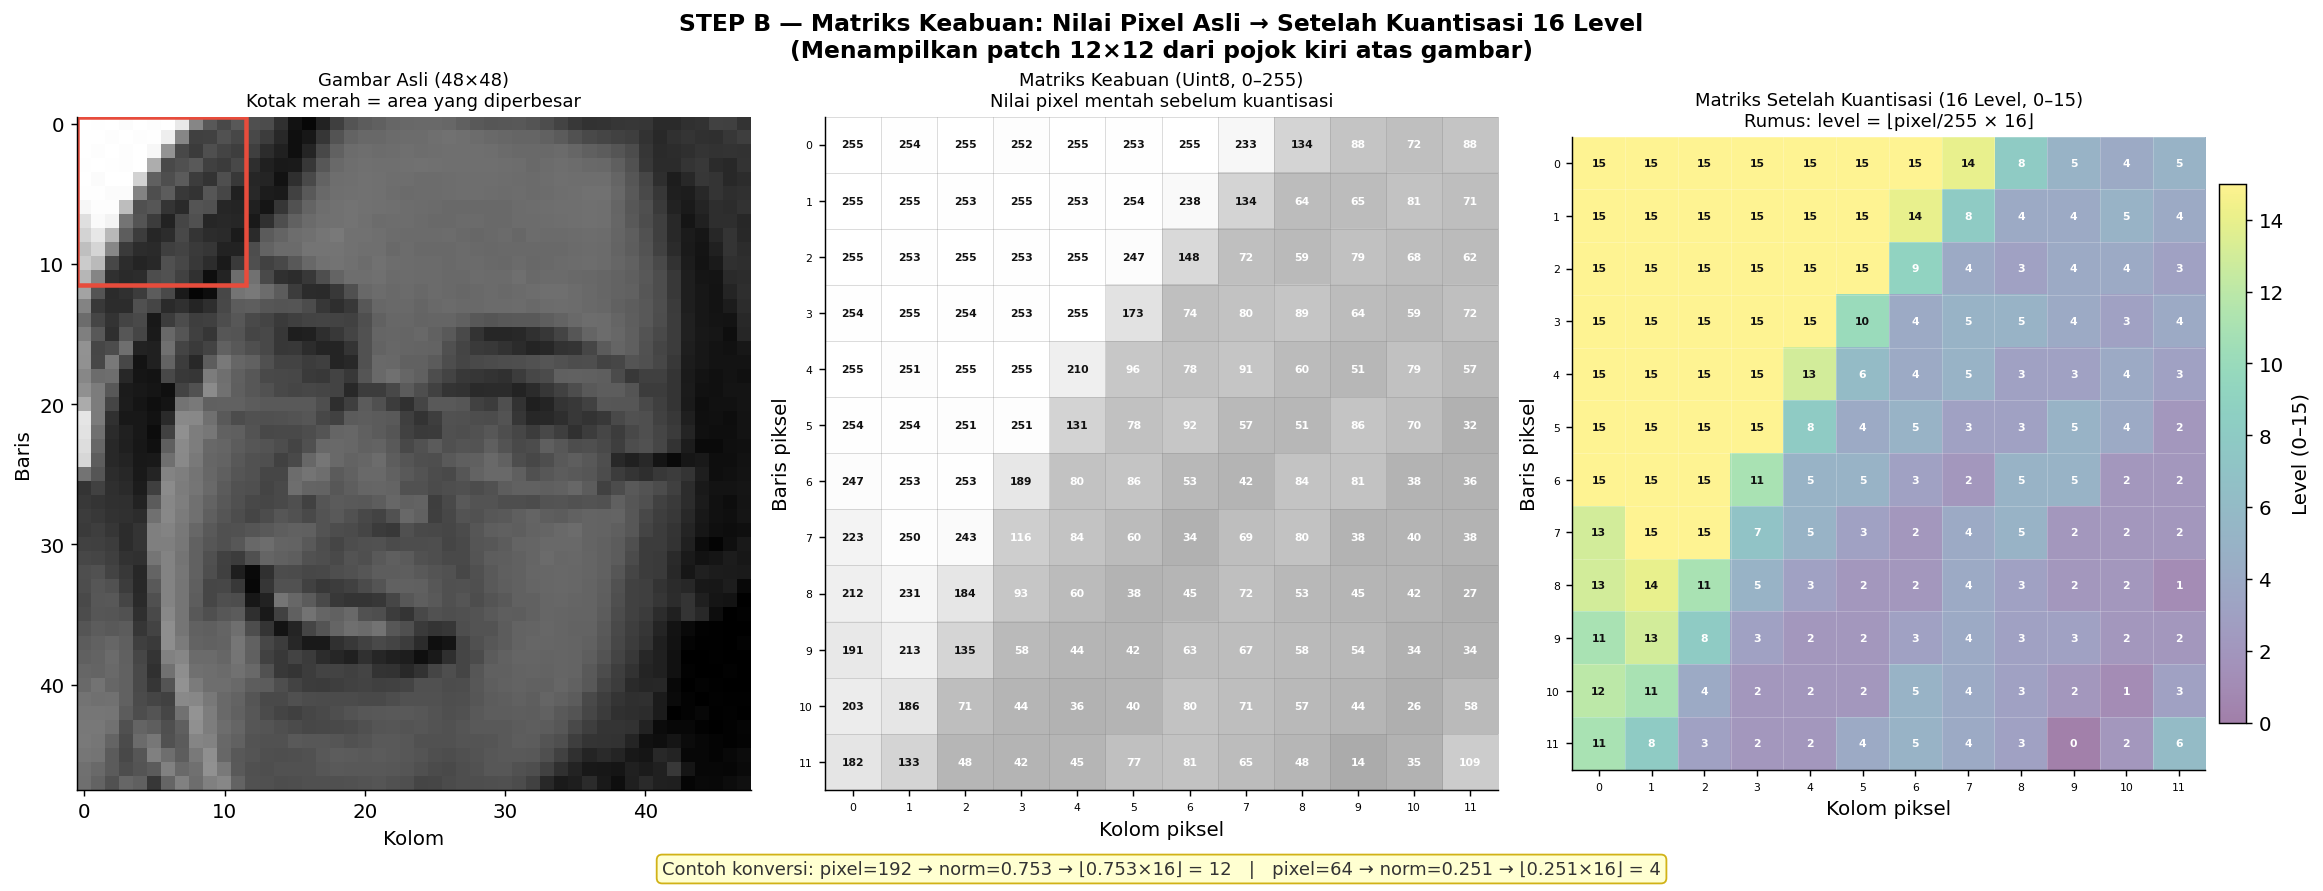

💾 Disimpan: outputs\figures\03_step_b_matriks_keabuan.png


In [12]:
# ================================================================
#  CELL 2.2 — STEP B: Matriks Keabuan (Pixel Grid + Kuantisasi)
# ================================================================
# Tampilkan 3 panel untuk 1 gambar contoh:
#   Panel 1: Patch gambar asli (visualisasi)
#   Panel 2: Nilai uint8 tiap piksel (matriks angka)
#   Panel 3: Nilai setelah kuantisasi (matriks angka)

LEVELS_DEMO = 16
GRID_SZ     = 12   # Tampilkan patch 12×12 agar angka terbaca

# Ambil gambar contoh 'happy'
idx_ex   = train_labels.index('happy')
img_raw_ex  = train_raw[idx_ex]
img_norm_ex = train_norm[idx_ex]
img_q_ex    = quantize_image(img_norm_ex, LEVELS_DEMO)

# Ambil patch kiri atas
patch_raw = img_raw_ex[:GRID_SZ, :GRID_SZ]
patch_q   = img_q_ex[:GRID_SZ, :GRID_SZ]

fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
fig.suptitle(
    f'STEP B — Matriks Keabuan: Nilai Pixel Asli → Setelah Kuantisasi {LEVELS_DEMO} Level\n'
    f'(Menampilkan patch {GRID_SZ}×{GRID_SZ} dari pojok kiri atas gambar)',
    fontsize=13, fontweight='bold'
)

tick_lbl = [str(i) for i in range(GRID_SZ)]

# ── Panel 1: Gambar Patch ──
ax = axes[0]
ax.imshow(img_raw_ex, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
rect = mpatches.Rectangle((0-0.5, 0-0.5), GRID_SZ, GRID_SZ,
                            linewidth=2.5, edgecolor='#e74c3c', facecolor='none')
ax.add_patch(rect)
ax.set_title(f'Gambar Asli (48×48)\nKotak merah = area yang diperbesar',
             fontsize=10)
ax.set_xlabel('Kolom'); ax.set_ylabel('Baris')

# ── Panel 2: Nilai uint8 (matriks angka) ──
ax = axes[1]
ax.imshow(patch_raw, cmap='gray', vmin=0, vmax=255,
          interpolation='nearest', aspect='equal', alpha=0.35)
for i in range(GRID_SZ):
    for j in range(GRID_SZ):
        val    = patch_raw[i, j]
        tcolor = 'white' if val < 128 else '#111'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=6, color=tcolor, fontweight='bold')
for x in range(-1, GRID_SZ):
    ax.axvline(x+0.5, color='gray', lw=0.3, alpha=0.5)
for y in range(-1, GRID_SZ):
    ax.axhline(y+0.5, color='gray', lw=0.3, alpha=0.5)
ax.set_xticks(range(GRID_SZ)); ax.set_xticklabels(tick_lbl, fontsize=6)
ax.set_yticks(range(GRID_SZ)); ax.set_yticklabels(tick_lbl, fontsize=6)
ax.set_title(f'Matriks Keabuan (Uint8, 0–255)\nNilai pixel mentah sebelum kuantisasi',
             fontsize=10)
ax.set_xlabel('Kolom piksel'); ax.set_ylabel('Baris piksel')

# ── Panel 3: Nilai setelah kuantisasi ──
ax = axes[2]
cmap_q = plt.cm.viridis
norm_q = plt.Normalize(vmin=0, vmax=LEVELS_DEMO - 1)
im_q   = ax.imshow(patch_q, cmap='viridis', vmin=0, vmax=LEVELS_DEMO-1,
                   interpolation='nearest', aspect='equal', alpha=0.5)
for i in range(GRID_SZ):
    for j in range(GRID_SZ):
        val  = patch_q[i, j]
        rgba = cmap_q(norm_q(val))
        lum  = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
        tcolor = 'white' if lum < 0.5 else '#111'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=6, color=tcolor, fontweight='bold')
for x in range(-1, GRID_SZ):
    ax.axvline(x+0.5, color='white', lw=0.3, alpha=0.4)
for y in range(-1, GRID_SZ):
    ax.axhline(y+0.5, color='white', lw=0.3, alpha=0.4)
ax.set_xticks(range(GRID_SZ)); ax.set_xticklabels(tick_lbl, fontsize=6)
ax.set_yticks(range(GRID_SZ)); ax.set_yticklabels(tick_lbl, fontsize=6)
ax.set_title(f'Matriks Setelah Kuantisasi ({LEVELS_DEMO} Level, 0–{LEVELS_DEMO-1})\n'
             f'Rumus: level = ⌊pixel/255 × {LEVELS_DEMO}⌋',
             fontsize=10)
ax.set_xlabel('Kolom piksel'); ax.set_ylabel('Baris piksel')
plt.colorbar(im_q, ax=ax, fraction=0.04, pad=0.02,
             label=f'Level (0–{LEVELS_DEMO-1})')

# Anotasi rumus di bawah
fig.text(0.5, -0.04,
         f'Contoh konversi: pixel=192 → norm=0.753 → ⌊0.753×{LEVELS_DEMO}⌋ = '
         f'{int(np.floor(192/255*LEVELS_DEMO))}   |   '
         f'pixel=64 → norm=0.251 → ⌊0.251×{LEVELS_DEMO}⌋ = '
         f'{int(np.floor(64/255*LEVELS_DEMO))}',
         ha='center', fontsize=10, color='#333',
         bbox=dict(boxstyle='round', facecolor='#ffffcc', edgecolor='#ccaa00', alpha=0.9))

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '03_step_b_matriks_keabuan.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Disimpan:", OUT_FIGS / '03_step_b_matriks_keabuan.png')


## STEP C — Matriks Koheren (Coherence Matrix): Gambaran Umum

**Matriks Koheren** adalah agregasi rata-rata GLCM dari semua sudut.  
Ini memberikan gambaran umum pola ko-okurens yang bersifat *rotational invariant*.

$$C(i,j) = \frac{1}{|\Theta|} \sum_{\theta \in \Theta} \text{GLCM}_{\theta}(i,j)$$

**Interpretasi:**
- **Nilai diagonal tinggi** → piksel cenderung bersebelahan dengan piksel bernilai sama (homogen)
- **Off-diagonal tinggi** → banyak transisi tajam antar level
- **Σ seluruh elemen ≈ 1.0** (karena `normed=True`)


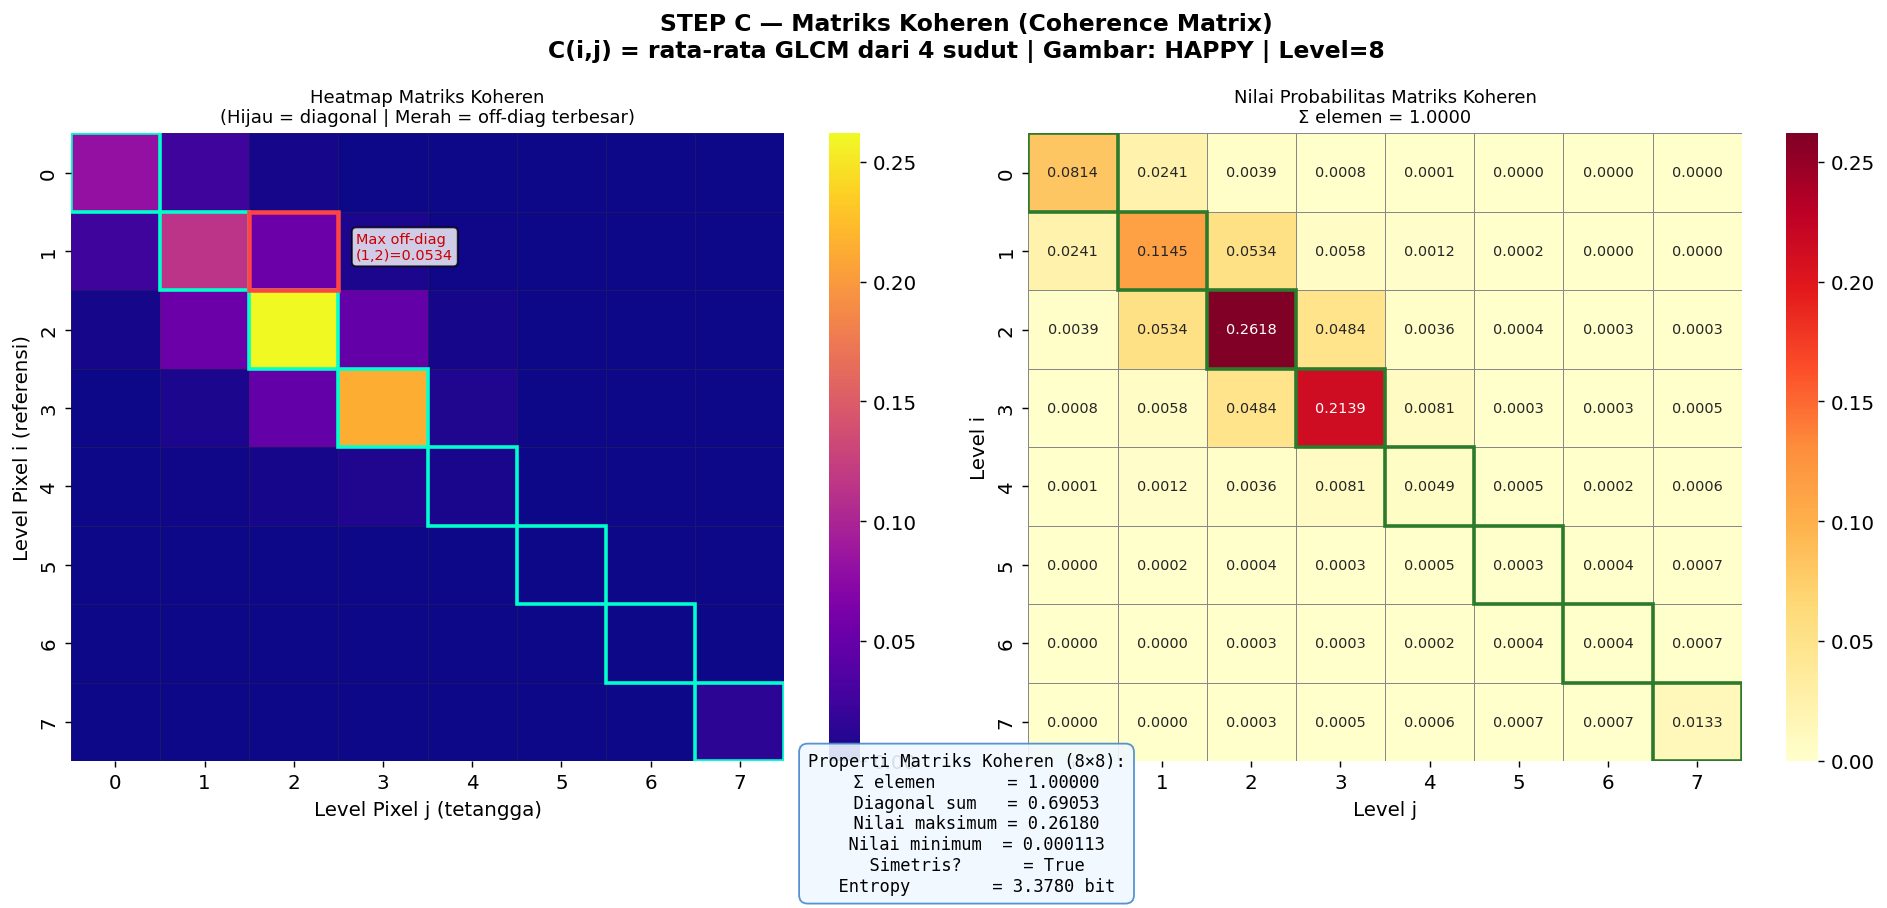

💾 Disimpan: outputs\figures\04_step_c_coherence_overview.png


In [13]:
# ================================================================
#  CELL 2.3 — STEP C: Matriks Koheren Overview
# ================================================================
# Hitung GLCM untuk gambar contoh (happy), lalu tampilkan
# Coherence Matrix = rata-rata 4 sudut

LEVELS_VIS = 8   # 8 level agar angka muat di tabel

img_q_vis = quantize_image(img_norm_ex, LEVELS_VIS)
glcm_ex   = graycomatrix(
    img_q_vis,
    distances=[1], angles=ANGLES, levels=LEVELS_VIS,
    symmetric=True, normed=True
)

# Coherence Matrix
coherence_mat = compute_coherence_matrix(glcm_ex, aggregation='mean')
tick_labels_v = [str(i) for i in range(LEVELS_VIS)]

# Properti per sudut untuk anotasi
props_per_angle = {prop: graycoprops(glcm_ex, prop)[0] for prop in GLCM_PROPS}

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
fig.suptitle(
    f'STEP C — Matriks Koheren (Coherence Matrix)\n'
    f'C(i,j) = rata-rata GLCM dari 4 sudut | Gambar: HAPPY | Level={LEVELS_VIS}',
    fontsize=13, fontweight='bold'
)

# ── Panel 1: Heatmap penuh ──
ax = axes[0]
sns.heatmap(
    coherence_mat, ax=ax, cmap='plasma',
    xticklabels=tick_labels_v, yticklabels=tick_labels_v,
    linewidths=0.4, linecolor='#33333355', cbar=True, annot=False
)
# Highlight diagonal
for i in range(LEVELS_VIS):
    ax.add_patch(mpatches.Rectangle((i, i), 1, 1, fill=False,
                                     edgecolor='#00ffcc', lw=2))
# Sel maksimum off-diagonal
off_d = coherence_mat.copy(); np.fill_diagonal(off_d, 0)
mi = np.unravel_index(off_d.argmax(), off_d.shape)
ax.add_patch(mpatches.Rectangle((mi[1], mi[0]), 1, 1, fill=False,
                                  edgecolor='#ff4444', lw=2.5))
ax.text(mi[1]+1.2, mi[0]+0.6, f'Max off-diag\n({mi[0]},{mi[1]})={off_d[mi]:.4f}',
        color='#cc0000', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_title('Heatmap Matriks Koheren\n(Hijau = diagonal | Merah = off-diag terbesar)',
             fontsize=10)
ax.set_xlabel('Level Pixel j (tetangga)'); ax.set_ylabel('Level Pixel i (referensi)')

# ── Panel 2: Angka detail ──
ax = axes[1]
sns.heatmap(
    coherence_mat, ax=ax, annot=True, fmt='.4f', cmap='YlOrRd',
    xticklabels=tick_labels_v, yticklabels=tick_labels_v,
    linewidths=0.5, linecolor='#888', cbar=True,
    annot_kws={'size': 8}
)
for i in range(LEVELS_VIS):
    ax.add_patch(mpatches.Rectangle((i, i), 1, 1, fill=False,
                                     edgecolor='#2c7a2c', lw=2))
ax.set_title(f'Nilai Probabilitas Matriks Koheren\nΣ elemen = {coherence_mat.sum():.4f}',
             fontsize=10)
ax.set_xlabel('Level j'); ax.set_ylabel('Level i')

# Statistik ringkas
stats_txt = (
    f"Properti Matriks Koheren ({LEVELS_VIS}×{LEVELS_VIS}):\n"
    f"  Σ elemen       = {coherence_mat.sum():.5f}\n"
    f"  Diagonal sum   = {np.trace(coherence_mat):.5f}\n"
    f"  Nilai maksimum = {coherence_mat.max():.5f}\n"
    f"  Nilai minimum  = {coherence_mat[coherence_mat>0].min():.6f}\n"
    f"  Simetris?      = {np.allclose(coherence_mat, coherence_mat.T)}\n"
    f"  Entropy        = {-np.sum(coherence_mat * np.log2(coherence_mat+1e-12)):.4f} bit"
)
fig.text(0.5, -0.06, stats_txt, ha='center', fontsize=9.5,
         fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f8ff', edgecolor='#4488cc', alpha=0.9))

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '04_step_c_coherence_overview.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Disimpan:", OUT_FIGS / '04_step_c_coherence_overview.png')


## STEP D — Semua GLCM per Sudut (4 Sudut × 2 Format)

GLCM dihitung untuk **4 arah** agar hasil tidak bergantung pada orientasi gambar:

| Sudut | Arah | Piksel Tetangga |
|---|---|---|
| 0° | Horizontal → | Kanan |
| 45° | Diagonal ↘ | Kanan-Bawah |
| 90° | Vertikal ↓ | Bawah |
| 135° | Diagonal ↙ | Kiri-Bawah |

**Format visualisasi:**
- **Baris 1**: Heatmap warna → mudah melihat pola distribusi
- **Baris 2**: Nilai angka → verifikasi probabilitas eksak


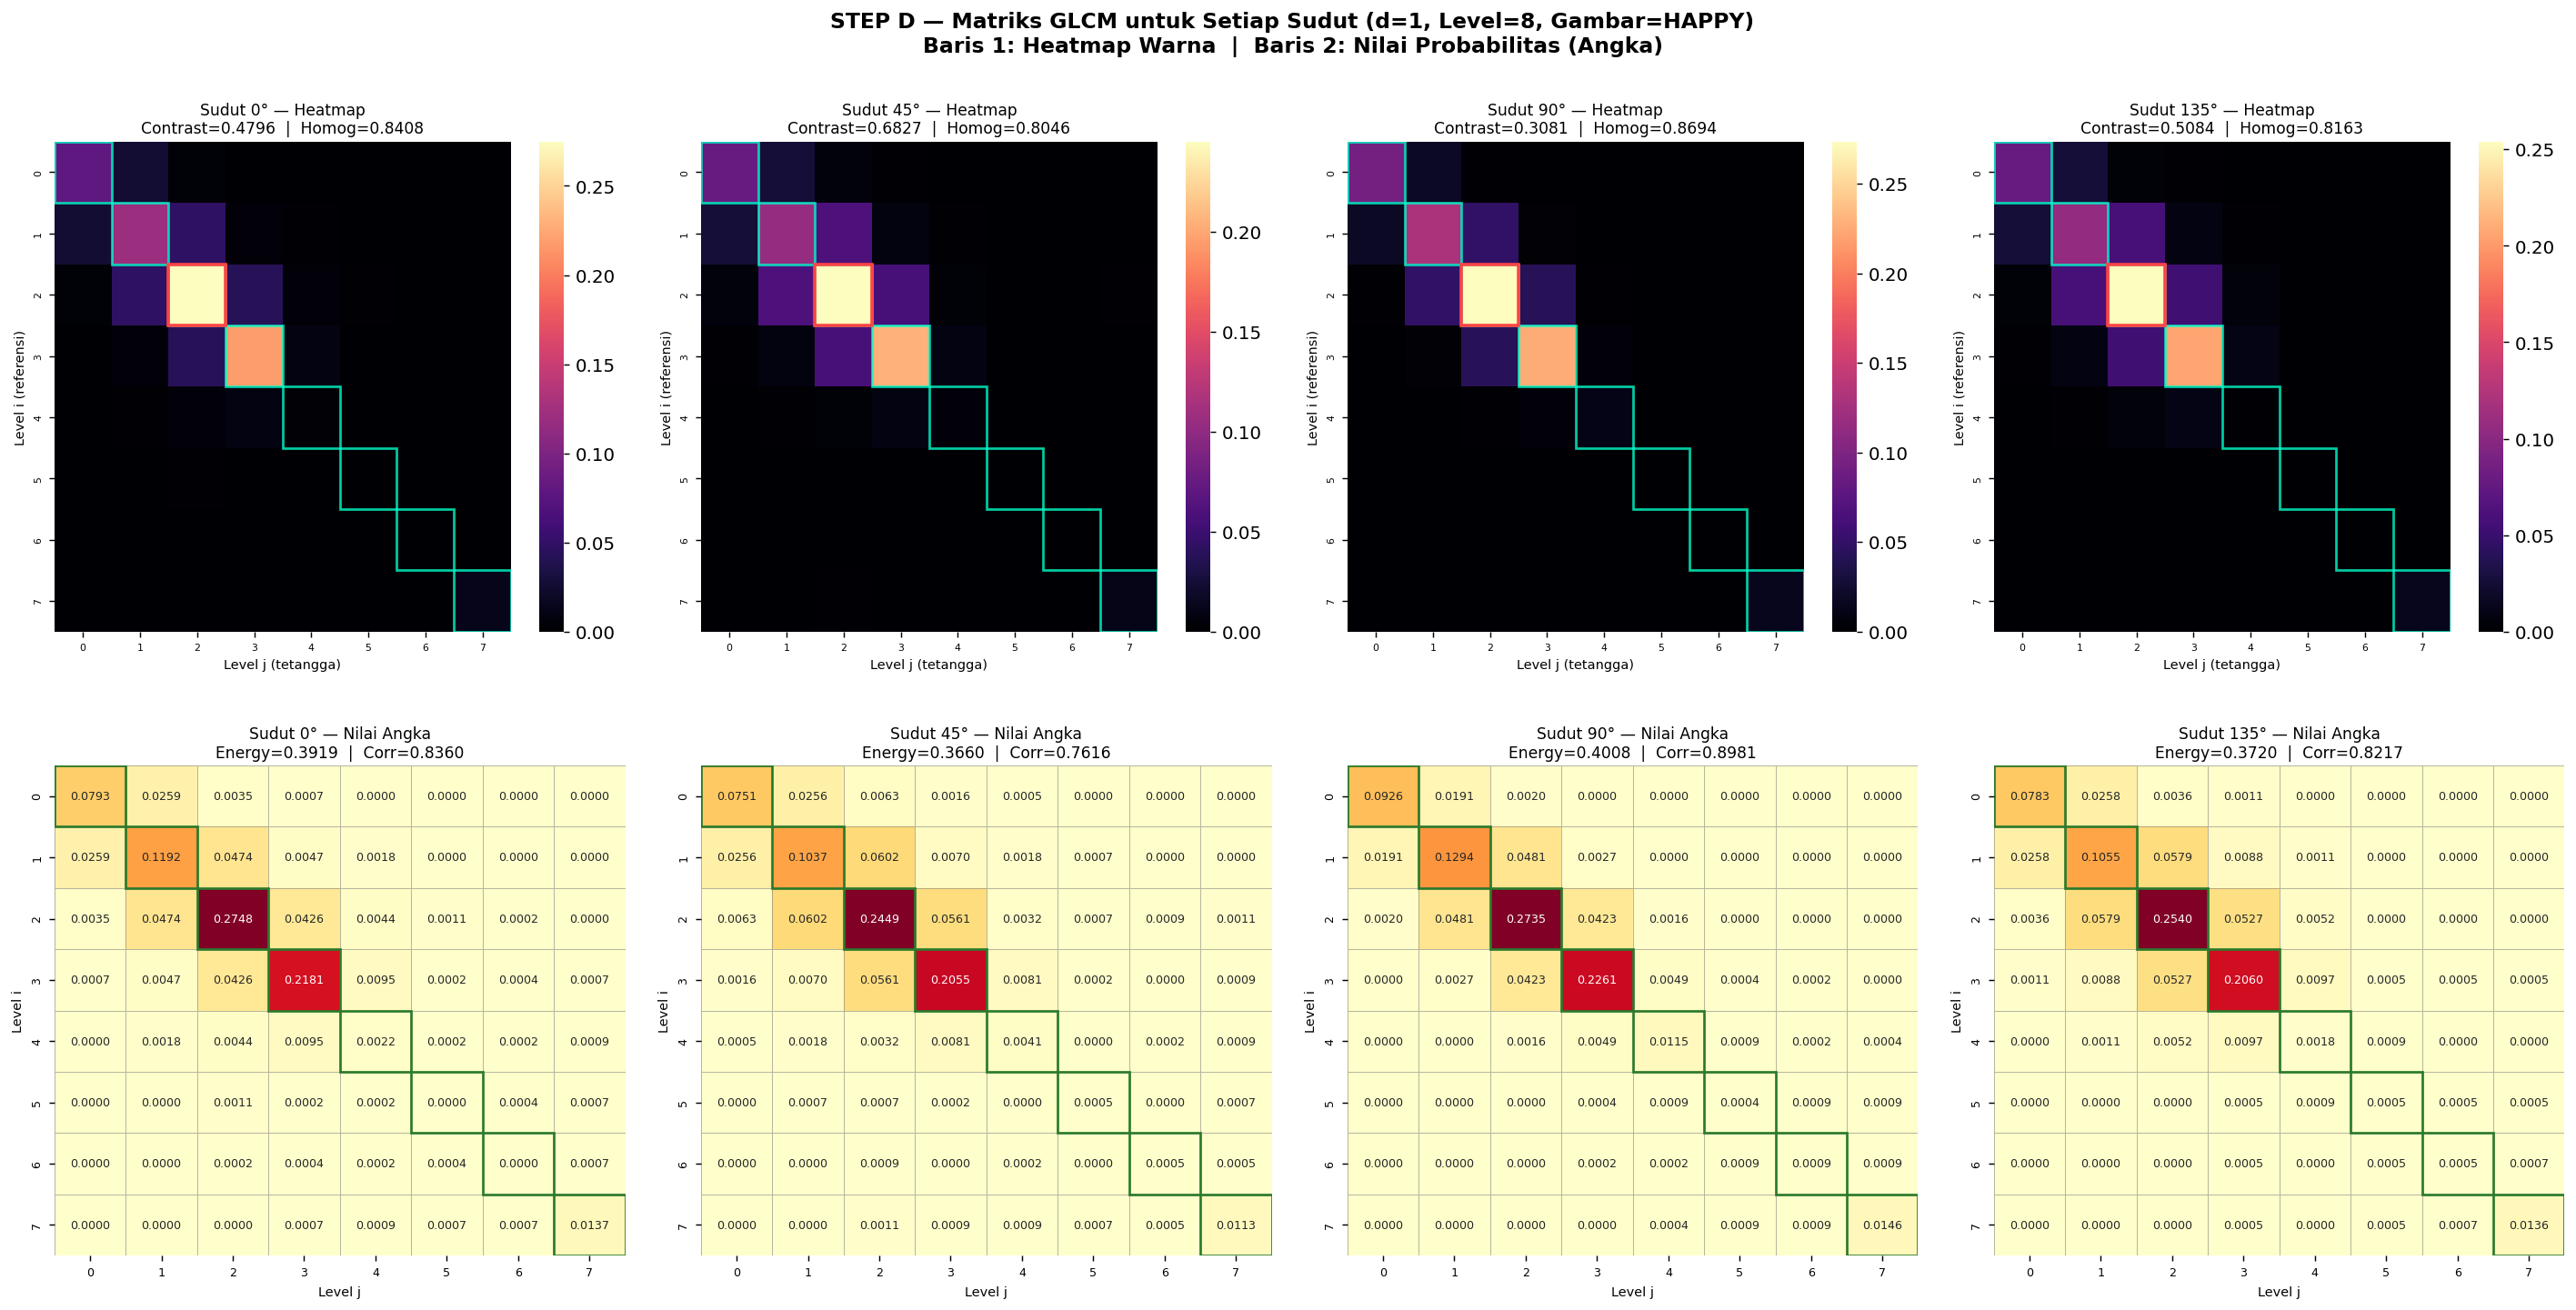

💾 Disimpan: outputs\figures\05_step_d_glcm_per_sudut.png


In [14]:
# ================================================================
#  CELL 2.4 — STEP D: Semua GLCM per Sudut (Heatmap + Angka)
# ================================================================
# 2 baris × 4 kolom:
#   Baris 0 (Heatmap)  : visualisasi warna pola GLCM
#   Baris 1 (Angka)    : nilai probabilitas eksak

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
fig.suptitle(
    f'STEP D — Matriks GLCM untuk Setiap Sudut (d=1, Level={LEVELS_VIS}, Gambar=HAPPY)\n'
    'Baris 1: Heatmap Warna  |  Baris 2: Nilai Probabilitas (Angka)',
    fontsize=13, fontweight='bold', y=1.005
)

for col, (a_idx, a_lbl) in enumerate(zip(range(4), ANGLE_LABELS)):
    g2d = glcm_ex[:, :, 0, a_idx]   # Slice 2D per sudut, shape (L, L)

    c_val  = props_per_angle['contrast'][a_idx]
    h_val  = props_per_angle['homogeneity'][a_idx]
    e_val  = props_per_angle['energy'][a_idx]
    cr_val = props_per_angle['correlation'][a_idx]

    # ── Baris 0: Heatmap Warna ──
    ax = axes[0, col]
    im = sns.heatmap(
        g2d, ax=ax, cmap='magma',
        xticklabels=tick_labels_v, yticklabels=tick_labels_v,
        linewidths=0, cbar=True, annot=False
    )
    # Highlight diagonal (nilai ko-okurens piksel sama)
    for i in range(LEVELS_VIS):
        ax.add_patch(mpatches.Rectangle((i, i), 1, 1, fill=False,
                                         edgecolor='#00ffcc', lw=1.5, alpha=0.8))
    ax.set_title(
        f'Sudut {a_lbl} — Heatmap\n'
        f'Contrast={c_val:.4f}  |  Homog={h_val:.4f}',
        fontsize=9.5, pad=5
    )
    ax.set_xlabel('Level j (tetangga)', fontsize=8)
    ax.set_ylabel('Level i (referensi)', fontsize=8)
    ax.tick_params(labelsize=6)

    # Anotasi maks sel
    max_ij = np.unravel_index(g2d.argmax(), g2d.shape)
    ax.add_patch(mpatches.Rectangle((max_ij[1], max_ij[0]), 1, 1, fill=False,
                                     edgecolor='#ff4444', lw=2))

    # ── Baris 1: Angka ──
    ax = axes[1, col]
    sns.heatmap(
        g2d, ax=ax, annot=True, fmt='.4f', cmap='YlOrRd',
        xticklabels=tick_labels_v, yticklabels=tick_labels_v,
        linewidths=0.5, linecolor='#77777788', cbar=False,
        annot_kws={'size': 7}
    )
    for i in range(LEVELS_VIS):
        ax.add_patch(mpatches.Rectangle((i, i), 1, 1, fill=False,
                                         edgecolor='#2c7a2c', lw=1.5))
    ax.set_title(
        f'Sudut {a_lbl} — Nilai Angka\n'
        f'Energy={e_val:.4f}  |  Corr={cr_val:.4f}',
        fontsize=9.5, pad=5
    )
    ax.set_xlabel('Level j', fontsize=8)
    ax.set_ylabel('Level i', fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout(h_pad=3, w_pad=1.5)
plt.savefig(str(OUT_FIGS / '05_step_d_glcm_per_sudut.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Disimpan:", OUT_FIGS / '05_step_d_glcm_per_sudut.png')


## STEP E — Matriks Koheren Final + Tabel Fitur Lengkap

Setelah mendapatkan 4 GLCM per sudut, kita agregasi menjadi **Matriks Koheren Final**  
dan ekstrak **vektor fitur** yang akan menjadi input Logistic Regression.

**Dua strategi agregasi:**
- **Mean** → rata-rata 4 sudut → **4 fitur** (rotational invariant)
- **Concat** → gabungkan 4 sudut → **16 fitur** (lebih informatif, lebih sensitif orientasi)


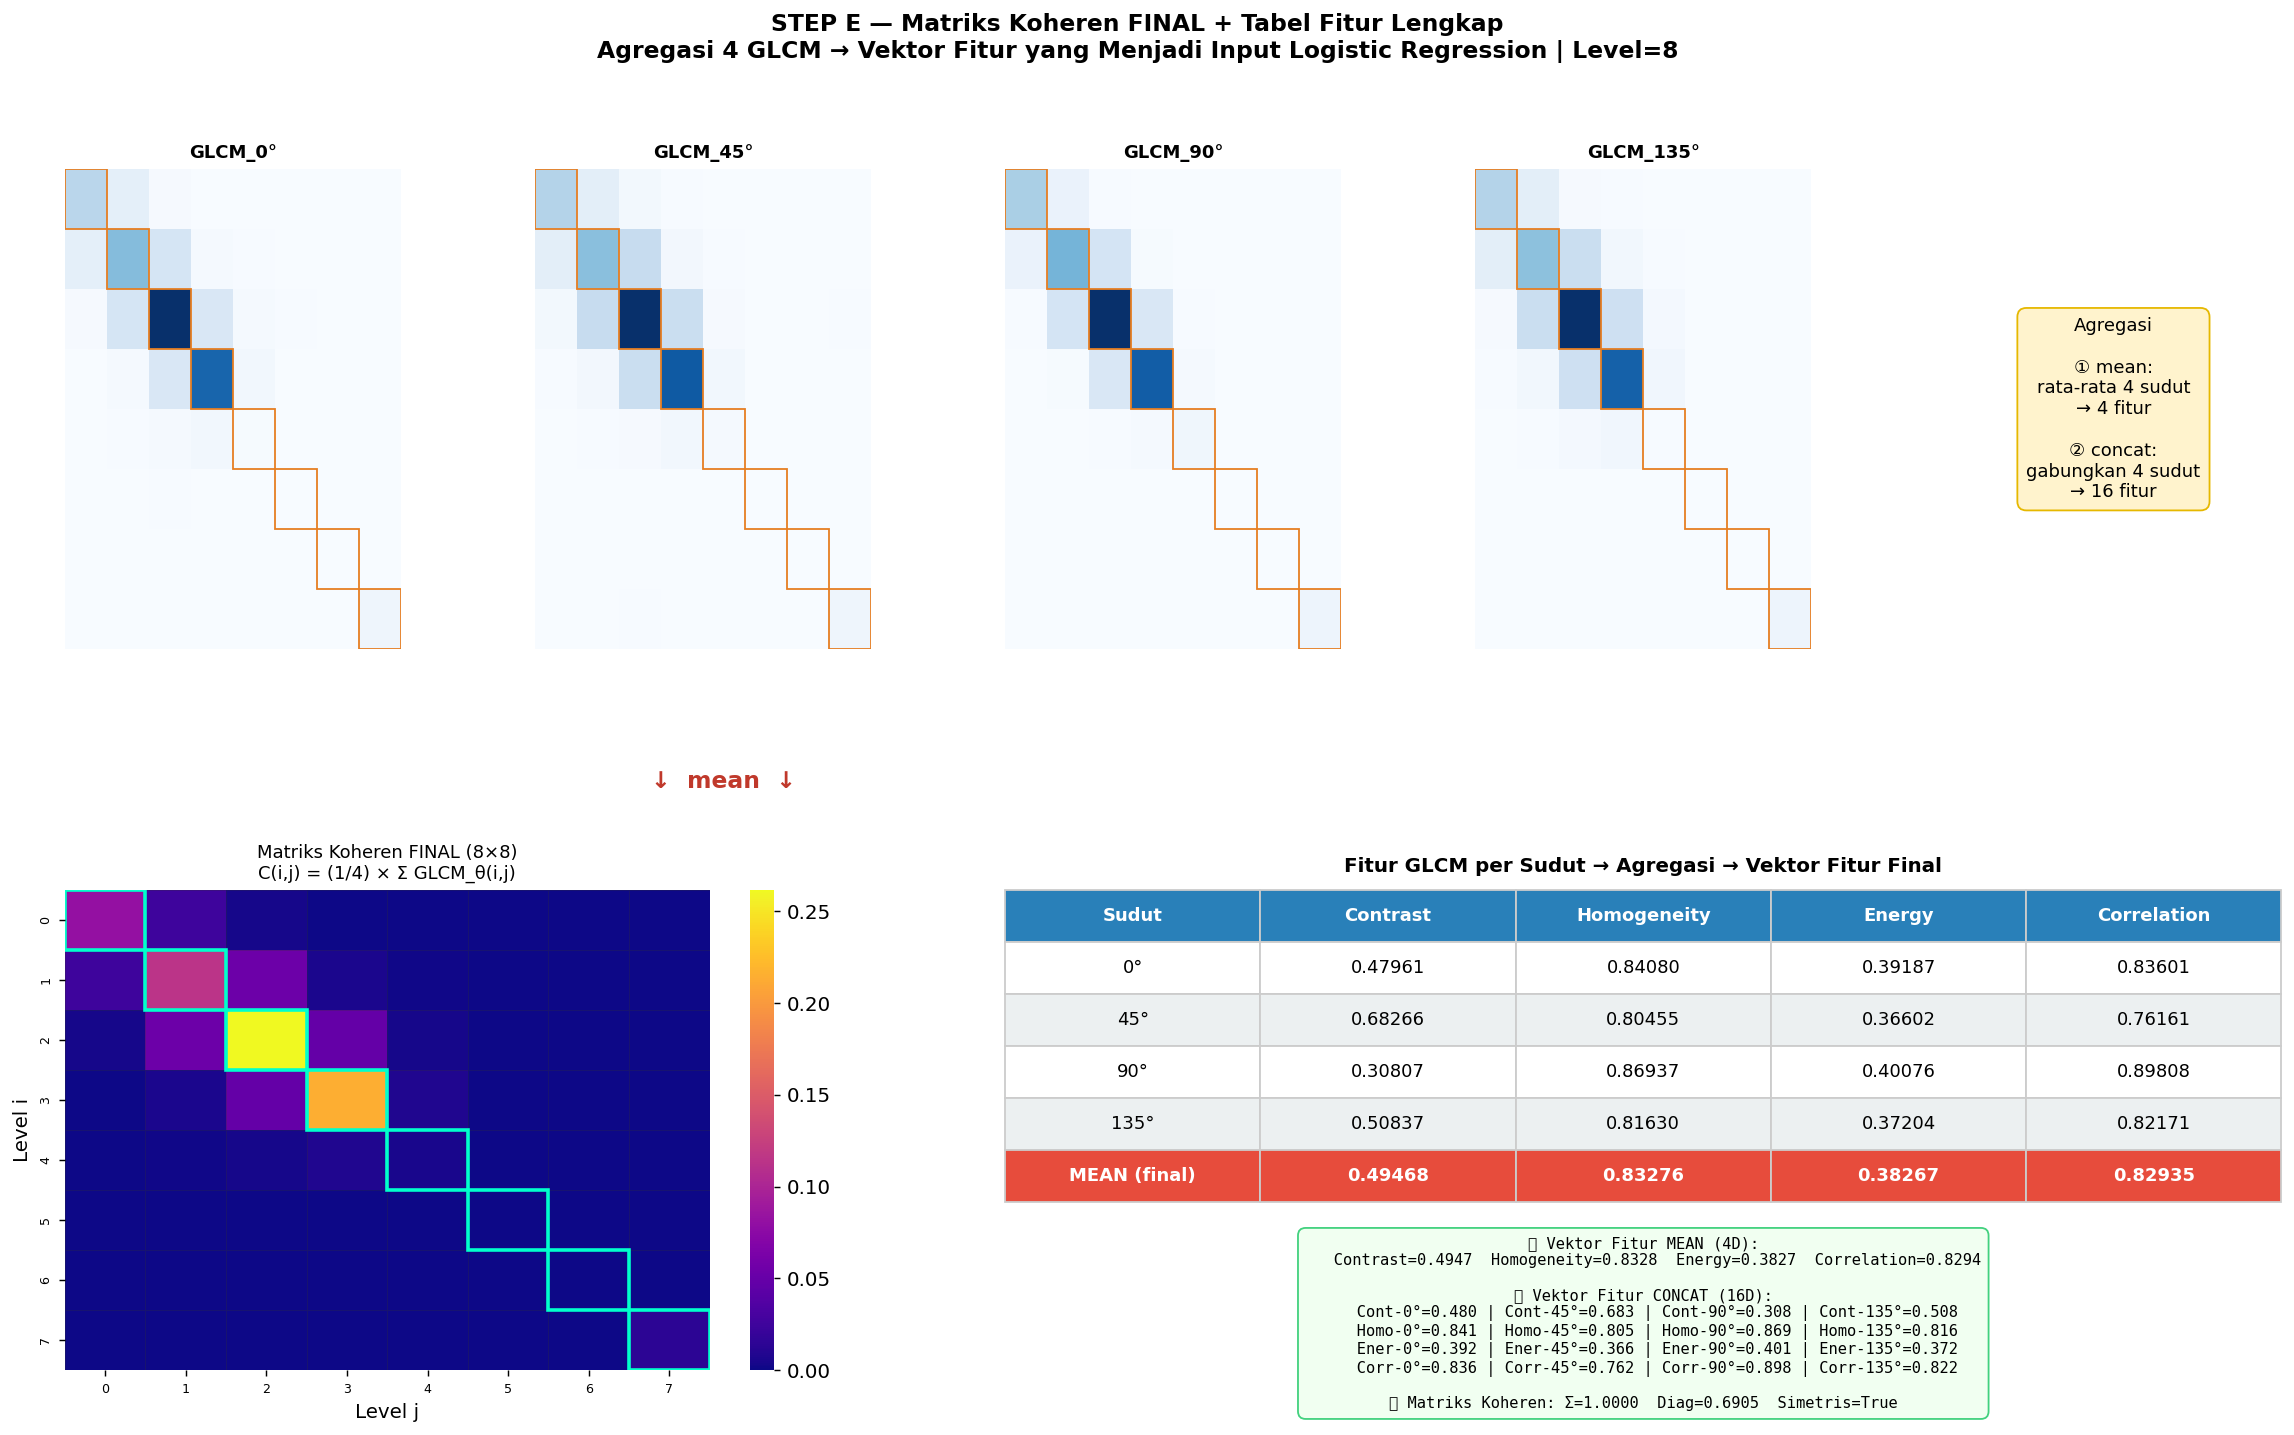

💾 Disimpan: outputs\figures\06_step_e_coherence_final.png

📊 Vektor Fitur Mean (4D) :
   contrast        = 0.494678
   homogeneity     = 0.832756
   energy          = 0.382673
   correlation     = 0.829352

📊 Vektor Fitur Concat (16D): [0.4796 0.6827 0.3081 0.5084 0.8408 0.8046 0.8694 0.8163 0.3919 0.366
 0.4008 0.372  0.836  0.7616 0.8981 0.8217]


In [16]:
# ================================================================
#  CELL 2.5 — STEP E: Matriks Koheren Final + Tabel Fitur
# ================================================================

feat_mean, _  = extract_glcm_features(img_norm_ex, LEVELS_VIS, aggregation='mean')
feat_concat, _= extract_glcm_features(img_norm_ex, LEVELS_VIS, aggregation='concat')
feat_dict_m   = dict(zip(GLCM_PROPS, feat_mean))

fig = plt.figure(figsize=(22, 12))
fig.suptitle(
    f'STEP E — Matriks Koheren FINAL + Tabel Fitur Lengkap\n'
    f'Agregasi 4 GLCM → Vektor Fitur yang Menjadi Input Logistic Regression | Level={LEVELS_VIS}',
    fontsize=13, fontweight='bold'
)
gs = gridspec.GridSpec(2, 5, figure=fig, hspace=0.5, wspace=0.4)

# ── Baris 0: 4 miniatur GLCM ──
for col in range(4):
    ax_mini = fig.add_subplot(gs[0, col])
    g2d     = glcm_ex[:, :, 0, col]
    sns.heatmap(g2d, ax=ax_mini, cmap='Blues', cbar=False,
                xticklabels=False, yticklabels=False, linewidths=0)
    for i in range(LEVELS_VIS):
        ax_mini.add_patch(mpatches.Rectangle((i, i), 1, 1, fill=False,
                                              edgecolor='#e67e22', lw=1))
    ax_mini.set_title(f'GLCM_{ANGLE_LABELS[col]}', fontsize=10, fontweight='bold')
    # Anotasi panah
    if col == 1:
        ax_mini.text(LEVELS_VIS/2+0.5, LEVELS_VIS+2.2, '↓  mean  ↓',
                     ha='center', va='center', color='#c0392b', fontsize=13, fontweight='bold',
                     transform=ax_mini.transData)

# ── Kotak tanda panah ke bawah ──
ax_arrow = fig.add_subplot(gs[0, 4])
ax_arrow.axis('off')
ax_arrow.text(0.5, 0.5,
              'Agregasi\n\n'
              '① mean:\nrata-rata 4 sudut\n→ 4 fitur\n\n'
              '② concat:\ngabungkan 4 sudut\n→ 16 fitur',
              ha='center', va='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff3cd', edgecolor='#e6b800'),
              transform=ax_arrow.transAxes)

# ── Baris 1 kiri: Coherence Matrix heatmap ──
ax_coh = fig.add_subplot(gs[1, 0:2])
sns.heatmap(
    coherence_mat, ax=ax_coh, cmap='plasma',
    xticklabels=tick_labels_v, yticklabels=tick_labels_v,
    linewidths=0.3, linecolor='#33333344', cbar=True
)
for i in range(LEVELS_VIS):
    ax_coh.add_patch(mpatches.Rectangle((i, i), 1, 1, fill=False,
                                         edgecolor='#00ffcc', lw=2))
ax_coh.set_title(
    f'Matriks Koheren FINAL ({LEVELS_VIS}×{LEVELS_VIS})\n'
    f'C(i,j) = (1/4) × Σ GLCM_θ(i,j)',
    fontsize=10
)
ax_coh.set_xlabel('Level j'); ax_coh.set_ylabel('Level i')
ax_coh.tick_params(labelsize=7)

# ── Baris 1 tengah-kanan: Tabel fitur ──
ax_tbl = fig.add_subplot(gs[1, 2:5])
ax_tbl.axis('off')

# Baris tabel: per sudut
tbl_data = []
for a_idx, a_lbl in enumerate(ANGLE_LABELS):
    row = [a_lbl] + [f'{props_per_angle[p][a_idx]:.5f}' for p in GLCM_PROPS]
    tbl_data.append(row)

# Baris mean (vektor fitur final)
tbl_data.append(['MEAN (final)'] + [f'{v:.5f}' for v in feat_mean])

col_hdrs = ['Sudut'] + [p.capitalize() for p in GLCM_PROPS]
tbl = ax_tbl.table(
    cellText=tbl_data, colLabels=col_hdrs,
    loc='center', cellLoc='center',
    bbox=[0.0, 0.35, 1.0, 0.65]
)
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if r == 0:
        cell.set_facecolor('#2980b9'); cell.set_text_props(color='white', fontweight='bold')
    elif r == len(tbl_data):   # Baris MEAN
        cell.set_facecolor('#e74c3c'); cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#ecf0f1' if r % 2 == 0 else 'white')

ax_tbl.set_title('Fitur GLCM per Sudut → Agregasi → Vektor Fitur Final',
                 fontsize=11, fontweight='bold', pad=10)

# Keterangan fitur final + concat
keterangan = (
    f"📌 Vektor Fitur MEAN (4D):\n"
    f"   Contrast={feat_dict_m['contrast']:.4f}  Homogeneity={feat_dict_m['homogeneity']:.4f}  "
    f"Energy={feat_dict_m['energy']:.4f}  Correlation={feat_dict_m['correlation']:.4f}\n\n"
    f"📌 Vektor Fitur CONCAT (16D):\n   " +
    "  ".join([f"{p[:4].cap() if hasattr(p,'cap') else p[:4].capitalize()}-{a}={v:.3f}"
               for p in GLCM_PROPS for a, v in zip(ANGLE_LABELS, graycoprops(glcm_ex, p)[0])])
)

# Ganti keterangan concat dengan versi sederhana
concat_str = "   "
for p in GLCM_PROPS:
    vals = graycoprops(glcm_ex, p)[0]
    concat_str += " | ".join([f"{p[:4].capitalize()}-{a}={v:.3f}"
                               for a, v in zip(ANGLE_LABELS, vals)]) + "\n   "

keterangan2 = (
    f"📌 Vektor Fitur MEAN (4D):\n"
    f"   Contrast={feat_dict_m['contrast']:.4f}  Homogeneity={feat_dict_m['homogeneity']:.4f}  "
    f"Energy={feat_dict_m['energy']:.4f}  Correlation={feat_dict_m['correlation']:.4f}\n\n"
    f"📌 Vektor Fitur CONCAT (16D):\n{concat_str}"
    f"\n📌 Matriks Koheren: Σ={coherence_mat.sum():.4f}  Diag={np.trace(coherence_mat):.4f}  "
    f"Simetris={np.allclose(coherence_mat, coherence_mat.T)}"
)

ax_tbl.text(0.5, 0.28, keterangan2, transform=ax_tbl.transAxes,
            ha='center', va='top', fontsize=8.5, fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0fff0', edgecolor='#2ecc71', alpha=0.9))

plt.savefig(str(OUT_FIGS / '06_step_e_coherence_final.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Disimpan:", OUT_FIGS / '06_step_e_coherence_final.png')
print(f"\n📊 Vektor Fitur Mean (4D) :")
for k, v in feat_dict_m.items():
    print(f"   {k:15s} = {v:.6f}")
print(f"\n📊 Vektor Fitur Concat (16D): {np.round(feat_concat, 4)}")


## STEP F — Visualisasi Interpretatif: Mengapa Nilai Fitur Segitu?

Bagian paling penting untuk memahami GLCM secara konseptual.  
Kita tunjukkan **secara visual dari gambar itu sendiri** mengapa nilai fitur tertentu dihasilkan.

| Fitur | Visualisasi Proxy | Hubungan |
|---|---|---|
| **Contrast** | Sobel Edge Map | Banyak tepi tajam → Contrast **tinggi** |
| **Homogeneity** | Peta Variansi Lokal | Area seragam (var rendah) → Homogeneity **tinggi** |
| **Energy** | Std-Dev Lokal | Distribusi merata → Energy **rendah** |
| **Correlation** | Gradient Magnitude (Smooth) | Transisi halus & konsisten → Correlation **tinggi** |


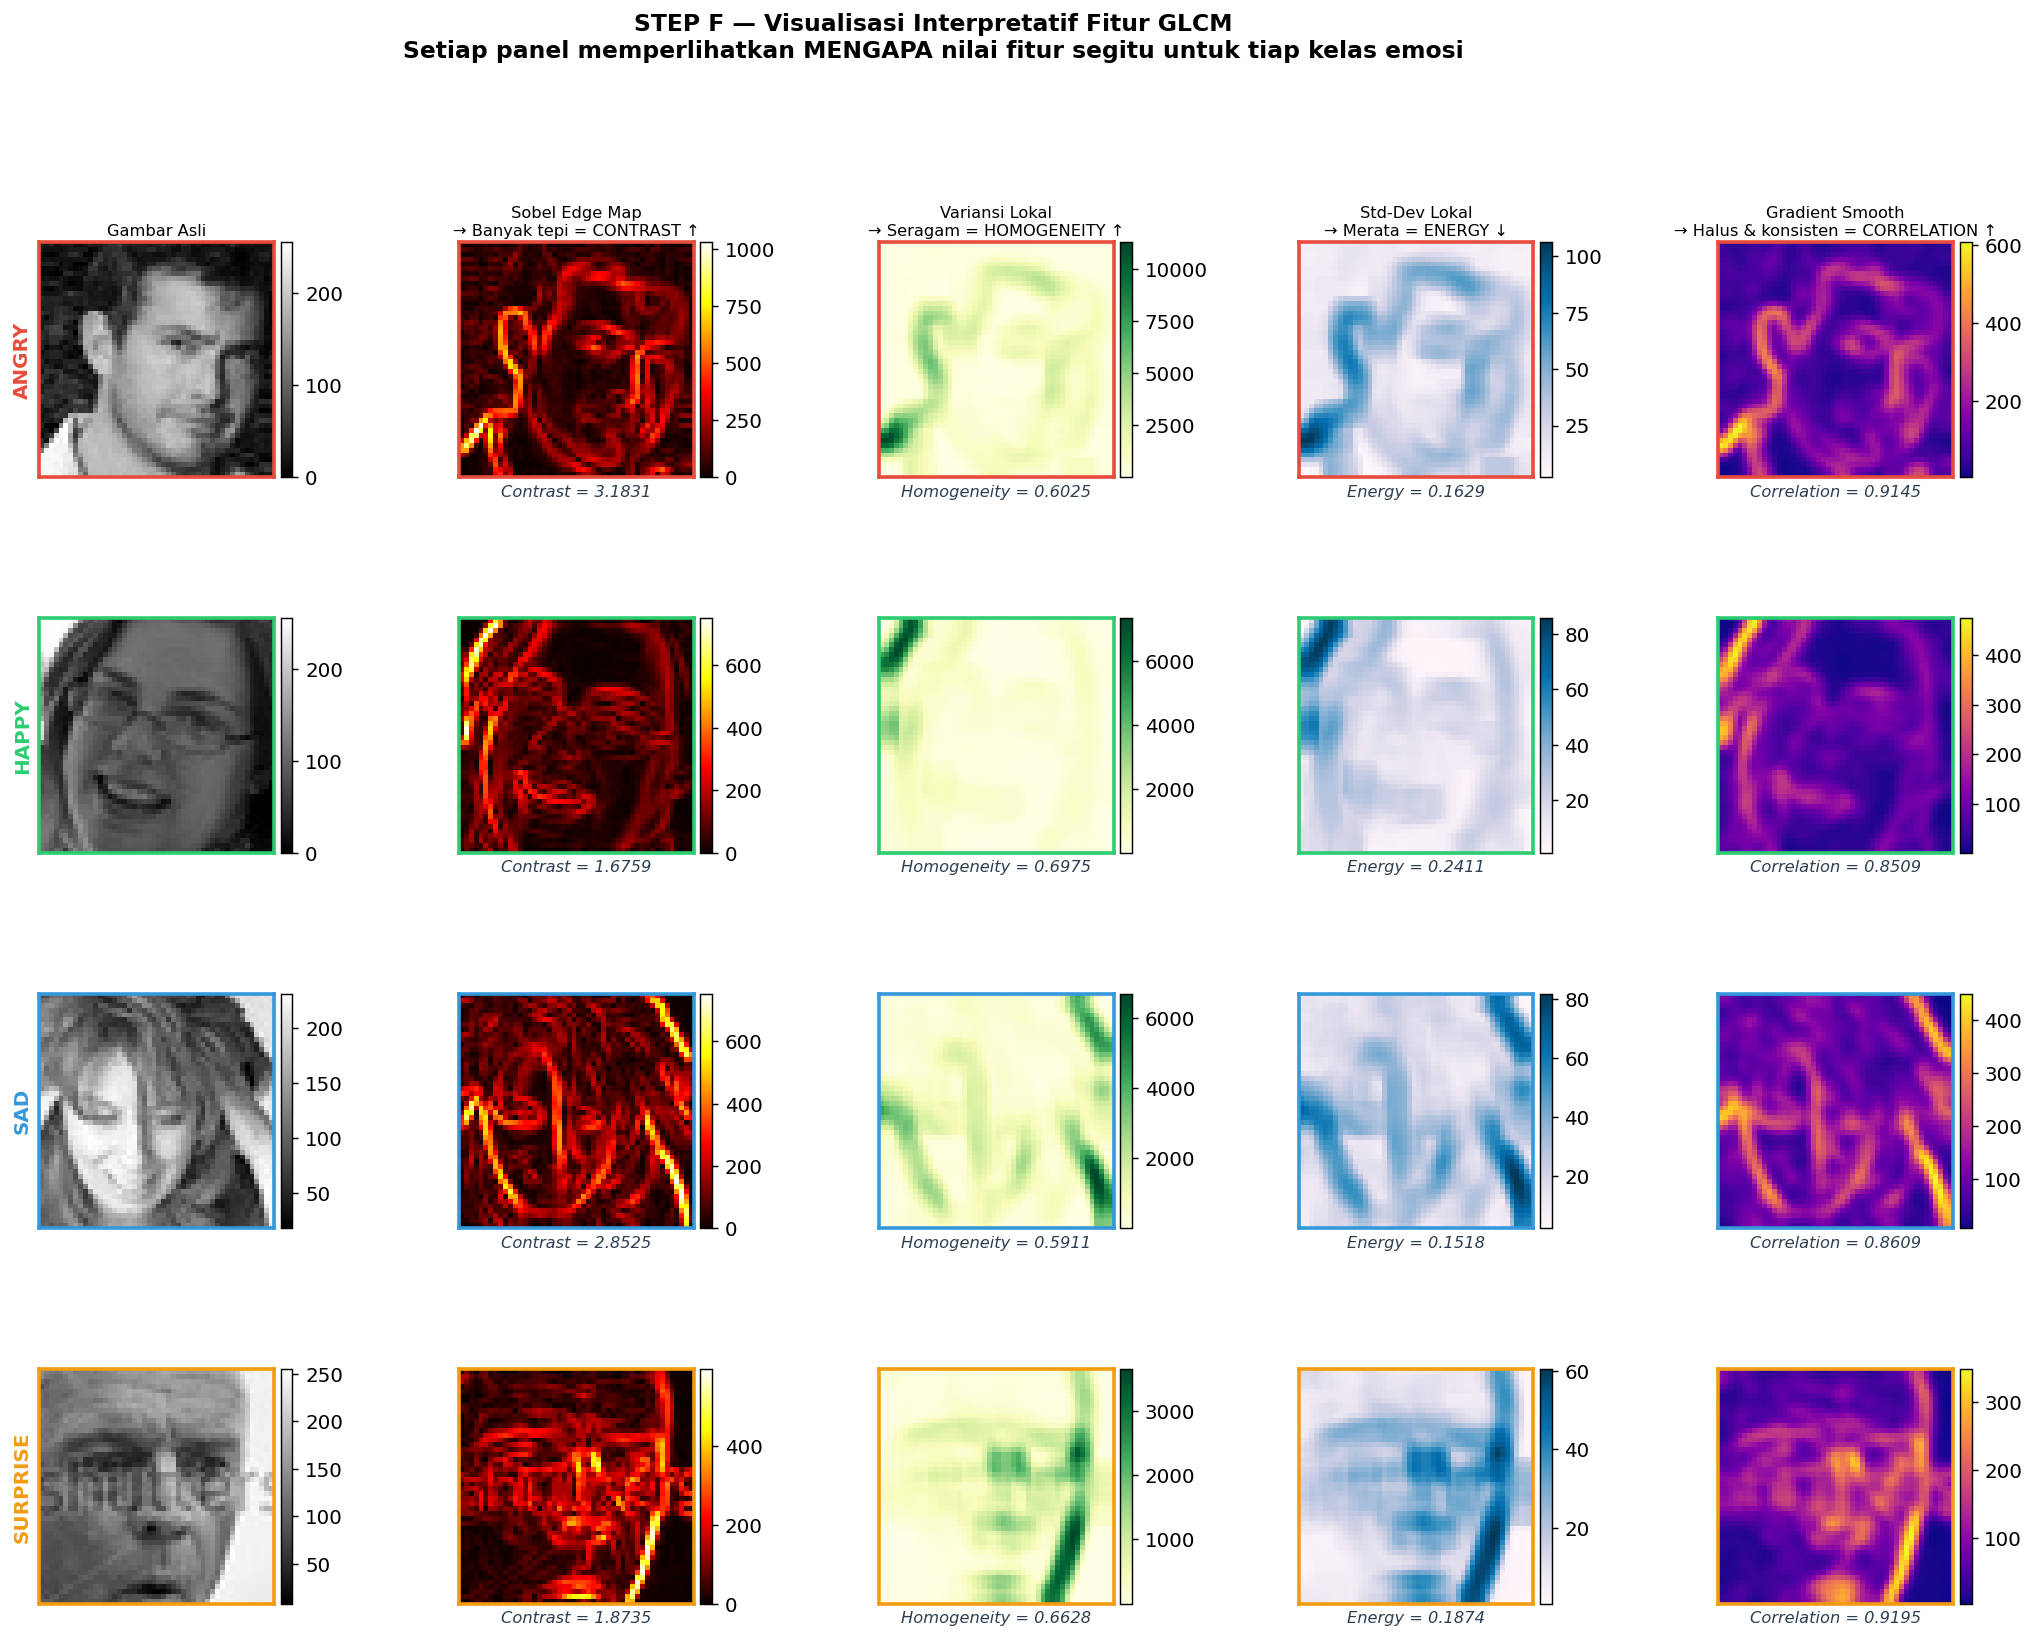

💾 Disimpan: outputs\figures\07_step_f_interpretasi_glcm.png


In [17]:
# ================================================================
#  CELL 2.6 — STEP F: Visualisasi Interpretatif Fitur GLCM
# ================================================================

def compute_local_variance(img, kernel_size=7):
    img_f   = img.astype(np.float32)
    mean_sq = cv2.blur(img_f**2, (kernel_size, kernel_size))
    sq_mean = cv2.blur(img_f,    (kernel_size, kernel_size))**2
    return np.clip(mean_sq - sq_mean, 0, None)

samples_interp = get_sample_per_class(train_raw, train_norm, train_labels)

panel_titles = [
    'Gambar Asli',
    'Sobel Edge Map\n→ Banyak tepi = CONTRAST ↑',
    'Variansi Lokal\n→ Seragam = HOMOGENEITY ↑',
    'Std-Dev Lokal\n→ Merata = ENERGY ↓',
    'Gradient Smooth\n→ Halus & konsisten = CORRELATION ↑',
]

fig, axes = plt.subplots(
    len(CLASSES), 5,
    figsize=(5*4, len(CLASSES)*3.4),
    gridspec_kw={'hspace': 0.6, 'wspace': 0.25}
)
fig.suptitle(
    'STEP F — Visualisasi Interpretatif Fitur GLCM\n'
    'Setiap panel memperlihatkan MENGAPA nilai fitur segitu untuk tiap kelas emosi',
    fontsize=13, fontweight='bold', y=1.01
)

for row, (cls, color) in enumerate(zip(CLASSES, COLORS)):
    img_r = samples_interp[cls]['raw']
    img_n = samples_interp[cls]['norm']

    sx = cv2.Sobel(img_r, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(img_r, cv2.CV_64F, 0, 1, ksize=3)
    edge_map    = np.sqrt(sx**2 + sy**2)
    local_var   = compute_local_variance(img_r, 7)
    local_std   = np.sqrt(local_var + 1e-6)
    grad_smooth = cv2.GaussianBlur(edge_map, (5,5), 0)

    feat, _ = extract_glcm_features(img_n, levels=16, aggregation='mean')
    fd = dict(zip(GLCM_PROPS, feat))

    panels = [
        (img_r,       'gray',   None),
        (edge_map,    'hot',    f"Contrast = {fd['contrast']:.4f}"),
        (local_var,   'YlGn',   f"Homogeneity = {fd['homogeneity']:.4f}"),
        (local_std,   'PuBu',   f"Energy = {fd['energy']:.4f}"),
        (grad_smooth, 'plasma', f"Correlation = {fd['correlation']:.4f}"),
    ]

    for col, (panel_img, cmap, feat_val) in enumerate(panels):
        ax = axes[row, col]
        im = ax.imshow(panel_img, cmap=cmap)
        plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)

        if col == 0:
            ax.set_ylabel(f'{cls.upper()}', fontsize=11, color=color, fontweight='bold')
        if row == 0:
            ax.set_title(panel_titles[col], fontsize=9, pad=4)
        if feat_val:
            ax.set_xlabel(feat_val, fontsize=9, color='#2c3e50', style='italic')

        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_edgecolor(color); sp.set_linewidth(2)

plt.savefig(str(OUT_FIGS / '07_step_f_interpretasi_glcm.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Disimpan:", OUT_FIGS / '07_step_f_interpretasi_glcm.png')


⏳ Menghitung rata-rata fitur GLCM per kelas...
   [angry] 3100 gambar ✅
   [happy] 3100 gambar ✅
   [sad] 3100 gambar ✅
   [surprise] 3100 gambar ✅


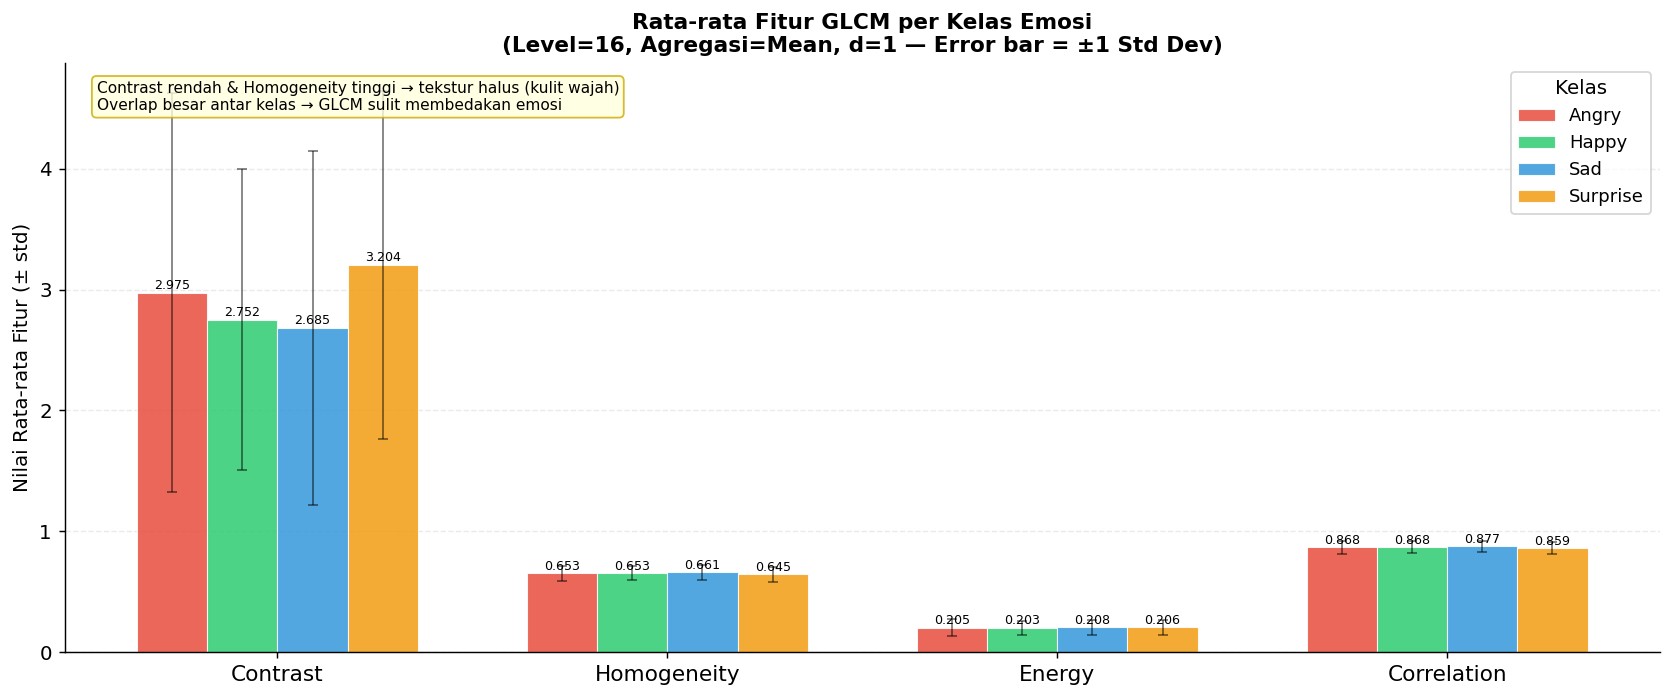

💾 Disimpan: outputs\figures\08_glcm_feature_bar.png


In [18]:
# ================================================================
#  CELL 2.7 — Perbandingan Rata-rata Fitur GLCM Antar Kelas
# ================================================================
# Bar chart fitur rata-rata dari SEMUA gambar per kelas (± std)

class_feat_means = {}
class_feat_stds  = {}

print("⏳ Menghitung rata-rata fitur GLCM per kelas...")
for cls in CLASSES:
    feats = [
        extract_glcm_features(img, levels=16, aggregation='mean')[0]
        for img, lbl in zip(train_norm, train_labels) if lbl == cls
    ]
    arr = np.array(feats)
    class_feat_means[cls] = arr.mean(axis=0)
    class_feat_stds[cls]  = arr.std(axis=0)
    print(f"   [{cls}] {len(feats)} gambar ✅")

x = np.arange(len(GLCM_PROPS))
w = 0.18
fig, ax = plt.subplots(figsize=(13, 5.5))

for i, (cls, color) in enumerate(zip(CLASSES, COLORS)):
    offset = (i - (len(CLASSES)-1)/2) * w
    bars = ax.bar(x + offset, class_feat_means[cls], w,
                  label=cls.capitalize(), color=color, alpha=0.85,
                  edgecolor='white', linewidth=0.6)
    ax.errorbar(x + offset, class_feat_means[cls], yerr=class_feat_stds[cls],
                fmt='none', ecolor='black', elinewidth=1, capsize=3, alpha=0.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.004,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([p.capitalize() for p in GLCM_PROPS], fontsize=12)
ax.set_ylabel('Nilai Rata-rata Fitur (± std)', fontsize=11)
ax.set_title(
    'Rata-rata Fitur GLCM per Kelas Emosi\n'
    '(Level=16, Agregasi=Mean, d=1 — Error bar = ±1 Std Dev)',
    fontsize=12, fontweight='bold'
)
ax.legend(title='Kelas', fontsize=10)
ax.grid(axis='y', alpha=0.25, ls='--'); ax.set_axisbelow(True)

# Anotasi interpretasi
note = ("Contrast rendah & Homogeneity tinggi → tekstur halus (kulit wajah)\n"
        "Overlap besar antar kelas → GLCM sulit membedakan emosi")
ax.text(0.02, 0.97, note, transform=ax.transAxes, va='top', fontsize=8.5,
        bbox=dict(boxstyle='round', facecolor='#ffffdd', edgecolor='#ccaa00', alpha=0.8))

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '08_glcm_feature_bar.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Disimpan:", OUT_FIGS / '08_glcm_feature_bar.png')


---
# BAGIAN 3 — Cara Kerja Logistic Regression (Visualisasi Lengkap)

---

## 🔶 Mengapa BUKAN Linear Regression?

Sebelum memahami Logistic Regression, perlu tahu mengapa **Linear Regression tidak bisa** dipakai untuk klasifikasi:

```
Linear Regression:   ŷ = w·x + b   → output bisa bernilai APA SAJA (-∞ sampai +∞)
                                       Tidak bisa dijadikan probabilitas!

Contoh buruk:
  x=0.1 → ŷ= -0.5  ← negatif, tidak masuk akal untuk probabilitas
  x=0.9 → ŷ=  1.8  ← lebih dari 1, tidak masuk akal untuk probabilitas
```

---

## 🔶 Fungsi Sigmoid: Jantung Logistic Regression (Biner)

Logistic Regression menambahkan fungsi **Sigmoid** untuk "menekan" output ke range [0,1]:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Sifat Sigmoid:**
```
z → -∞  :  σ(z) → 0.0   (pasti Kelas 0)
z =  0  :  σ(z) = 0.5   (tepat di batas)
z → +∞  :  σ(z) → 1.0   (pasti Kelas 1)
```

**Interpretasi kurva S (sigmoid):**
- Kiri (z negatif besar) → kurva mendekati 0 → prediksi: **TIDAK / Kelas 0**
- Tengah (z ≈ 0) → kurva di 0.5 → **tidak yakin**, bisa ke mana saja
- Kanan (z positif besar) → kurva mendekati 1 → prediksi: **YA / Kelas 1**

```
Contoh (klasifikasi "apakah emosi ini happy?"):
  x = [Contrast=0.8, Homog=0.5, Energy=0.1, Corr=0.9]
  z  = w₁×0.8 + w₂×0.5 + w₃×0.1 + w₄×0.9 + b
  z  = +2.3   (misalnya)
  σ(2.3) = 1/(1+e^{-2.3}) = 0.909  → 90.9% kemungkinan HAPPY ✓
```

**Threshold prediksi:**
```
σ(z) ≥ 0.5  →  z ≥ 0  →  Prediksi: Kelas 1 (positif)
σ(z) < 0.5  →  z < 0  →  Prediksi: Kelas 0 (negatif)
```

---

## 🔶 Dari Biner ke Multi-Class: Fungsi Softmax

Untuk klasifikasi **4 kelas** (angry/happy/sad/surprise),  
sigmoid digantikan oleh **Softmax**:

$$P(\text{kelas}=k \mid x) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

```
Setiap kelas k punya vektor bobot sendiri wₖ:

z₁ = w₁·x + b₁   (skor untuk ANGRY)
z₂ = w₂·x + b₂   (skor untuk HAPPY)
z₃ = w₃·x + b₃   (skor untuk SAD)
z₄ = w₄·x + b₄   (skor untuk SURPRISE)

Misalnya z = [+1.20, +2.80, -0.50, +0.30]
→ exp(z) = [3.32, 16.44, 0.61, 1.35]   (selalu positif!)
→ Σ exp(z) = 21.72
→ Softmax:
    P(angry)   = 3.32 / 21.72  = 0.153  = 15.3%
    P(happy)   = 16.44 / 21.72 = 0.757  = 75.7%  ← TERBESAR → PREDIKSI
    P(sad)     = 0.61 / 21.72  = 0.028  =  2.8%
    P(surprise)= 1.35 / 21.72  = 0.062  =  6.2%
    ─────────────────────────────────────────────
    Σ                                    = 100%  ✓
```

> 💡 Softmax menjamin semua probabilitas positif dan berjumlah 1.0

---

## 🔶 Cara Logistic Regression Belajar

### Loss Function — Cross-Entropy

$$L = -\sum_{k} y_k^{\text{true}} \cdot \log P(y=k \mid x)$$

```
Jika label asli = HAPPY (y_happy=1, sisanya=0):
  L = -(1 × log(0.757) + 0 + 0 + 0)
    = -log(0.757) = 0.278

Loss kecil → prediksi baik
Loss besar → prediksi buruk → bobot perlu diperbaiki
```

### Proses Pembelajaran (Gradient Descent)

```
ITERASI 1:
  Inisialisasi bobot w secara acak (mendekati 0)
  Hitung z = w·x + b untuk semua data
  Hitung P = softmax(z)
  Hitung Loss L = cross-entropy(P, y_true)
  Hitung gradien ∂L/∂w = (P - y_true) · x
  Update: w_baru = w_lama - α × ∂L/∂w

ITERASI 2, 3, ..., 1000:
  Ulangi sampai Loss konvergen (tidak turun lagi)
  α (learning rate) = kecepatan update

sklearn: max_iter=1000 menentukan batas iterasi maksimum
```

### Mengapa Logistic Regression disebut "Model Linear"?

```
Decision Boundary = garis/bidang yang memisahkan kelas:

  w₁·x₁ + w₂·x₂ + w₃·x₃ + w₄·x₄ + b = 0
  ↑ ini adalah PERSAMAAN LINEAR (hyperplane)

Artinya:
  → Di satu sisi hyperplane = satu kelas
  → Di sisi lain = kelas berbeda

Keterbatasan:
  → Jika kelas tidak bisa dipisahkan dengan garis lurus
    → Logistic Regression GAGAL memisahkan dengan baik
  → Inilah mengapa GLCM + LR tidak optimal untuk emosi wajah
    (kelas overlap, tidak linear separable)
```

---

## 🔶 Ringkasan Parameter Model

| Parameter sklearn | Nilai | Penjelasan |
|:-----------------|:-----:|:-----------|
| `max_iter` | 1000 | Maks iterasi gradient descent |
| `multi_class` | `'auto'` | Otomatis pilih softmax jika > 2 kelas |
| `solver` | `'lbfgs'` | Algoritma optimasi (Limited-memory BFGS) |
| `C` | 1.0 | Regularisasi (1/λ) — semakin kecil = lebih regularized |
| `random_state` | 42 | Seed untuk reprodusibilitas |

---


## Visualisasi Sigmoid & Logistic Regression

Dua visualisasi berikut menjelaskan:
1. **Kurva Sigmoid** — fungsi S yang mengubah bilangan real ke probabilitas [0,1]  
2. **Logistic Regression Biner** — bagaimana decision boundary bekerja pada data 1D  
3. **Perbandingan Linear vs Logistic** — mengapa tidak pakai Linear Regression  
4. **Dari Sigmoid ke Softmax** — ekstensi ke multi-class (4 emosi)


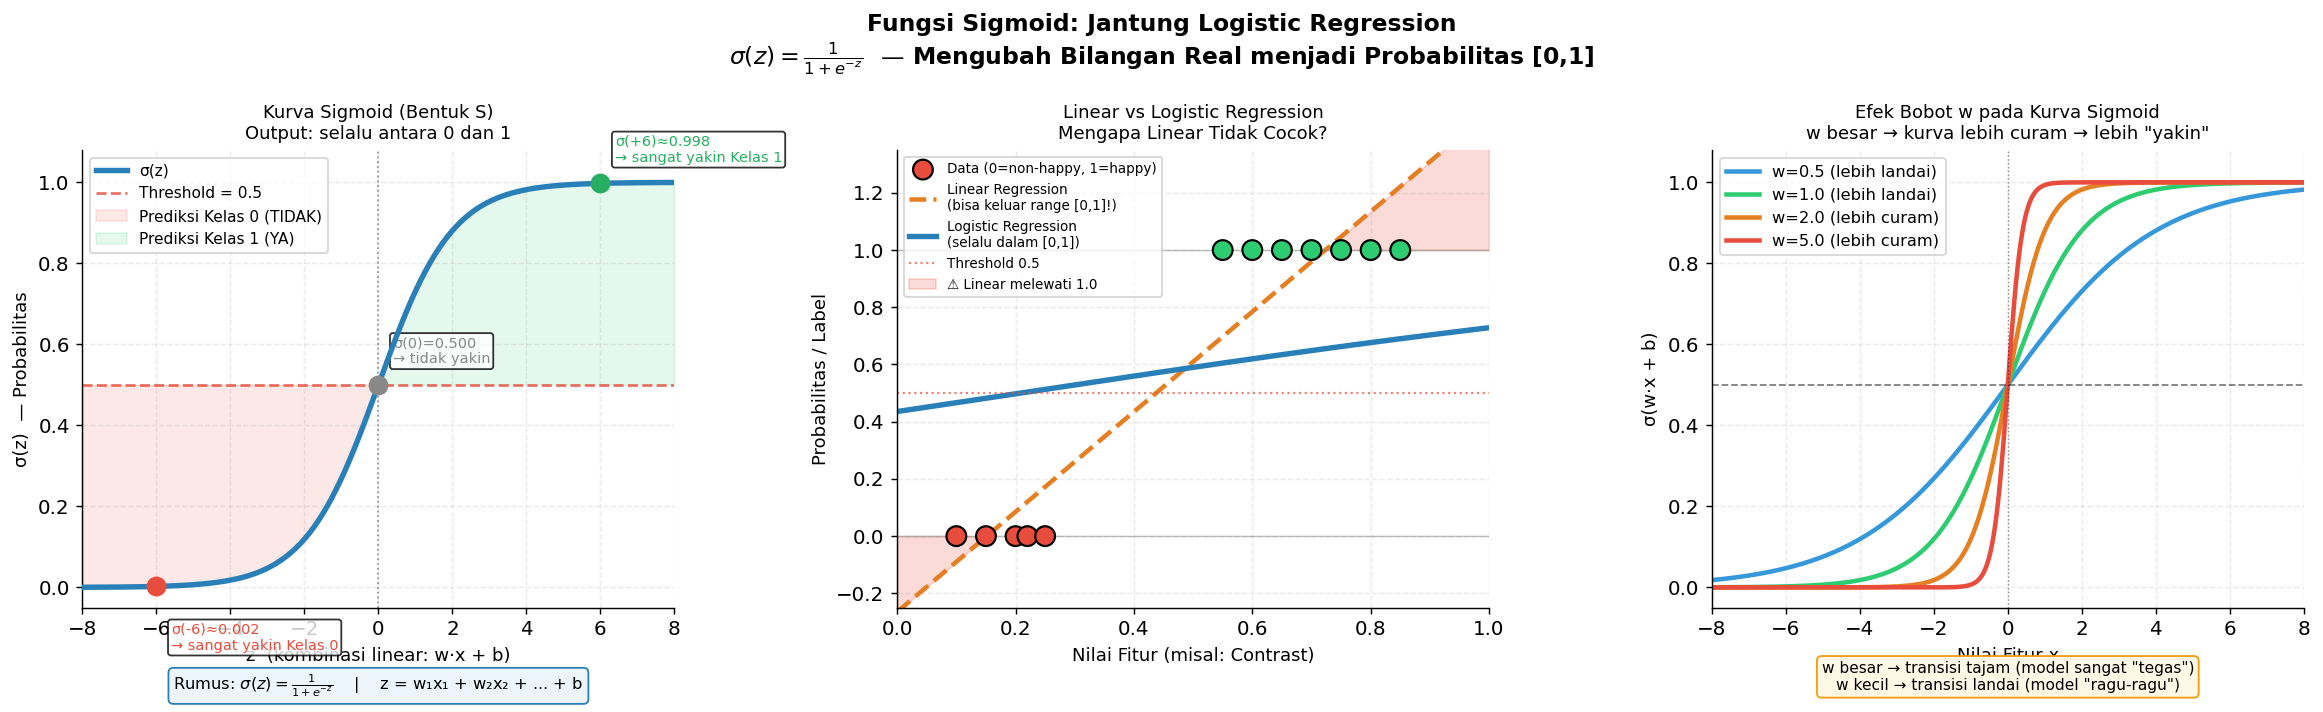

💾 Disimpan: outputs\figures\LR_01_sigmoid_basics.png


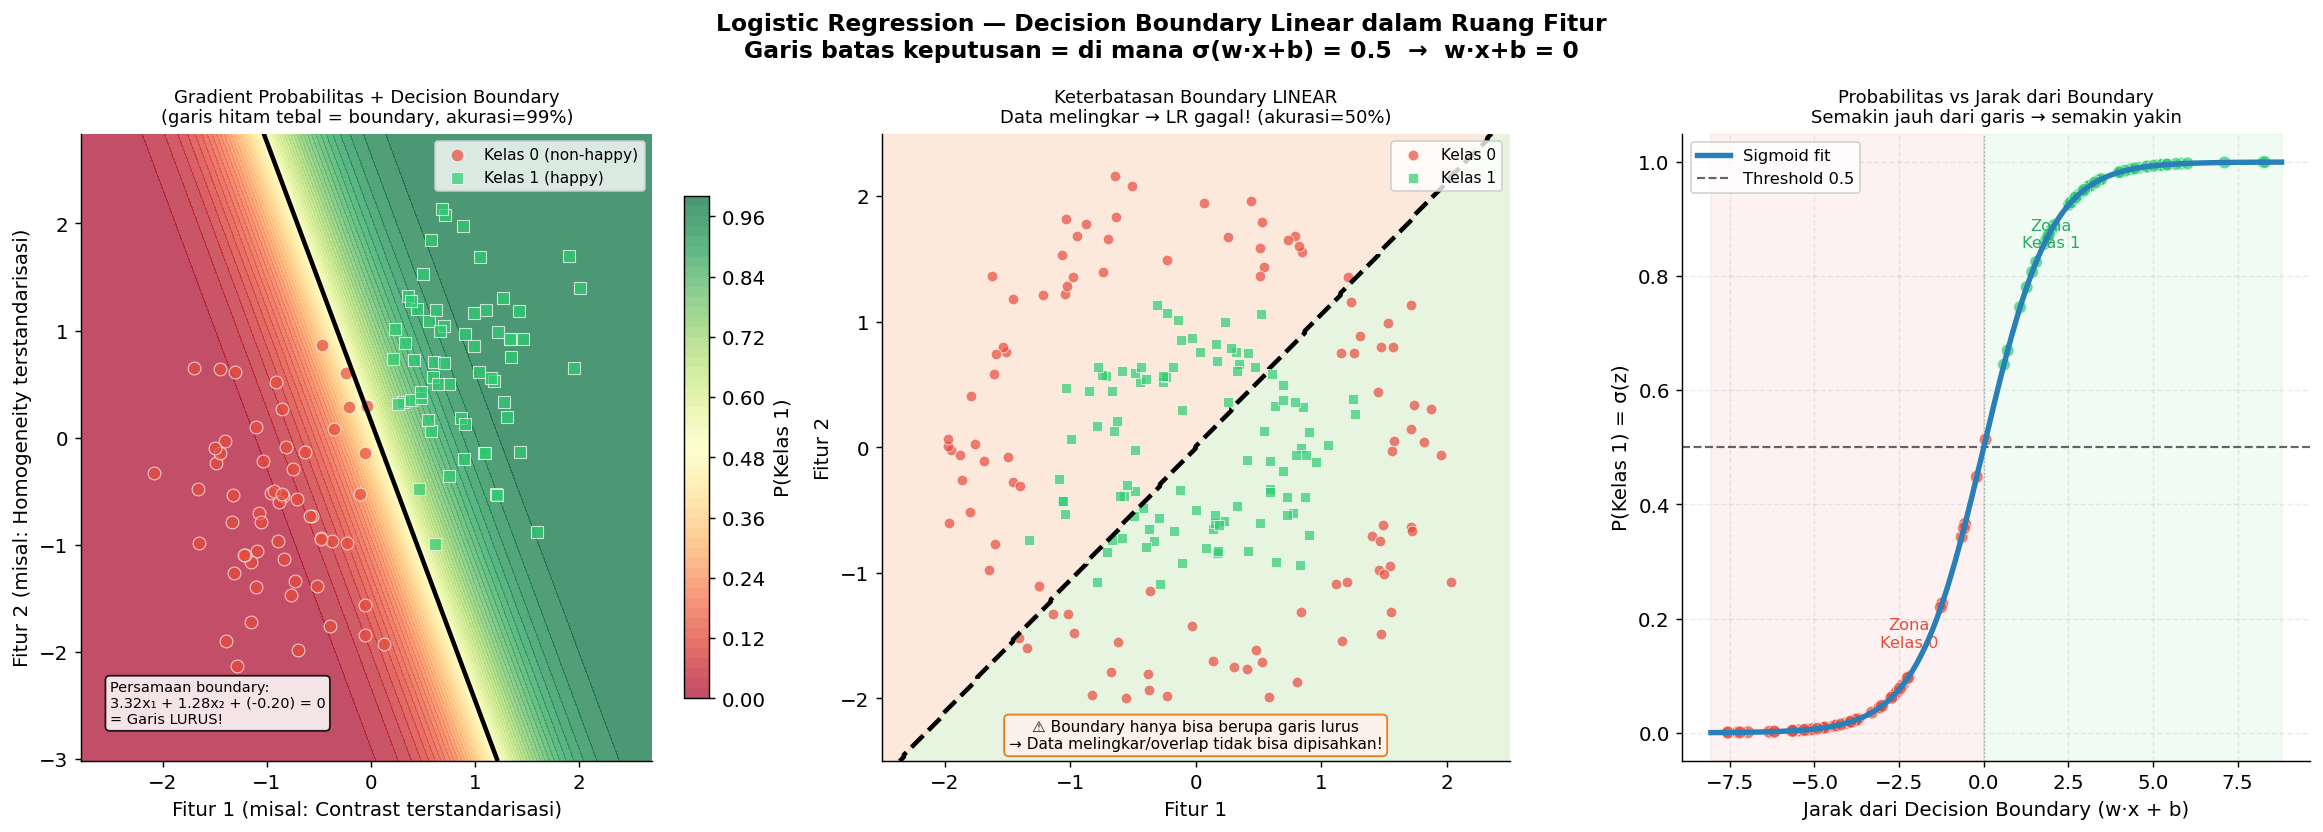

💾 Disimpan: outputs\figures\LR_02_decision_boundary_binary.png


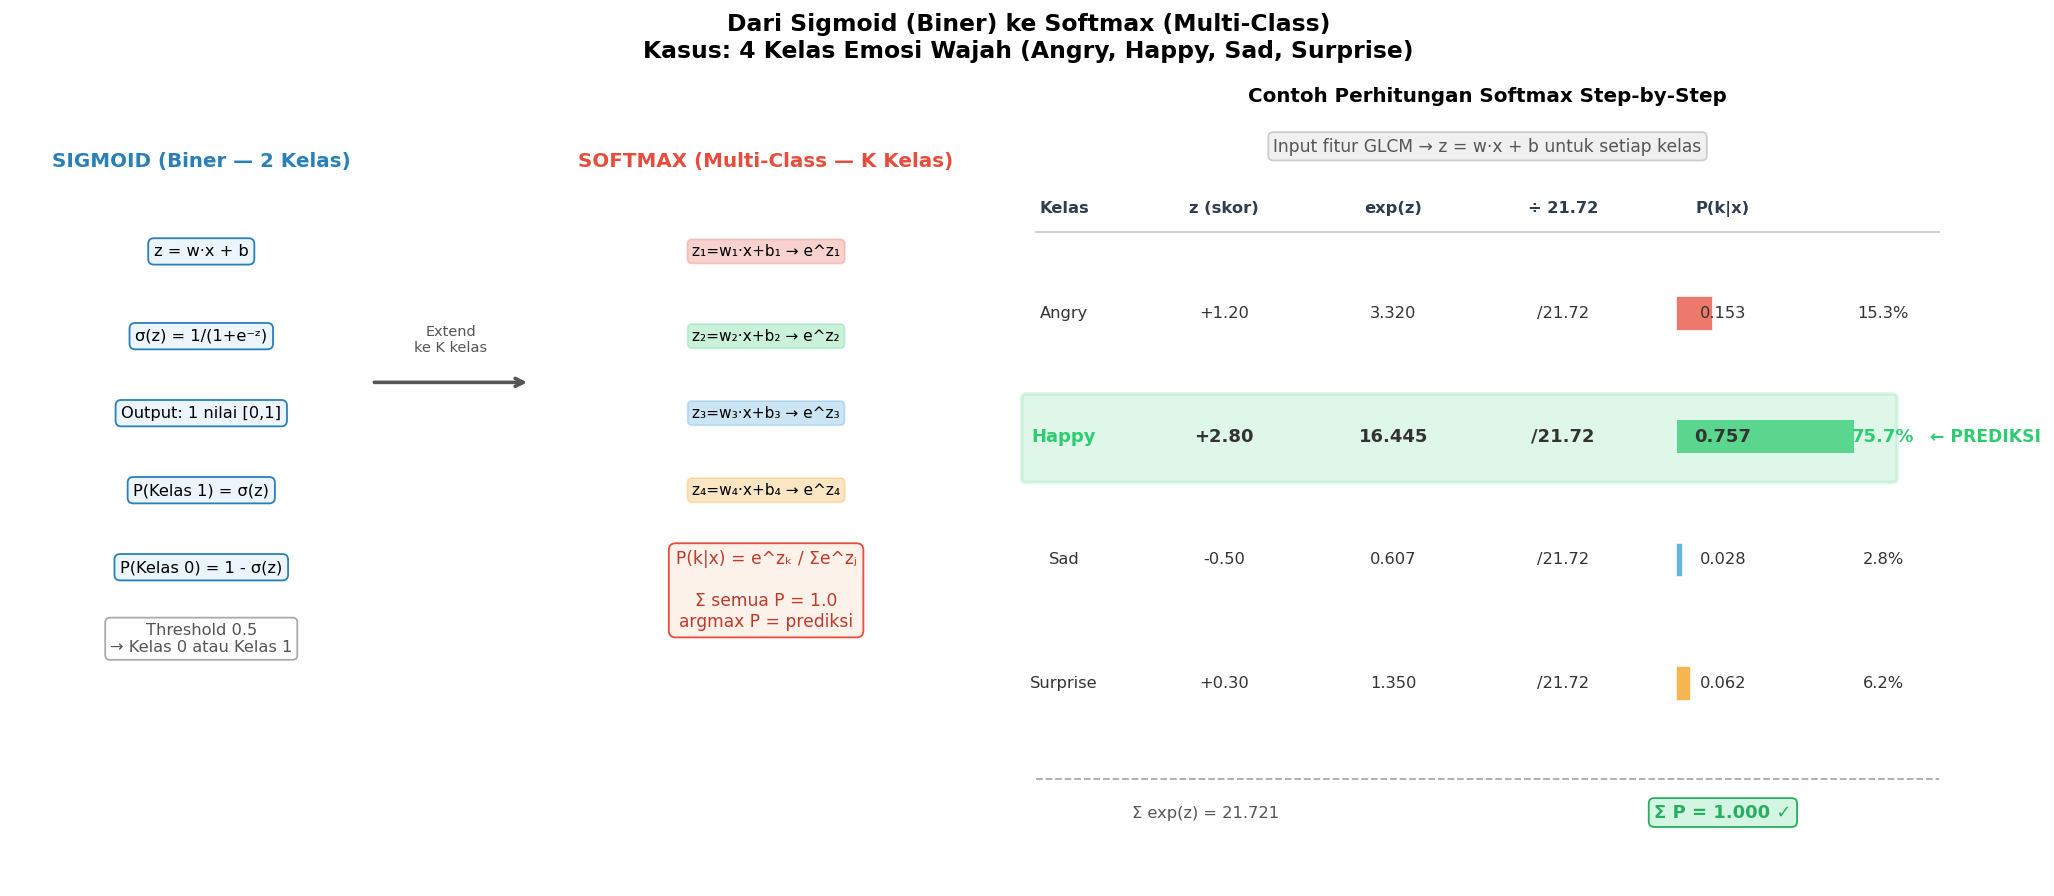

💾 Disimpan: outputs\figures\LR_03_sigmoid_to_softmax.png

✅ Semua visualisasi Logistic Regression selesai!
   LR_01_sigmoid_basics.png         — Kurva sigmoid + Linear vs Logistic
   LR_02_decision_boundary_binary.png— Decision boundary + keterbatasan linear
   LR_03_sigmoid_to_softmax.png      — Sigmoid → Softmax + contoh numerik


In [19]:
# ================================================================
#  CELL 3.0b — Visualisasi Sigmoid, Logistic Regression Biner
#              & Perbandingan Linear vs Logistic
# ================================================================
# Tidak butuh dataset — semua sintetis untuk ilustrasi konsep

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

np.random.seed(42)

# ─── Figure 1: Kurva Sigmoid + Interpretasi ──────────────────────

z_range = np.linspace(-8, 8, 400)
sigmoid  = 1 / (1 + np.exp(-z_range))

fig1, axes1 = plt.subplots(1, 3, figsize=(18, 6))
fig1.suptitle(
    'Fungsi Sigmoid: Jantung Logistic Regression\n'
    r'$\sigma(z) = \frac{1}{1+e^{-z}}$  — Mengubah Bilangan Real menjadi Probabilitas [0,1]',
    fontsize=13, fontweight='bold'
)

# ── Panel 1: Kurva sigmoid murni ──
ax = axes1[0]
ax.plot(z_range, sigmoid, color='#2980b9', lw=3, zorder=5, label='σ(z)')
ax.axhline(0.5, color='#e74c3c', lw=1.5, ls='--', alpha=0.8, label='Threshold = 0.5')
ax.axvline(0.0, color='#555',    lw=1,   ls=':', alpha=0.6)

# Shade: kiri = kelas 0, kanan = kelas 1
ax.fill_between(z_range, sigmoid, 0.5,
                where=(z_range < 0), alpha=0.12, color='#e74c3c',
                label='Prediksi Kelas 0 (TIDAK)')
ax.fill_between(z_range, sigmoid, 0.5,
                where=(z_range > 0), alpha=0.12, color='#2ecc71',
                label='Prediksi Kelas 1 (YA)')

# Anotasi titik penting
for z_ex, label, color, va in [
    (-6,   'σ(-6)≈0.002\n→ sangat yakin Kelas 0', '#e74c3c', 'bottom'),
    (0,    'σ(0)=0.500\n→ tidak yakin', '#888', 'top'),
    (+6,   'σ(+6)≈0.998\n→ sangat yakin Kelas 1', '#27ae60', 'top'),
]:
    s_val = 1/(1+np.exp(-z_ex))
    ax.scatter(z_ex, s_val, s=100, color=color, zorder=10)
    ax.annotate(label, (z_ex, s_val), textcoords='offset points',
                xytext=(8, 12 if va=='top' else -35),
                fontsize=8, color=color,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

ax.set_xlabel('z  (kombinasi linear: w·x + b)', fontsize=10)
ax.set_ylabel('σ(z)  — Probabilitas', fontsize=10)
ax.set_title('Kurva Sigmoid (Bentuk S)\nOutput: selalu antara 0 dan 1', fontsize=10)
ax.set_ylim(-0.05, 1.08); ax.set_xlim(-8, 8)
ax.legend(fontsize=8.5, loc='upper left')
ax.grid(alpha=0.25, ls='--')

# Rumus di bawah
ax.text(0.5, -0.18,
        r'Rumus: $\sigma(z) = \frac{1}{1+e^{-z}}$'
        '    |    z = w₁x₁ + w₂x₂ + ... + b',
        transform=ax.transAxes, ha='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#ebf5fb', edgecolor='#2980b9'))

# ── Panel 2: Perbandingan Linear vs Logistic ──
ax = axes1[1]

# Data sintetis 1D: nilai fitur vs label (0=non-happy, 1=happy)
x_data = np.array([0.1, 0.15, 0.2, 0.22, 0.25, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85])
y_data = np.array([0,   0,    0,   0,    0,    1,   1,   1,    1,   1,   1,    1  ])
x_plot = np.linspace(0, 1, 300)

# Linear regression fit (pakai np.polyfit)
coeffs   = np.polyfit(x_data, y_data, 1)
y_linear = np.polyval(coeffs, x_plot)

# Logistic fit (manual sederhana)
# Pakai sklearn untuk mendapatkan fit yang benar
from sklearn.linear_model import LogisticRegression as LR_demo
lr_demo = LR_demo(random_state=42, max_iter=1000)
lr_demo.fit(x_data.reshape(-1,1), y_data)
y_logistic = lr_demo.predict_proba(x_plot.reshape(-1,1))[:, 1]

ax.scatter(x_data, y_data, s=120, zorder=10,
           c=['#e74c3c' if y==0 else '#2ecc71' for y in y_data],
           edgecolors='black', linewidth=1.2,
           label='Data (0=non-happy, 1=happy)')

ax.plot(x_plot, y_linear,   color='#e67e22', lw=2.5, ls='--',
        label=f'Linear Regression\n(bisa keluar range [0,1]!)')
ax.plot(x_plot, y_logistic, color='#2980b9', lw=3,
        label='Logistic Regression\n(selalu dalam [0,1])')

ax.axhline(0.0, color='gray', lw=0.8, alpha=0.5)
ax.axhline(1.0, color='gray', lw=0.8, alpha=0.5)
ax.axhline(0.5, color='#e74c3c', lw=1.2, ls=':', alpha=0.7, label='Threshold 0.5')

# Highlight area masalah linear regression
ax.fill_between(x_plot, y_linear, 1.0,
                where=(y_linear > 1.0), alpha=0.2, color='#e74c3c',
                label='⚠️ Linear melewati 1.0')
ax.fill_between(x_plot, y_linear, 0.0,
                where=(y_linear < 0.0), alpha=0.2, color='#e74c3c')

ax.set_xlabel('Nilai Fitur (misal: Contrast)', fontsize=10)
ax.set_ylabel('Probabilitas / Label', fontsize=10)
ax.set_title('Linear vs Logistic Regression\nMengapa Linear Tidak Cocok?', fontsize=10)
ax.set_ylim(-0.25, 1.35); ax.set_xlim(0, 1)
ax.legend(fontsize=7.5, loc='upper left')
ax.grid(alpha=0.25, ls='--')

# Anotasi masalah
ax.annotate('Linear bisa > 1\n(tidak valid!)',
            xy=(0.93, float(np.polyval(coeffs, 0.93))),
            xytext=(0.68, 1.22),
            fontsize=8, color='#c0392b', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#c0392b'))

# ── Panel 3: Sigmoid dengan berbagai w (kemiringan) ──
ax = axes1[2]
w_values  = [0.5, 1.0, 2.0, 5.0]
w_colors  = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']
b_fixed   = 0.0   # bias = 0, threshold di x=0

for w, wc in zip(w_values, w_colors):
    z_w  = w * z_range + b_fixed
    sig_w = 1 / (1 + np.exp(-z_w))
    ax.plot(z_range, sig_w, color=wc, lw=2.5,
            label=f'w={w} (lebih {"curam" if w>1 else "landai"})')

ax.axhline(0.5, color='black', lw=1, ls='--', alpha=0.5)
ax.axvline(0.0, color='black', lw=0.8, ls=':', alpha=0.4)
ax.set_xlabel('Nilai Fitur x', fontsize=10)
ax.set_ylabel('σ(w·x + b)', fontsize=10)
ax.set_title('Efek Bobot w pada Kurva Sigmoid\n'
             'w besar → kurva lebih curam → lebih "yakin"', fontsize=10)
ax.set_ylim(-0.05, 1.08); ax.set_xlim(-8, 8)
ax.legend(fontsize=9)
ax.grid(alpha=0.25, ls='--')

ax.text(0.5, -0.18,
        'w besar → transisi tajam (model sangat "tegas")\n'
        'w kecil → transisi landai (model "ragu-ragu")',
        transform=ax.transAxes, ha='center', fontsize=8.5,
        bbox=dict(boxstyle='round', facecolor='#fef9e7', edgecolor='#f39c12'))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(str(OUT_FIGS / 'LR_01_sigmoid_basics.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Disimpan:", OUT_FIGS / 'LR_01_sigmoid_basics.png')


# ─── Figure 2: Decision Boundary Biner dalam Ruang 2D ────────────

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6.5))
fig2.suptitle(
    'Logistic Regression — Decision Boundary Linear dalam Ruang Fitur\n'
    'Garis batas keputusan = di mana σ(w·x+b) = 0.5  →  w·x+b = 0',
    fontsize=13, fontweight='bold'
)

# Data sintetis 2D (2 kelas, agak separable)
np.random.seed(0)
n = 120
X_0 = np.random.randn(n//2, 2) + np.array([-2, -1])
X_1 = np.random.randn(n//2, 2) + np.array([+2, +1])
X_2d = np.vstack([X_0, X_1])
y_2d = np.array([0]*(n//2) + [1]*(n//2))

from sklearn.linear_model import LogisticRegression as LR2
from sklearn.preprocessing import StandardScaler

scaler_2d = StandardScaler()
X_2d_sc   = scaler_2d.fit_transform(X_2d)
lr_2d_bin = LR2(random_state=42, max_iter=1000)
lr_2d_bin.fit(X_2d_sc, y_2d)
acc_2d_bin = lr_2d_bin.score(X_2d_sc, y_2d)

x1_min, x1_max = X_2d_sc[:,0].min()-0.7, X_2d_sc[:,0].max()+0.7
x2_min, x2_max = X_2d_sc[:,1].min()-0.7, X_2d_sc[:,1].max()+0.7
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                        np.linspace(x2_min, x2_max, 300))
Z2d   = lr_2d_bin.predict_proba(np.c_[xx1.ravel(), xx2.ravel()])[:,1].reshape(xx1.shape)
Z2d_c = lr_2d_bin.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)

# ── Panel 1: Probabilitas (gradient) + boundary ──
ax = axes2[0]
cont = ax.contourf(xx1, xx2, Z2d, levels=50, cmap='RdYlGn', alpha=0.7, vmin=0, vmax=1)
plt.colorbar(cont, ax=ax, label='P(Kelas 1)', fraction=0.04)
ax.contour(xx1, xx2, Z2d, levels=[0.5], colors='black', linewidths=2.5,
           linestyles='-')
ax.scatter(X_2d_sc[y_2d==0,0], X_2d_sc[y_2d==0,1],
           c='#e74c3c', marker='o', s=50, alpha=0.7, edgecolors='w',
           linewidth=0.6, label='Kelas 0 (non-happy)')
ax.scatter(X_2d_sc[y_2d==1,0], X_2d_sc[y_2d==1,1],
           c='#2ecc71', marker='s', s=50, alpha=0.7, edgecolors='w',
           linewidth=0.6, label='Kelas 1 (happy)')
ax.set_xlabel('Fitur 1 (misal: Contrast terstandarisasi)')
ax.set_ylabel('Fitur 2 (misal: Homogeneity terstandarisasi)')
ax.set_title(f'Gradient Probabilitas + Decision Boundary\n'
             f'(garis hitam tebal = boundary, akurasi={acc_2d_bin:.0%})',
             fontsize=10)
ax.legend(fontsize=8.5)

# Anotasi boundary
w1, w2 = lr_2d_bin.coef_[0]
b_      = lr_2d_bin.intercept_[0]
ax.text(0.05, 0.06,
        f'Persamaan boundary:\n{w1:.2f}x₁ + {w2:.2f}x₂ + ({b_:.2f}) = 0\n= Garis LURUS!',
        transform=ax.transAxes, fontsize=8,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.85))

# ── Panel 2: Mengapa boundary LINEAR = keterbatasan ──
# Buat data yang TIDAK linear separable (dua lingkaran)
np.random.seed(7)
from sklearn.datasets import make_circles
X_circ, y_circ = make_circles(n_samples=200, noise=0.12, factor=0.45, random_state=7)
scaler_c = StandardScaler()
X_circ_sc = scaler_c.fit_transform(X_circ)
lr_circ = LR2(random_state=42, max_iter=1000)
lr_circ.fit(X_circ_sc, y_circ)
acc_circ = lr_circ.score(X_circ_sc, y_circ)

xx_c, yy_c = np.meshgrid(np.linspace(-2.5, 2.5, 300),
                           np.linspace(-2.5, 2.5, 300))
Z_circ = lr_circ.predict(np.c_[xx_c.ravel(), yy_c.ravel()]).reshape(xx_c.shape)

ax = axes2[1]
ax.contourf(xx_c, yy_c, Z_circ, alpha=0.2, cmap='RdYlGn', levels=[-0.5, 0.5, 1.5])
ax.contour(xx_c, yy_c, Z_circ, levels=[0.5], colors='black', linewidths=2.5,
           linestyles='--')
ax.scatter(X_circ_sc[y_circ==0,0], X_circ_sc[y_circ==0,1],
           c='#e74c3c', s=35, alpha=0.7, edgecolors='w', linewidth=0.5, label='Kelas 0')
ax.scatter(X_circ_sc[y_circ==1,0], X_circ_sc[y_circ==1,1],
           c='#2ecc71', s=35, alpha=0.7, edgecolors='w', linewidth=0.5,
           marker='s', label='Kelas 1')
ax.set_xlabel('Fitur 1'); ax.set_ylabel('Fitur 2')
ax.set_title(f'Keterbatasan Boundary LINEAR\n'
             f'Data melingkar → LR gagal! (akurasi={acc_circ:.0%})',
             fontsize=10)
ax.legend(fontsize=8.5)
ax.text(0.5, 0.02,
        '⚠️ Boundary hanya bisa berupa garis lurus\n'
        '→ Data melingkar/overlap tidak bisa dipisahkan!',
        transform=ax.transAxes, ha='center', fontsize=8.5,
        bbox=dict(boxstyle='round', facecolor='#fdf2e9', edgecolor='#e67e22'))

# ── Panel 3: Ilustrasi probabilitas vs jarak dari boundary ──
ax = axes2[2]
# Hitung jarak dari boundary untuk data di panel 1
dist = (X_2d_sc @ lr_2d_bin.coef_[0] + lr_2d_bin.intercept_[0])
prob = lr_2d_bin.predict_proba(X_2d_sc)[:,1]

scatter_c = ['#e74c3c' if y==0 else '#2ecc71' for y in y_2d]
ax.scatter(dist, prob, c=scatter_c, s=50, alpha=0.7, edgecolors='w', linewidth=0.5)

z_dense = np.linspace(dist.min()-0.5, dist.max()+0.5, 200)
ax.plot(z_dense, 1/(1+np.exp(-z_dense)), color='#2980b9', lw=3,
        label='Sigmoid fit', zorder=5)
ax.axhline(0.5, color='black', lw=1.2, ls='--', alpha=0.6, label='Threshold 0.5')
ax.axvline(0.0, color='gray',  lw=0.8, ls=':', alpha=0.5)
ax.set_xlabel('Jarak dari Decision Boundary (w·x + b)')
ax.set_ylabel('P(Kelas 1) = σ(z)')
ax.set_title('Probabilitas vs Jarak dari Boundary\n'
             'Semakin jauh dari garis → semakin yakin', fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.25, ls='--')

# Anotasi zona
ax.axvspan(dist.min()-0.5, 0, alpha=0.07, color='#e74c3c')
ax.axvspan(0, dist.max()+0.5, alpha=0.07, color='#2ecc71')
ax.text(-2.2, 0.15, 'Zona\nKelas 0', color='#e74c3c', fontsize=9, ha='center')
ax.text(+2.0, 0.85, 'Zona\nKelas 1', color='#27ae60', fontsize=9, ha='center')

plt.tight_layout()
plt.savefig(str(OUT_FIGS / 'LR_02_decision_boundary_binary.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Disimpan:", OUT_FIGS / 'LR_02_decision_boundary_binary.png')


# ─── Figure 3: Sigmoid → Softmax (dari biner ke 4 kelas) ─────────

fig3, axes3 = plt.subplots(1, 2, figsize=(16, 7))
fig3.suptitle(
    'Dari Sigmoid (Biner) ke Softmax (Multi-Class)\n'
    'Kasus: 4 Kelas Emosi Wajah (Angry, Happy, Sad, Surprise)',
    fontsize=13, fontweight='bold'
)

# ── Panel 1: Sigmoid vs Softmax konsep ──
ax = axes3[0]
ax.axis('off')
ax.set_xlim(0, 10); ax.set_ylim(0, 10)

# Sigmoid (biner)
ax.text(2, 9.3, 'SIGMOID (Biner — 2 Kelas)', ha='center',
        fontsize=11, fontweight='bold', color='#2980b9')
sigmoid_box_data = [
    ('z = w·x + b', 2, 8.2, '#ebf5fb', '#2980b9'),
    ('σ(z) = 1/(1+e⁻ᶻ)', 2, 7.1, '#ebf5fb', '#2980b9'),
    ('Output: 1 nilai [0,1]', 2, 6.1, '#ebf5fb', '#2980b9'),
    ('P(Kelas 1) = σ(z)', 2, 5.1, '#ebf5fb', '#2980b9'),
    ('P(Kelas 0) = 1 - σ(z)', 2, 4.1, '#ebf5fb', '#2980b9'),
]
for txt, xpos, ypos, fc, ec in sigmoid_box_data:
    ax.text(xpos, ypos, txt, ha='center', va='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.35', facecolor=fc, edgecolor=ec))

ax.text(2, 3.0, 'Threshold 0.5\n→ Kelas 0 atau Kelas 1',
        ha='center', fontsize=9, color='#555',
        bbox=dict(boxstyle='round', facecolor='#fefefe', edgecolor='#aaa'))

# Panah tengah
ax.annotate('', xy=(5.5, 6.5), xytext=(3.8, 6.5),
            arrowprops=dict(arrowstyle='->', color='#555', lw=2))
ax.text(4.65, 6.9, 'Extend\nke K kelas', ha='center', fontsize=8, color='#555')

# Softmax (multi-class)
ax.text(8, 9.3, 'SOFTMAX (Multi-Class — K Kelas)', ha='center',
        fontsize=11, fontweight='bold', color='#e74c3c')
softmax_items = [
    ('z₁=w₁·x+b₁ → e^z₁', 'ANGRY',   '#e74c3c', 8, 8.2),
    ('z₂=w₂·x+b₂ → e^z₂', 'HAPPY',   '#2ecc71', 8, 7.1),
    ('z₃=w₃·x+b₃ → e^z₃', 'SAD',     '#3498db', 8, 6.1),
    ('z₄=w₄·x+b₄ → e^z₄', 'SURPRISE','#f39c12', 8, 5.1),
]
for formula, label, color, xp, yp in softmax_items:
    ax.text(xp, yp, formula, ha='center', va='center', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.25,
                      edgecolor=color))

ax.text(8, 3.8,
        'P(k|x) = e^zₖ / Σe^zⱼ\n\nΣ semua P = 1.0\nargmax P = prediksi',
        ha='center', va='center', fontsize=9.5, color='#c0392b',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fdf2e9', edgecolor='#e74c3c'))

# ── Panel 2: Contoh numerik softmax step-by-step ──
ax = axes3[1]

# Contoh dari gambar (sama dengan diagram di cell 3.0)
classes  = ['Angry', 'Happy', 'Sad', 'Surprise']
colors_c = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
z_vals   = [1.20, 2.80, -0.50, 0.30]
exp_vals = [np.exp(z) for z in z_vals]
sum_exp  = sum(exp_vals)
probs    = [e/sum_exp for e in exp_vals]

ax.axis('off')
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.set_title('Contoh Perhitungan Softmax Step-by-Step', fontsize=11, fontweight='bold')

# Header
ax.text(5, 9.5, f'Input fitur GLCM → z = w·x + b untuk setiap kelas',
        ha='center', fontsize=9.5, color='#555',
        bbox=dict(boxstyle='round', facecolor='#f0f0f0', edgecolor='#ccc'))

col_headers = ['Kelas', 'z (skor)', 'exp(z)', f'÷ {sum_exp:.2f}', 'P(k|x)', '']
col_xs = [0.5, 2.2, 4.0, 5.8, 7.5, 9.2]
for hdr, cx in zip(col_headers, col_xs):
    ax.text(cx, 8.7, hdr, ha='center', fontsize=9, fontweight='bold', color='#2c3e50')
ax.axhline(8.45, xmin=0.02, xmax=0.98, color='#ccc', lw=1)

for k, (cls, col, z, ev, p) in enumerate(zip(classes, colors_c, z_vals, exp_vals, probs)):
    ypos = 7.4 - k * 1.6
    is_pred = (k == np.argmax(probs))

    # Background row untuk prediksi
    if is_pred:
        ax.add_patch(mpatches.FancyBboxPatch((0.1, ypos-0.55), 9.2, 1.05,
                                              boxstyle='round,pad=0.05',
                                              facecolor=col, alpha=0.15,
                                              edgecolor=col, linewidth=2))

    vals_row = [cls, f'{z:+.2f}', f'{ev:.3f}', f'/{sum_exp:.2f}', f'{p:.3f}', f'{p:.1%}']
    fweights  = ['bold' if is_pred else 'normal'] * len(vals_row)
    for val, cx, fw in zip(vals_row, col_xs, fweights):
        ax.text(cx, ypos, val, ha='center', va='center',
                fontsize=10 if is_pred else 9,
                fontweight=fw,
                color=col if (is_pred and cx in [col_xs[0], col_xs[-1]]) else '#333')

    # Bar probabilitas visual
    bar_w = p * 2.5
    ax.add_patch(mpatches.Rectangle((7.0, ypos - 0.22), bar_w, 0.44,
                                     facecolor=col, alpha=0.75,
                                     edgecolor='white', linewidth=0.5))

    if is_pred:
        ax.text(9.7, ypos, '← PREDIKSI', va='center', fontsize=9.5,
                color=col, fontweight='bold')

# Total
ax.axhline(1.35, xmin=0.02, xmax=0.98, color='#aaa', lw=1, ls='--')
ax.text(7.5, 0.85, f'Σ P = {sum(probs):.3f} ✓', ha='center', fontsize=10,
        fontweight='bold', color='#27ae60',
        bbox=dict(boxstyle='round', facecolor='#d5f5e3', edgecolor='#27ae60'))
ax.text(2.0, 0.85, f'Σ exp(z) = {sum_exp:.3f}', ha='center', fontsize=9, color='#555')

plt.tight_layout()
plt.savefig(str(OUT_FIGS / 'LR_03_sigmoid_to_softmax.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Disimpan:", OUT_FIGS / 'LR_03_sigmoid_to_softmax.png')

print("\n✅ Semua visualisasi Logistic Regression selesai!")
print("   LR_01_sigmoid_basics.png         — Kurva sigmoid + Linear vs Logistic")
print("   LR_02_decision_boundary_binary.png— Decision boundary + keterbatasan linear")
print("   LR_03_sigmoid_to_softmax.png      — Sigmoid → Softmax + contoh numerik")


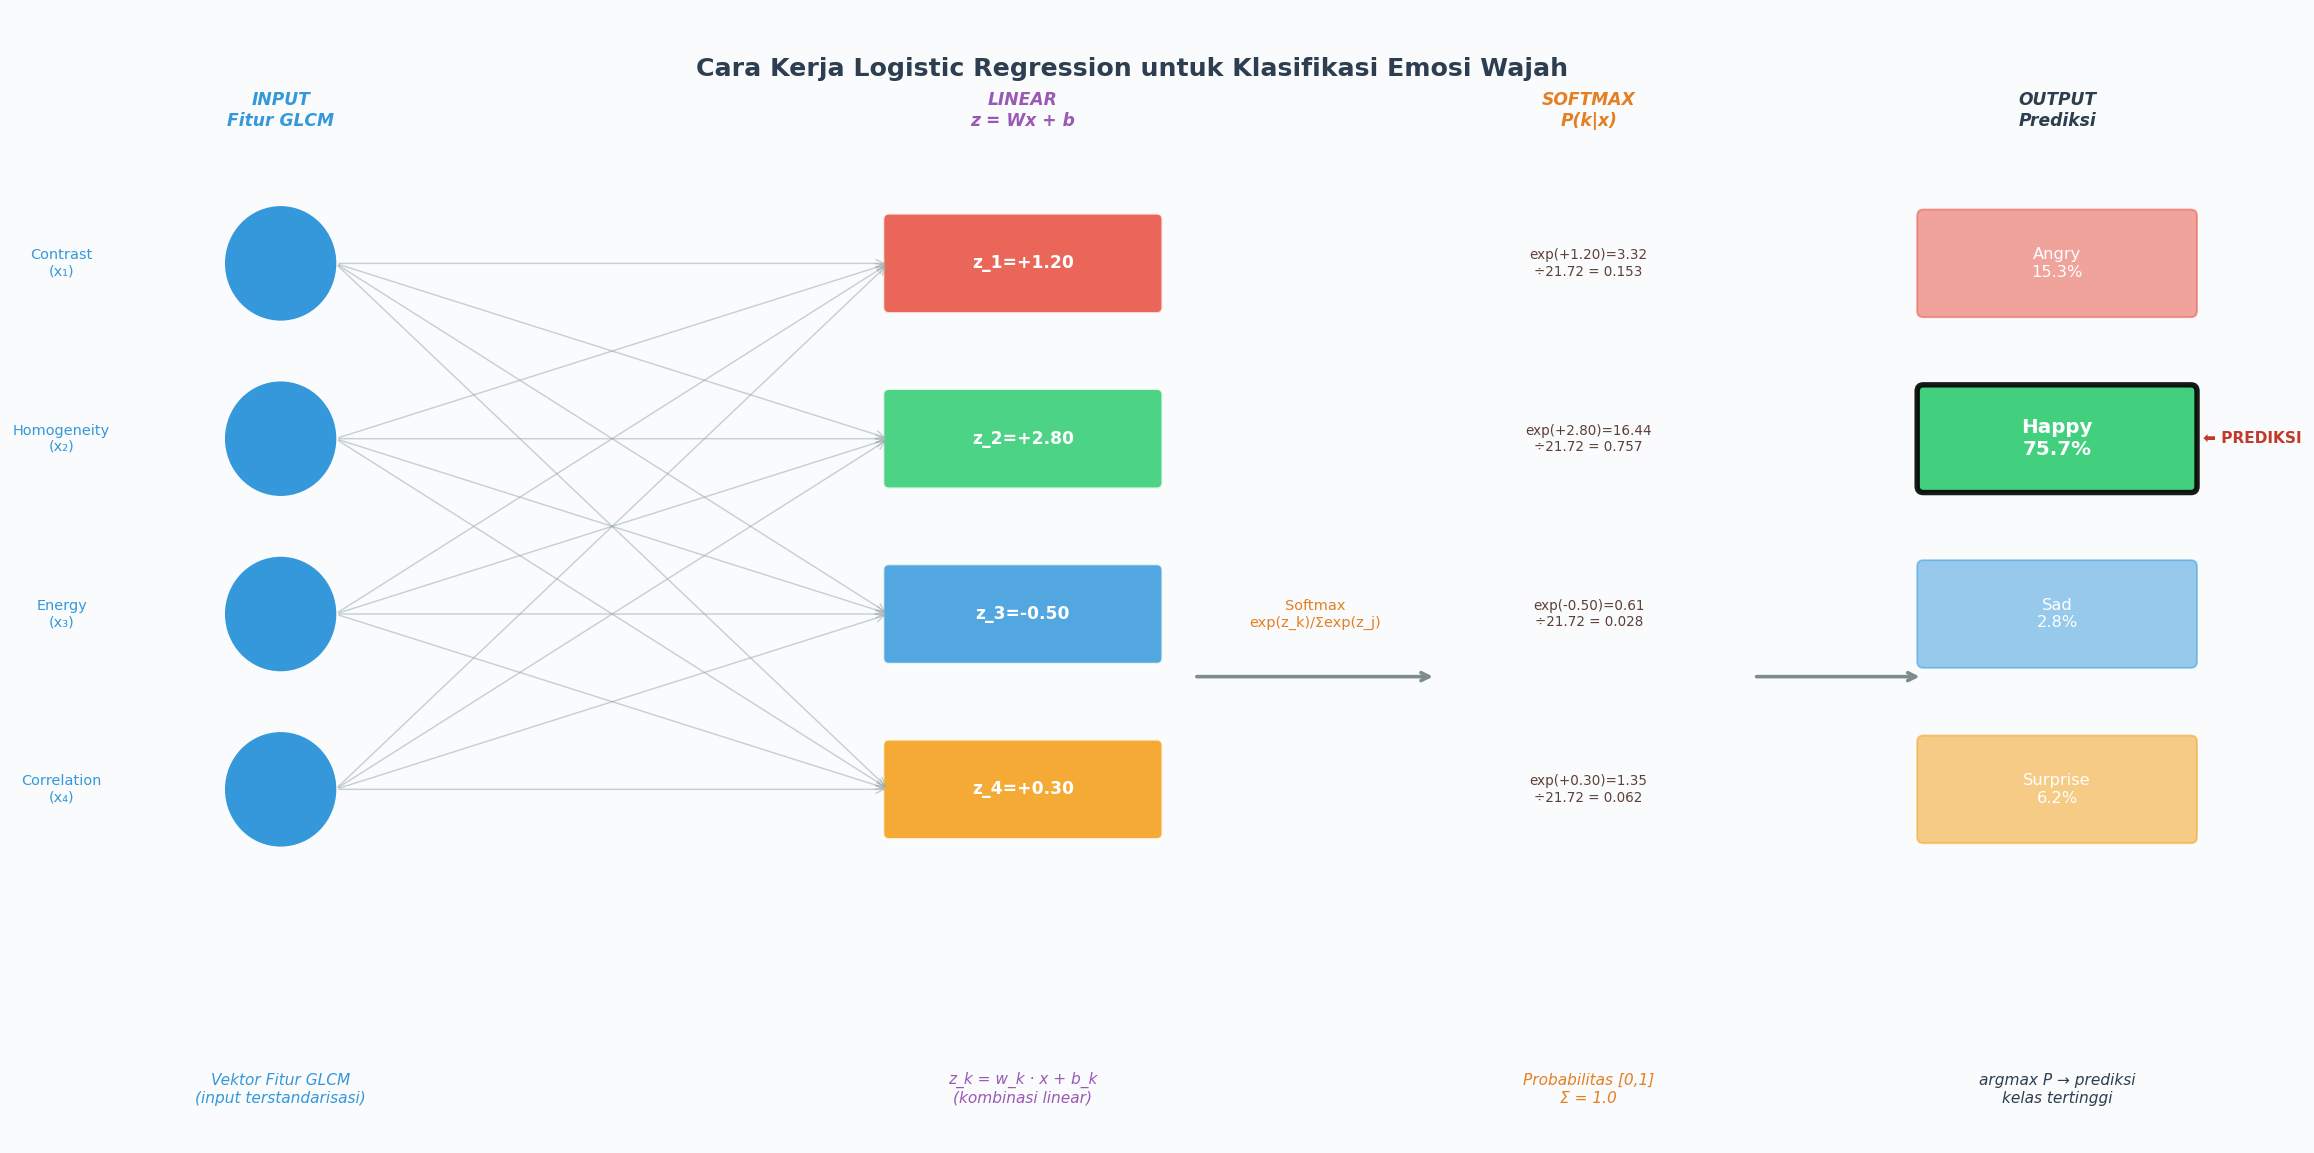

💾 Disimpan: outputs\figures\09_logistic_regression_diagram.png


In [22]:
# ================================================================
#  CELL 3.0 — Visualisasi Konsep Logistic Regression
# ================================================================
# Diagram visual cara kerja LR: input → linear → softmax → prediksi

fig = plt.figure(figsize=(18, 9))
fig.patch.set_facecolor('#fafbfc')
ax = fig.add_subplot(111)
ax.set_xlim(0, 18); ax.set_ylim(0, 9)
ax.axis('off')
ax.set_facecolor('#fafbfc')

# ── Judul ──
ax.text(9, 8.5, 'Cara Kerja Logistic Regression untuk Klasifikasi Emosi Wajah',
        ha='center', fontsize=14, fontweight='bold', color='#2c3e50')

# ── Warna layer ──
C_INPUT   = '#3498db'   # Biru: input
C_LINEAR  = '#9b59b6'   # Ungu: layer linear
C_SOFTMAX = '#e67e22'   # Oranye: softmax
C_OUTPUT  = COLORS      # Warna kelas

feat_names = ['Contrast\n(x₁)', 'Homogeneity\n(x₂)', 'Energy\n(x₃)', 'Correlation\n(x₄)']
class_names_short = ['Angry', 'Happy', 'Sad', 'Surprise']

# ── Layer Input ──
for i, (fn, fv) in enumerate(zip(feat_names, [0.42, 0.71, 0.08, 0.89])):
    y_pos = 7 - i * 1.4
    circ = plt.Circle((2, y_pos), 0.45, color=C_INPUT, zorder=5)
    ax.add_patch(circ)
    ax.text(2, y_pos, f'{fv:.2f}', ha='center', va='center',
            fontsize=9, color='white', fontweight='bold')
    ax.text(0.2, y_pos, fn, ha='center', va='center', fontsize=8, color=C_INPUT)

ax.text(2, 0.3, 'Vektor Fitur GLCM\n(input terstandarisasi)', ha='center',
        fontsize=8.5, color=C_INPUT, style='italic')

# ── Layer Linear z = Wx + b ──
z_examples = [1.2, 2.8, -0.5, 0.3]
for k, (cls, col, zv) in enumerate(zip(class_names_short, C_OUTPUT, z_examples)):
    y_pos = 7 - k * 1.4
    # Koneksi dari semua input ke z_k
    for i in range(4):
        y_in = 7 - i * 1.4
        ax.annotate('', xy=(7, y_pos), xytext=(2.45, y_in),
                    arrowprops=dict(arrowstyle='->', color='#95a5a6',
                                    lw=0.8, alpha=0.5))
    rect = mpatches.FancyBboxPatch((7, y_pos-0.35), 2.2, 0.7,
                                    boxstyle='round,pad=0.05',
                                    facecolor=col, edgecolor='white',
                                    linewidth=1.5, alpha=0.85)
    ax.add_patch(rect)
    ax.text(8.1, y_pos, f'z_{k+1}={zv:+.2f}', ha='center', va='center',
            fontsize=9.5, color='white', fontweight='bold')

ax.text(8.1, 0.3, 'z_k = w_k · x + b_k\n(kombinasi linear)', ha='center',
        fontsize=8.5, color=C_LINEAR, style='italic')

# ── Panah ke Softmax ──
ax.annotate('', xy=(11.5, 3.7), xytext=(9.5, 3.7),
            arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=2))
ax.text(10.5, 4.1, 'Softmax\nexp(z_k)/Σexp(z_j)', ha='center', fontsize=8, color=C_SOFTMAX)

# ── Softmax box ──
# softmax_rect = mpatches.FancyBboxPatch((11.5, 1.2), 2.5, 5.2,
#                                         boxstyle='round,pad=0.1',
#                                         facecolor='#fff3e0', edgecolor=C_SOFTMAX,
#                                         linewidth=2)
# ax.add_patch(softmax_rect)

# Kalkulasi softmax
z_arr = np.array(z_examples)
exp_z = np.exp(z_arr)
probs = exp_z / exp_z.sum()
for k, (cls, col, zv, pv) in enumerate(zip(class_names_short, C_OUTPUT, z_examples, probs)):
    y_pos = 7 - k * 1.4
    ax.text(12.75, y_pos,
            f'exp({zv:+.2f})={np.exp(zv):.2f}\n÷{exp_z.sum():.2f} = {pv:.3f}',
            ha='center', va='center', fontsize=7.5, color='#5d4037')

ax.text(12.75, 0.3, 'Probabilitas [0,1]\nΣ = 1.0', ha='center',
        fontsize=8.5, color=C_SOFTMAX, style='italic')

# ── Output prediksi ──
ax.annotate('', xy=(15.5, 3.7), xytext=(14.1, 3.7),
            arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=2))

for k, (cls, col, pv) in enumerate(zip(class_names_short, C_OUTPUT, probs)):
    y_pos = 7 - k * 1.4
    is_pred = (k == np.argmax(probs))
    lw   = 3 if is_pred else 1
    fcsz = 11 if is_pred else 9
    rect2 = mpatches.FancyBboxPatch((15.5, y_pos-0.38), 2.2, 0.76,
                                     boxstyle='round,pad=0.05',
                                     facecolor=col, edgecolor='black' if is_pred else col,
                                     linewidth=lw, alpha=0.9 if is_pred else 0.5)
    ax.add_patch(rect2)
    ax.text(16.6, y_pos, f'{cls}\n{pv:.1%}', ha='center', va='center',
            fontsize=fcsz, color='white', fontweight='bold' if is_pred else 'normal')
    if is_pred:
        ax.text(17.8, y_pos, '⬅ PREDIKSI', va='center', fontsize=8.5,
                color='#c0392b', fontweight='bold')

ax.text(16.6, 0.3, 'argmax P → prediksi\nkelas tertinggi', ha='center',
        fontsize=8.5, color='#2c3e50', style='italic')

# ── Label layer ──
for x_pos, lbl, col in [
    (2, 'INPUT\nFitur GLCM', C_INPUT),
    (8.1, 'LINEAR\nz = Wx + b', C_LINEAR),
    (12.75, 'SOFTMAX\nP(k|x)', C_SOFTMAX),
    (16.6, 'OUTPUT\nPrediksi', '#2c3e50'),
]:
    ax.text(x_pos, 8.1, lbl, ha='center', fontsize=9.5, fontweight='bold',
            color=col, style='italic')

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '09_logistic_regression_diagram.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Disimpan:", OUT_FIGS / '09_logistic_regression_diagram.png')


In [23]:
# ================================================================
#  CELL 3.1 — Ekstraksi Fitur Massal + StandardScaler + Cache
# ================================================================
# Mengapa StandardScaler WAJIB?
# Logistic Regression sensitif terhadap skala fitur.
# Contrast ≈ 0.01–5.0, Correlation ≈ 0–1 → gradient sangat tidak seimbang.
# StandardScaler: z = (x - μ) / σ  →  mean=0, std=1 untuk setiap fitur.

le = LabelEncoder()
y_train = le.fit_transform(train_labels)
y_test  = le.transform(test_labels)

print("🔢 Pemetaan Label:")
for cls, lbl in zip(le.classes_, le.transform(le.classes_)):
    print(f"   {cls:10s} → {lbl}")

scenarios = {}

for level in LEVELS_TO_TEST:
    for agg in ['mean', 'concat']:
        key       = f"{level}-{agg}"
        feat_path = OUT_FEAT / f'features_{key}.pkl'

        if feat_path.exists():
            with open(feat_path, 'rb') as f:
                scenarios[key] = pickle.load(f)
            print(f"  📦 Cache: {key} → shape {scenarios[key]['X_train'].shape}")
            continue

        print(f"  ⚙️  Ekstraksi {key}...", end=' ')
        X_tr_raw = np.array([
            extract_glcm_features(img, level, aggregation=agg)[0]
            for img in train_norm
        ], dtype=np.float32)
        X_te_raw = np.array([
            extract_glcm_features(img, level, aggregation=agg)[0]
            for img in test_norm
        ], dtype=np.float32)

        scaler  = StandardScaler()
        X_train_s = scaler.fit_transform(X_tr_raw)
        X_test_s  = scaler.transform(X_te_raw)

        data = {'X_train': X_train_s, 'X_test': X_test_s,
                'scaler': scaler, 'n_feat': X_train_s.shape[1]}
        scenarios[key] = data
        with open(feat_path, 'wb') as f:
            pickle.dump(data, f)
        print(f"✅ {X_train_s.shape}")

print("\n🎯 Semua fitur siap!")


🔢 Pemetaan Label:
   angry      → 0
   happy      → 1
   sad        → 2
   surprise   → 3
  📦 Cache: 8-mean → shape (12400, 4)
  📦 Cache: 8-concat → shape (12400, 16)
  📦 Cache: 16-mean → shape (12400, 4)
  📦 Cache: 16-concat → shape (12400, 16)
  📦 Cache: 32-mean → shape (12400, 4)
  📦 Cache: 32-concat → shape (12400, 16)

🎯 Semua fitur siap!


In [24]:
# ================================================================
#  CELL 3.2 — Training Logistic Regression (6 Skenario)
# ================================================================
# Skenario:
#   Level 8, 16, 32  ×  Agregasi Mean, Concat  = 6 kombinasi

results = {}
print(f"{'Skenario':<20} {'Dim':>5} {'Acc Train':>11} {'Acc Test':>10}")
print("-" * 50)

for key, data in scenarios.items():
    model_path = OUT_MODELS / f'model_{key}.pkl'

    if model_path.exists():
        with open(model_path, 'rb') as f:
            model = pickle.load(f)
    else:
        model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
        model.fit(data['X_train'], y_train)
        with open(model_path, 'wb') as f:
            pickle.dump(model, f)

    y_pred_tr = model.predict(data['X_train'])
    y_pred_te = model.predict(data['X_test'])
    acc_tr    = accuracy_score(y_train, y_pred_tr)
    acc_te    = accuracy_score(y_test,  y_pred_te)

    results[key] = {
        'model': model, 'y_pred_test': y_pred_te,
        'acc_train': acc_tr, 'acc_test': acc_te
    }
    print(f"{key:<20} {data['n_feat']:>5} {acc_tr:>11.4f} {acc_te:>10.4f}")

best_key = max(results, key=lambda k: results[k]['acc_test'])
best_acc = results[best_key]['acc_test']
best_model  = results[best_key]['model']
X_tr_best   = scenarios[best_key]['X_train']
X_te_best   = scenarios[best_key]['X_test']

print("-" * 50)
print(f"\n🏆 Terbaik: '{best_key}' — Akurasi Test = {best_acc:.4f} ({best_acc:.2%})")


Skenario               Dim   Acc Train   Acc Test
--------------------------------------------------
8-mean                   4      0.3219     0.3152
8-concat                16      0.3687     0.3823
16-mean                  4      0.3143     0.3100
16-concat               16      0.3652     0.3765
32-mean                  4      0.3142     0.3116
32-concat               16      0.3603     0.3765
--------------------------------------------------

🏆 Terbaik: '8-concat' — Akurasi Test = 0.3823 (38.23%)


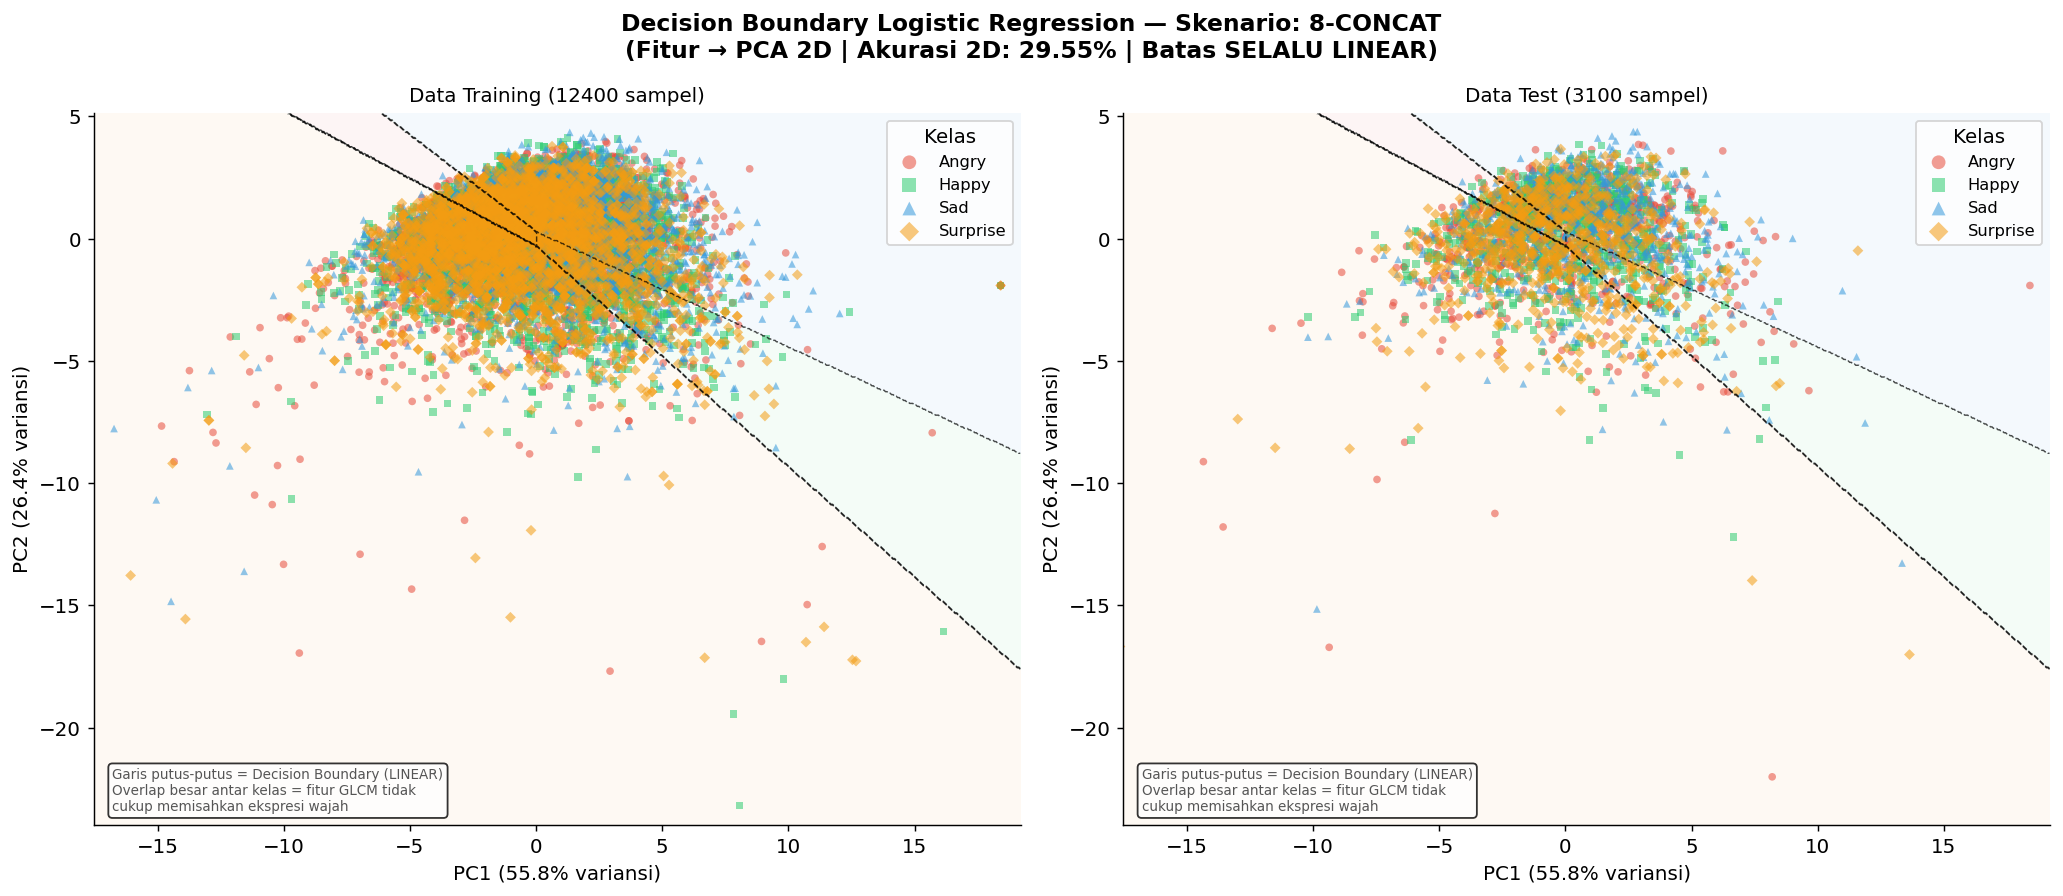

💾 Disimpan: outputs\figures\10_decision_boundary.png


In [25]:
# ================================================================
#  CELL 3.3 — Decision Boundary (PCA 2D) + Gradien Softmax
# ================================================================
# PCA proyeksikan fitur ke 2D, lalu plot garis batas keputusan.
# Ini menunjukkan bahwa LR hanya bisa membuat batas LINEAR.

pca_2d  = PCA(n_components=2, random_state=RANDOM_STATE)
X_tr_2d = pca_2d.fit_transform(X_tr_best)
X_te_2d = pca_2d.transform(X_te_best)

lr_2d   = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_2d.fit(X_tr_2d, y_train)
acc_2d  = accuracy_score(y_test, lr_2d.predict(X_te_2d))

margin = 0.8
x_min, x_max = X_tr_2d[:,0].min()-margin, X_tr_2d[:,0].max()+margin
y_min, y_max = X_tr_2d[:,1].min()-margin, X_tr_2d[:,1].max()+margin
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.06),
                     np.arange(y_min, y_max, 0.06))
Z = lr_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

region_colors = ['#fadbd8', '#d5f5e3', '#d6eaf8', '#fdebd0']
cmap_region   = LinearSegmentedColormap.from_list('reg', region_colors, N=4)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    f'Decision Boundary Logistic Regression — Skenario: {best_key.upper()}\n'
    f'(Fitur → PCA 2D | Akurasi 2D: {acc_2d:.2%} | Batas SELALU LINEAR)',
    fontsize=13, fontweight='bold'
)

markers = ['o', 's', '^', 'D']
for ax, (X_2d, y_true, title) in zip(axes, [
    (X_tr_2d, y_train, f'Data Training ({len(y_train)} sampel)'),
    (X_te_2d, y_test,  f'Data Test ({len(y_test)} sampel)')
]):
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=cmap_region,
                levels=[-0.5, 0.5, 1.5, 2.5, 3.5])
    ax.contour(xx, yy, Z, colors='black', linewidths=0.8,
               linestyles='--', levels=[-0.5, 0.5, 1.5, 2.5, 3.5], alpha=0.7)

    for cls_idx, (cls, color, marker) in enumerate(zip(le.classes_, COLORS, markers)):
        mask = y_true == cls_idx
        ax.scatter(X_2d[mask,0], X_2d[mask,1], c=color, marker=marker,
                   s=18, alpha=0.55, label=cls.capitalize(), edgecolors='none')

    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variansi)')
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variansi)')
    ax.set_title(title, fontsize=11)
    ax.legend(title='Kelas', fontsize=9, markerscale=1.8)
    ax.text(0.02, 0.02,
            'Garis putus-putus = Decision Boundary (LINEAR)\n'
            'Overlap besar antar kelas = fitur GLCM tidak\n'
            'cukup memisahkan ekspresi wajah',
            transform=ax.transAxes, fontsize=7.5, color='#555',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '10_decision_boundary.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Disimpan:", OUT_FIGS / '10_decision_boundary.png')


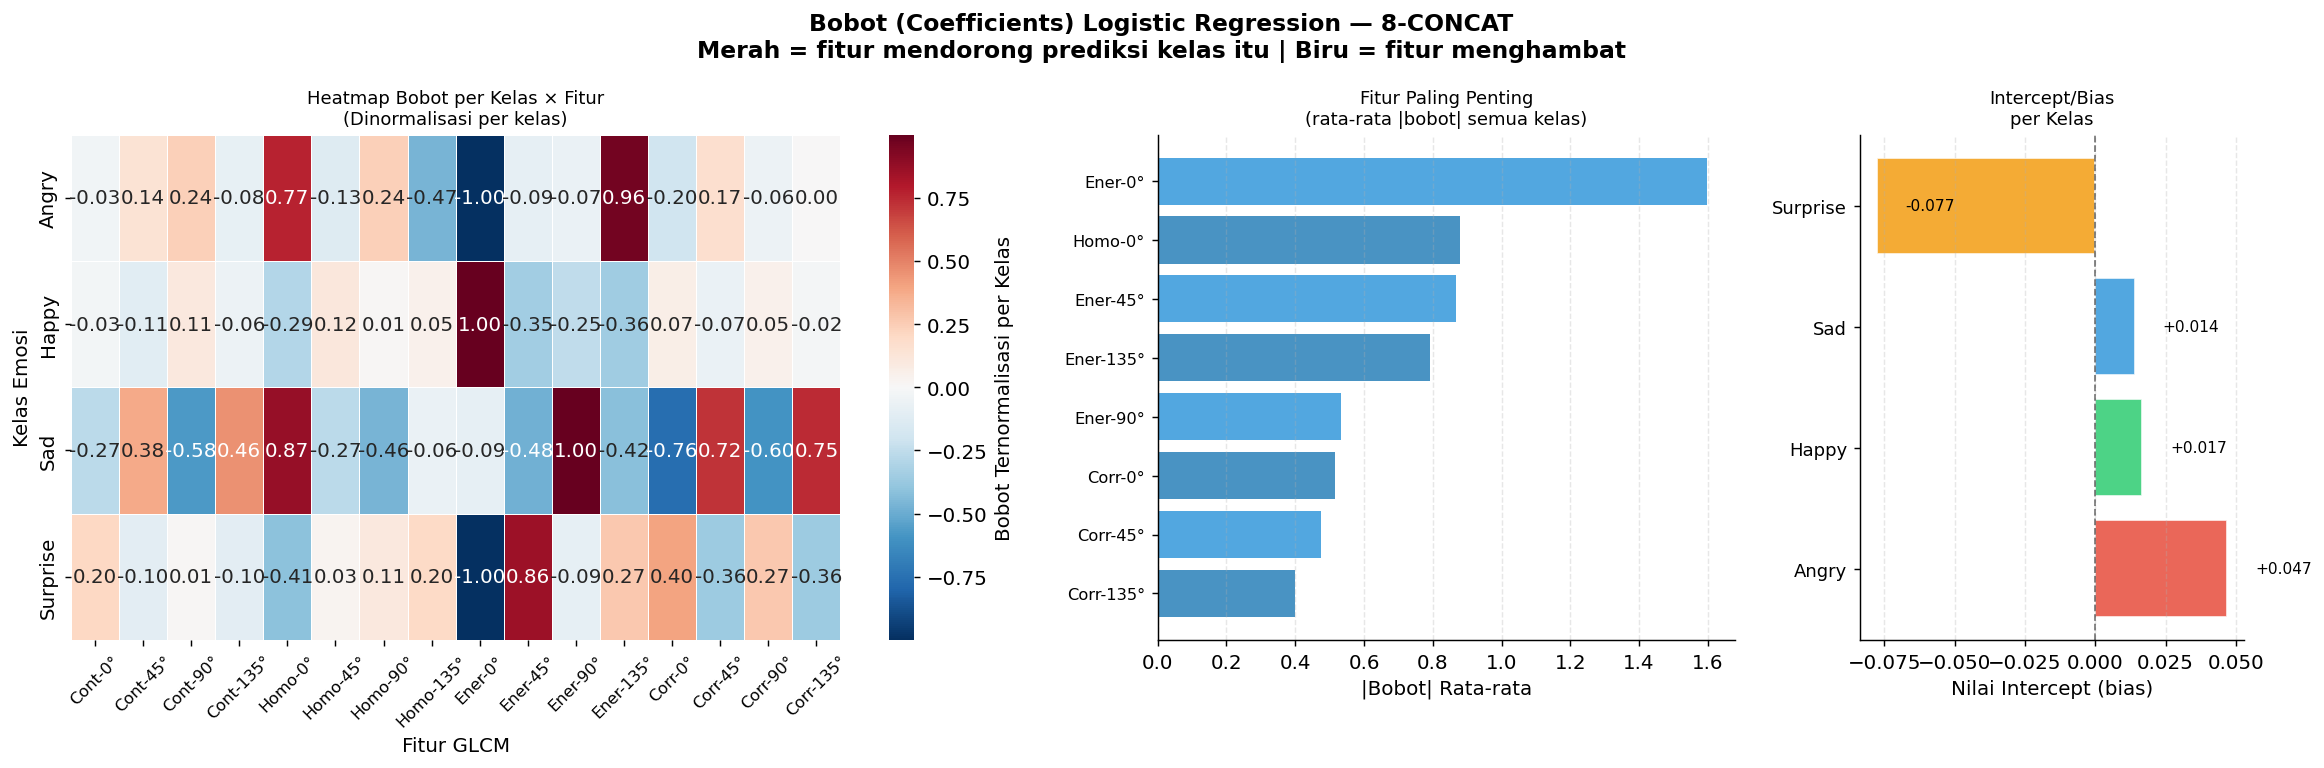

💾 Disimpan: outputs\figures\11_model_coefficients.png


In [26]:
# ================================================================
#  CELL 3.4 — Heatmap Bobot Model (Coefficient Matrix)
# ================================================================
# model.coef_ shape: (n_classes, n_features)
# Setiap baris = vektor bobot satu kelas terhadap semua fitur.
# Bobot positif besar → fitur mendorong prediksi kelas tsb.
# Bobot negatif besar → fitur menghambat prediksi kelas tsb.

coef_matrix = best_model.coef_    # (4, n_feat)
level_k, agg_k = best_key.split('-')

if agg_k == 'mean':
    feat_names = [p.capitalize() for p in GLCM_PROPS]
else:
    feat_names = [f'{p[:4].capitalize()}-{a}' for p in GLCM_PROPS for a in ANGLE_LABELS]

class_names_cap = [c.capitalize() for c in le.classes_]

fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                          gridspec_kw={'width_ratios': [2.5, 1.5, 1]})
fig.suptitle(
    f'Bobot (Coefficients) Logistic Regression — {best_key.upper()}\n'
    'Merah = fitur mendorong prediksi kelas itu | Biru = fitur menghambat',
    fontsize=13, fontweight='bold'
)

# ── Panel 1: Heatmap bobot per kelas ──
ax = axes[0]
coef_norm = coef_matrix / (np.abs(coef_matrix).max(axis=1, keepdims=True) + 1e-8)
sns.heatmap(
    coef_norm, ax=ax, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    xticklabels=feat_names, yticklabels=class_names_cap,
    linewidths=0.4, cbar_kws={'label': 'Bobot Ternormalisasi per Kelas'}
)
ax.set_title('Heatmap Bobot per Kelas × Fitur\n(Dinormalisasi per kelas)', fontsize=10)
ax.set_xlabel('Fitur GLCM'); ax.set_ylabel('Kelas Emosi')
ax.tick_params(axis='x', rotation=45, labelsize=9)

# ── Panel 2: Bar bobot absolut (fitur penting) ──
ax = axes[1]
abs_mean_coef = np.abs(coef_matrix).mean(axis=0)
sorted_idx    = np.argsort(abs_mean_coef)[::-1]
top_n = min(8, len(abs_mean_coef))
colors_bar = ['#3498db' if i%2==0 else '#2980b9' for i in range(top_n)]
ax.barh(range(top_n), abs_mean_coef[sorted_idx[:top_n]],
        color=colors_bar, alpha=0.85)
ax.set_yticks(range(top_n))
ax.set_yticklabels([feat_names[i] for i in sorted_idx[:top_n]], fontsize=9)
ax.set_xlabel('|Bobot| Rata-rata')
ax.set_title('Fitur Paling Penting\n(rata-rata |bobot| semua kelas)', fontsize=10)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, ls='--')

# ── Panel 3: Intercept (bias) per kelas ──
ax = axes[2]
intercepts = best_model.intercept_
bars = ax.barh(range(len(le.classes_)), intercepts,
               color=COLORS, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(le.classes_)))
ax.set_yticklabels(class_names_cap, fontsize=10)
ax.set_xlabel('Nilai Intercept (bias)')
ax.set_title('Intercept/Bias\nper Kelas', fontsize=10)
ax.axvline(0, color='black', lw=1, ls='--', alpha=0.5)
ax.grid(axis='x', alpha=0.3, ls='--')
for bar, val in zip(bars, intercepts):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '11_model_coefficients.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Disimpan:", OUT_FIGS / '11_model_coefficients.png')


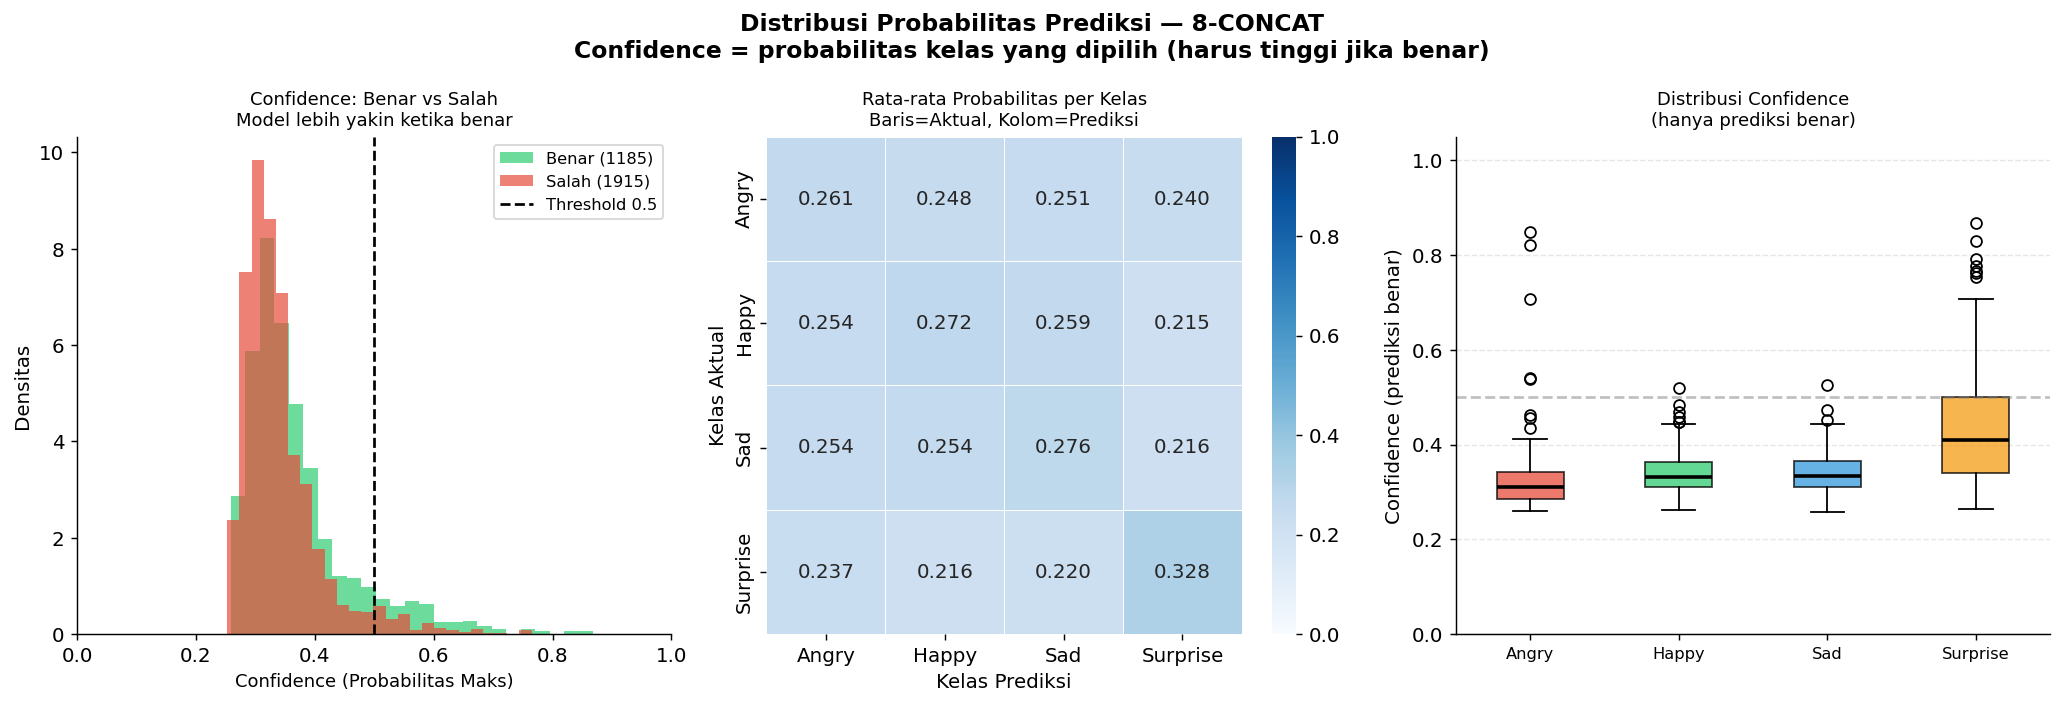

💾 Disimpan: outputs\figures\12_prediction_probability.png


In [27]:
# ================================================================
#  CELL 3.5 — Distribusi Probabilitas Prediksi
# ================================================================
# predict_proba() → probabilitas per kelas untuk setiap sampel.
# Model yang yakin (confidence tinggi) → prob satu kelas dominan.
# Model yang ragu (prob merata) → sering salah prediksi.

proba_all  = best_model.predict_proba(X_te_best)
is_correct = (results[best_key]['y_pred_test'] == y_test)
max_proba  = proba_all.max(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle(
    f'Distribusi Probabilitas Prediksi — {best_key.upper()}\n'
    'Confidence = probabilitas kelas yang dipilih (harus tinggi jika benar)',
    fontsize=13, fontweight='bold'
)

# ── Panel 1: Distribusi confidence benar vs salah ──
ax = axes[0]
ax.hist(max_proba[is_correct],  bins=25, color='#2ecc71', alpha=0.7,
        label=f'Benar ({is_correct.sum()})', density=True)
ax.hist(max_proba[~is_correct], bins=25, color='#e74c3c', alpha=0.7,
        label=f'Salah ({(~is_correct).sum()})', density=True)
ax.axvline(0.5, color='black', lw=1.5, ls='--', label='Threshold 0.5')
ax.set_xlabel('Confidence (Probabilitas Maks)', fontsize=10)
ax.set_ylabel('Densitas'); ax.set_xlim(0, 1)
ax.set_title('Confidence: Benar vs Salah\nModel lebih yakin ketika benar', fontsize=10)
ax.legend(fontsize=9)

# ── Panel 2: Heatmap rata-rata prob per kelas asli ──
ax = axes[1]
avg_prob = np.zeros((len(le.classes_), len(le.classes_)))
for true_idx in range(len(le.classes_)):
    mask = y_test == true_idx
    if mask.sum() > 0:
        avg_prob[true_idx] = proba_all[mask].mean(axis=0)
sns.heatmap(avg_prob, ax=ax, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=class_names_cap, yticklabels=class_names_cap,
            vmin=0, vmax=1, linewidths=0.5)
ax.set_title('Rata-rata Probabilitas per Kelas\nBaris=Aktual, Kolom=Prediksi', fontsize=10)
ax.set_xlabel('Kelas Prediksi'); ax.set_ylabel('Kelas Aktual')

# ── Panel 3: Boxplot confidence per kelas (hanya prediksi benar) ──
ax = axes[2]
conf_per_cls = [max_proba[(y_test == k) & is_correct]
                for k in range(len(le.classes_))]
bp = ax.boxplot(conf_per_cls, patch_artist=True,
                medianprops={'color': 'black', 'lw': 2})
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_xticklabels(class_names_cap, fontsize=9)
ax.set_ylabel('Confidence (prediksi benar)')
ax.set_ylim(0, 1.05); ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
ax.set_title('Distribusi Confidence\n(hanya prediksi benar)', fontsize=10)
ax.grid(axis='y', alpha=0.3, ls='--')

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '12_prediction_probability.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Disimpan:", OUT_FIGS / '12_prediction_probability.png')


---
# BAGIAN 4 — Evaluasi Lengkap

In [28]:
# ================================================================
#  CELL 4.1 — Classification Report
# ================================================================
y_pred_best = results[best_key]['y_pred_test']

print(f"{'='*62}")
print(f"  📊 CLASSIFICATION REPORT — Skenario: {best_key.upper()}")
print(f"{'='*62}")
print(classification_report(y_test, y_pred_best, target_names=class_names_cap))


  📊 CLASSIFICATION REPORT — Skenario: 8-CONCAT
              precision    recall  f1-score   support

       Angry       0.36      0.20      0.25       775
       Happy       0.36      0.36      0.36       775
         Sad       0.36      0.40      0.38       775
    Surprise       0.43      0.57      0.49       775

    accuracy                           0.38      3100
   macro avg       0.38      0.38      0.37      3100
weighted avg       0.38      0.38      0.37      3100



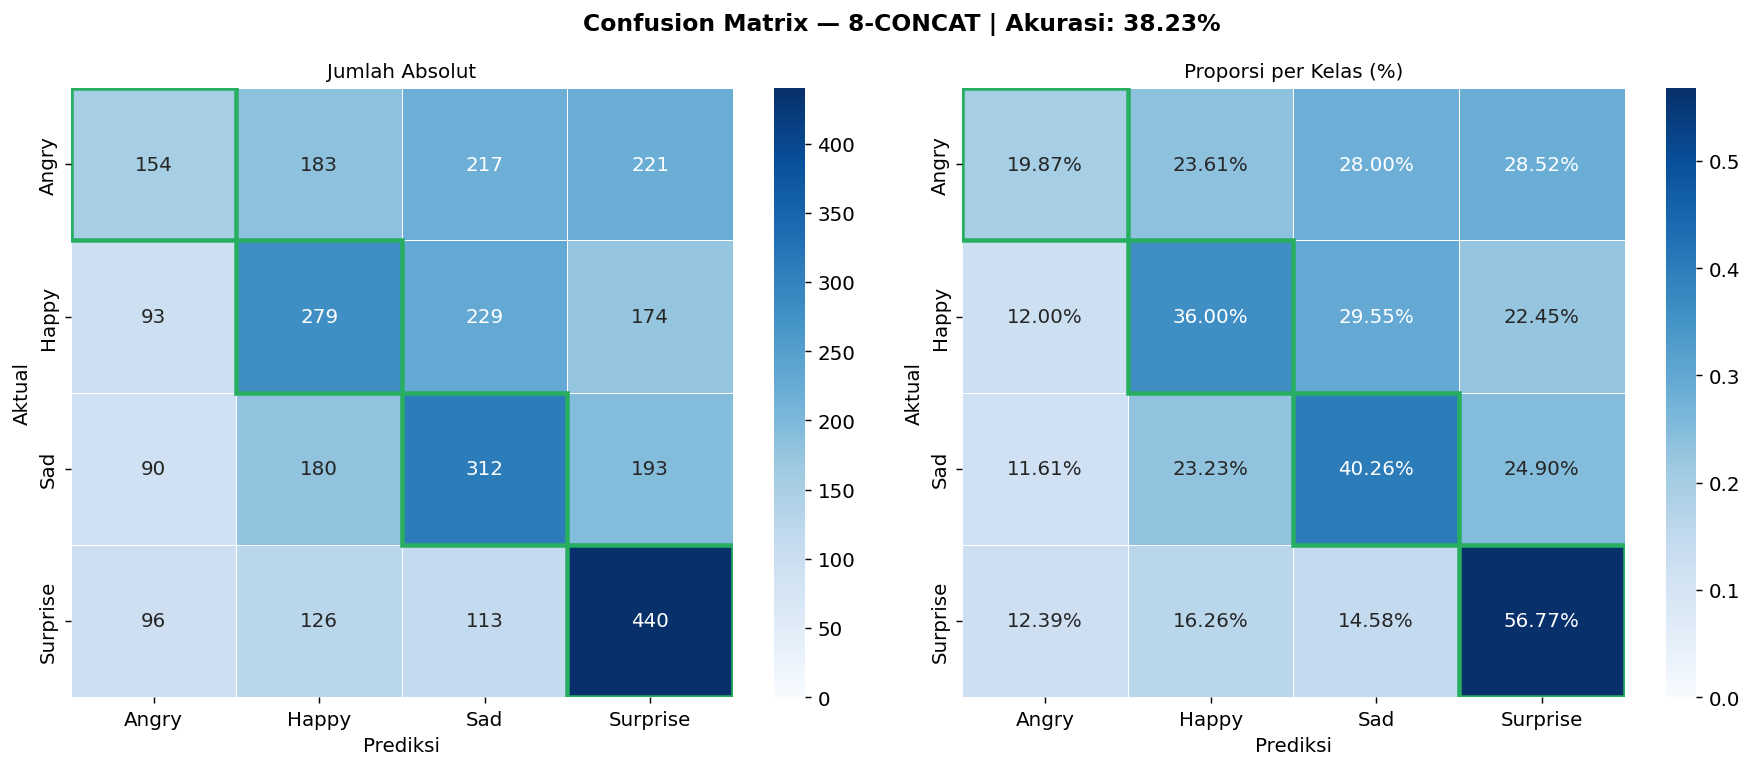

💾 Disimpan: outputs\figures\13_confusion_matrix.png


In [29]:
# ================================================================
#  CELL 4.2 — Confusion Matrix (Absolut + Normalized)
# ================================================================
cm      = confusion_matrix(y_test, y_pred_best)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Confusion Matrix — {best_key.upper()} | Akurasi: {best_acc:.2%}',
             fontsize=13, fontweight='bold')

for ax, (data, fmt, title, cmap) in zip(axes, [
    (cm,      'd',    'Jumlah Absolut',         'Blues'),
    (cm_norm, '.2%',  'Proporsi per Kelas (%)', 'Blues'),
]):
    sns.heatmap(data, ax=ax, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=class_names_cap, yticklabels=class_names_cap,
                linewidths=0.5, linecolor='white', vmin=0)
    # Highlight diagonal
    for i in range(len(le.classes_)):
        ax.add_patch(mpatches.Rectangle((i, i), 1, 1, fill=False,
                                         edgecolor='#27ae60', lw=2.5))
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Prediksi', fontsize=11); ax.set_ylabel('Aktual', fontsize=11)

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '13_confusion_matrix.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Disimpan:", OUT_FIGS / '13_confusion_matrix.png')


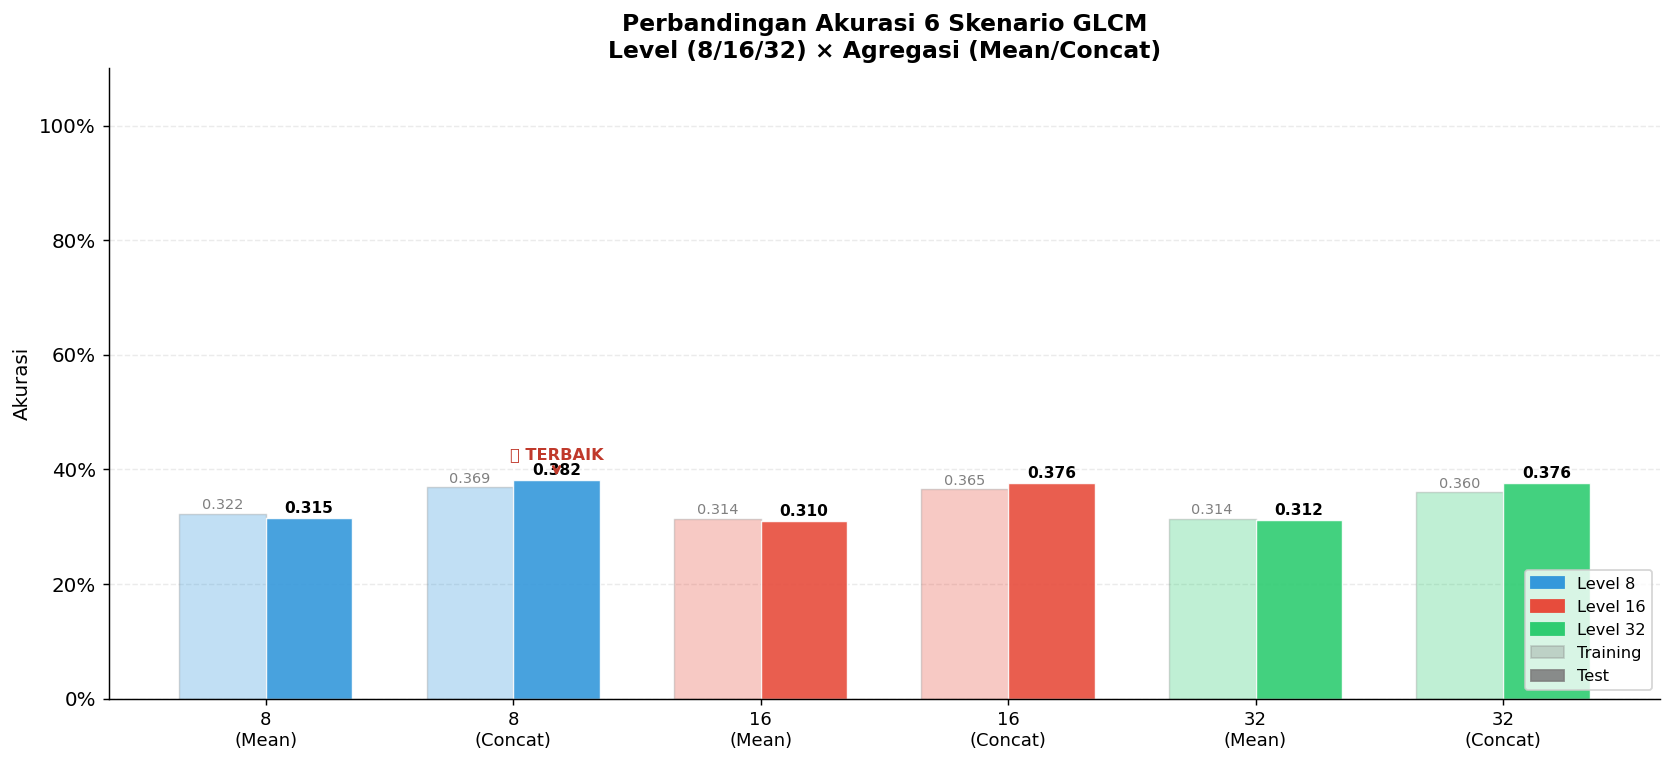

💾 Disimpan: outputs\figures\14_accuracy_comparison.png


In [30]:
# ================================================================
#  CELL 4.3 — Perbandingan 6 Skenario
# ================================================================
keys      = list(results.keys())
acc_train = [results[k]['acc_train'] for k in keys]
acc_test  = [results[k]['acc_test']  for k in keys]
x = np.arange(len(keys)); w = 0.35

level_col_map = {'8': '#3498db', '16': '#e74c3c', '32': '#2ecc71'}
bar_colors = [level_col_map[k.split('-')[0]] for k in keys]

fig, ax = plt.subplots(figsize=(13, 6))
btr = ax.bar(x-w/2, acc_train, w, color=bar_colors, alpha=0.3,
             edgecolor='gray', lw=0.8, label='Training')
bte = ax.bar(x+w/2, acc_test,  w, color=bar_colors, alpha=0.9,
             edgecolor='white', lw=0.8, label='Test')

for bar, val in zip(btr, acc_train):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, color='gray')
for bar, val in zip(bte, acc_test):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

best_idx = keys.index(best_key)
ax.annotate('⭐ TERBAIK',
            xy=(x[best_idx]+w/2, acc_test[best_idx]),
            xytext=(x[best_idx]+w/2, acc_test[best_idx]+0.035),
            fontsize=9, ha='center', color='#c0392b', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5))

ax.set_xticks(x)
ax.set_xticklabels(
    [k.replace('-mean','\n(Mean)').replace('-concat','\n(Concat)') for k in keys],
    fontsize=10
)
ax.set_ylabel('Akurasi'); ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_title('Perbandingan Akurasi 6 Skenario GLCM\n'
             'Level (8/16/32) × Agregasi (Mean/Concat)',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.25, ls='--'); ax.set_axisbelow(True)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#3498db', label='Level 8'),
    Patch(color='#e74c3c', label='Level 16'),
    Patch(color='#2ecc71', label='Level 32'),
    Patch(color='gray', alpha=0.3, label='Training'),
    Patch(color='gray', alpha=0.9, label='Test'),
], fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '14_accuracy_comparison.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Disimpan:", OUT_FIGS / '14_accuracy_comparison.png')


⏳ PCA... ✅ Explained var: 82.2%
⏳ t-SNE (non-linear)... ✅


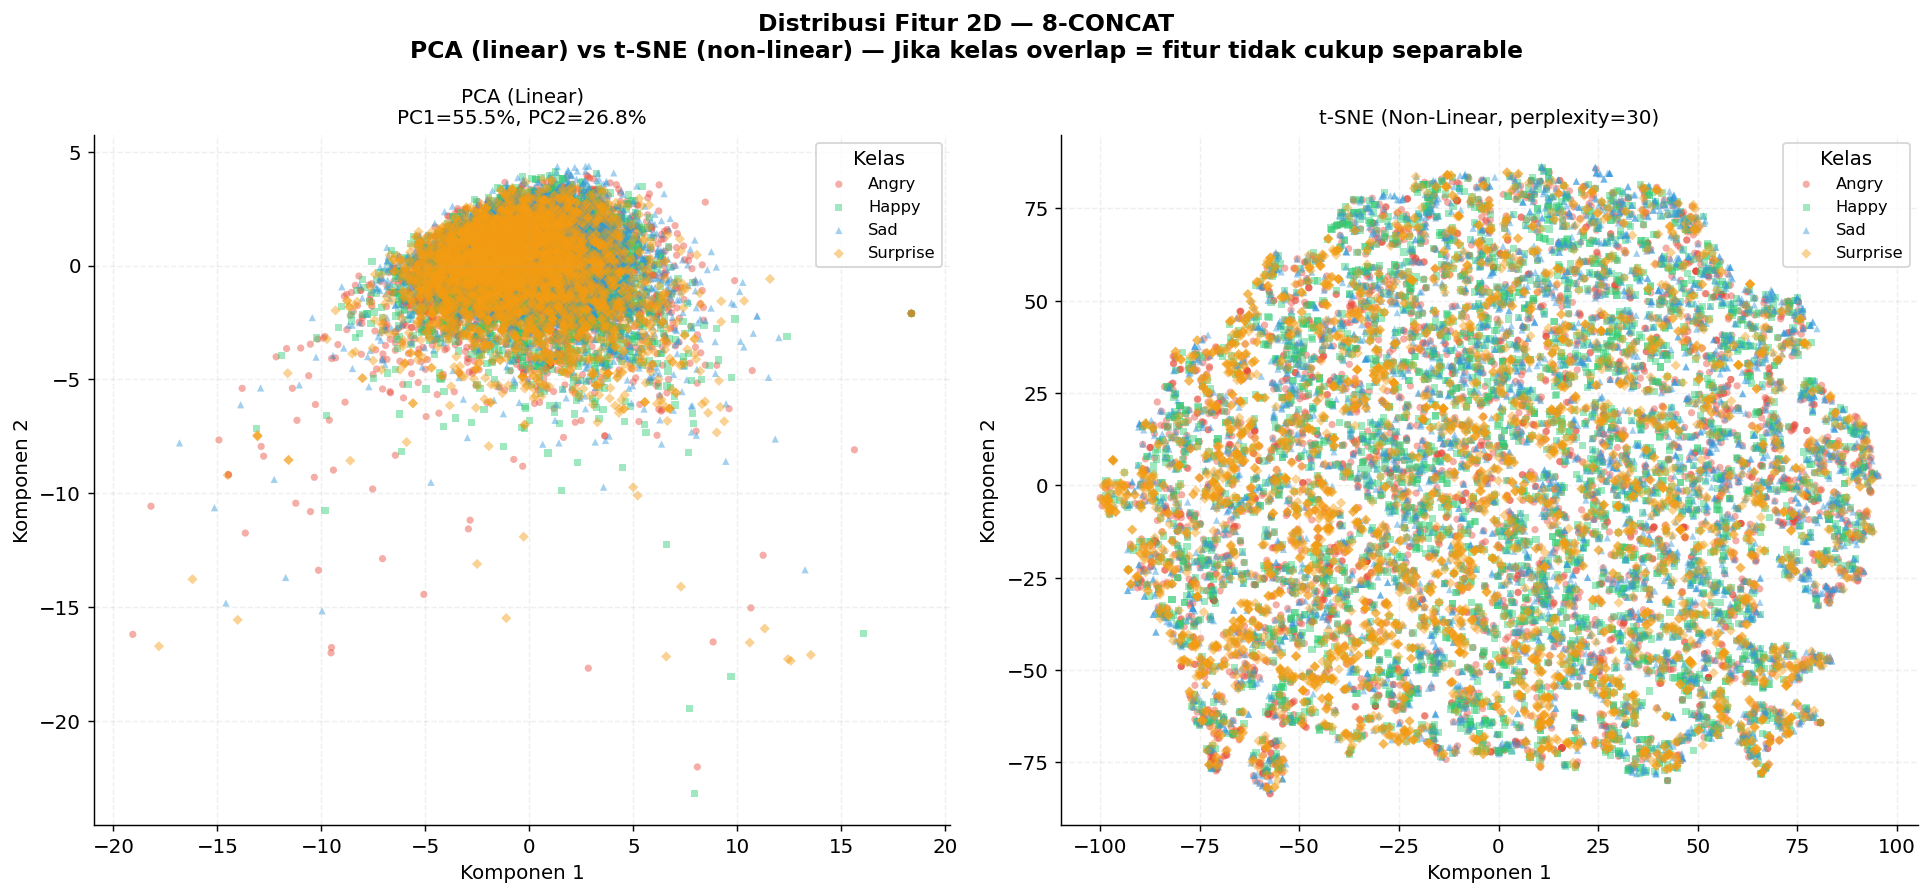

💾 Disimpan: outputs\figures\15_pca_tsne.png


In [31]:
# ================================================================
#  CELL 4.4 — PCA & t-SNE Distribusi Fitur 2D
# ================================================================
X_all = np.vstack([X_tr_best, X_te_best])
y_all = np.concatenate([y_train, y_test])

print("⏳ PCA...", end=' ')
pca_full = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca    = pca_full.fit_transform(X_all)
print(f"✅ Explained var: {pca_full.explained_variance_ratio_.sum():.1%}")

print("⏳ t-SNE (non-linear)...", end=' ')
tsne   = TSNE(n_components=2, perplexity=30, learning_rate='auto', random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_all)
print("✅")

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle(
    f'Distribusi Fitur 2D — {best_key.upper()}\n'
    'PCA (linear) vs t-SNE (non-linear) — Jika kelas overlap = fitur tidak cukup separable',
    fontsize=13, fontweight='bold'
)
markers = ['o', 's', '^', 'D']
for ax, (X_2d, title) in zip(axes, [
    (X_pca,
     f'PCA (Linear)\nPC1={pca_full.explained_variance_ratio_[0]:.1%}, PC2={pca_full.explained_variance_ratio_[1]:.1%}'),
    (X_tsne, 't-SNE (Non-Linear, perplexity=30)')
]):
    for cls_idx, (cls, color, marker) in enumerate(zip(le.classes_, COLORS, markers)):
        mask = y_all == cls_idx
        ax.scatter(X_2d[mask,0], X_2d[mask,1], c=color, marker=marker,
                   label=cls.capitalize(), alpha=0.45, s=16, edgecolors='none')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Komponen 1'); ax.set_ylabel('Komponen 2')
    ax.legend(title='Kelas', fontsize=9)
    ax.grid(True, alpha=0.2, ls='--')

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '15_pca_tsne.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Disimpan:", OUT_FIGS / '15_pca_tsne.png')


Total kesalahan: 1915/3100 (61.8%)


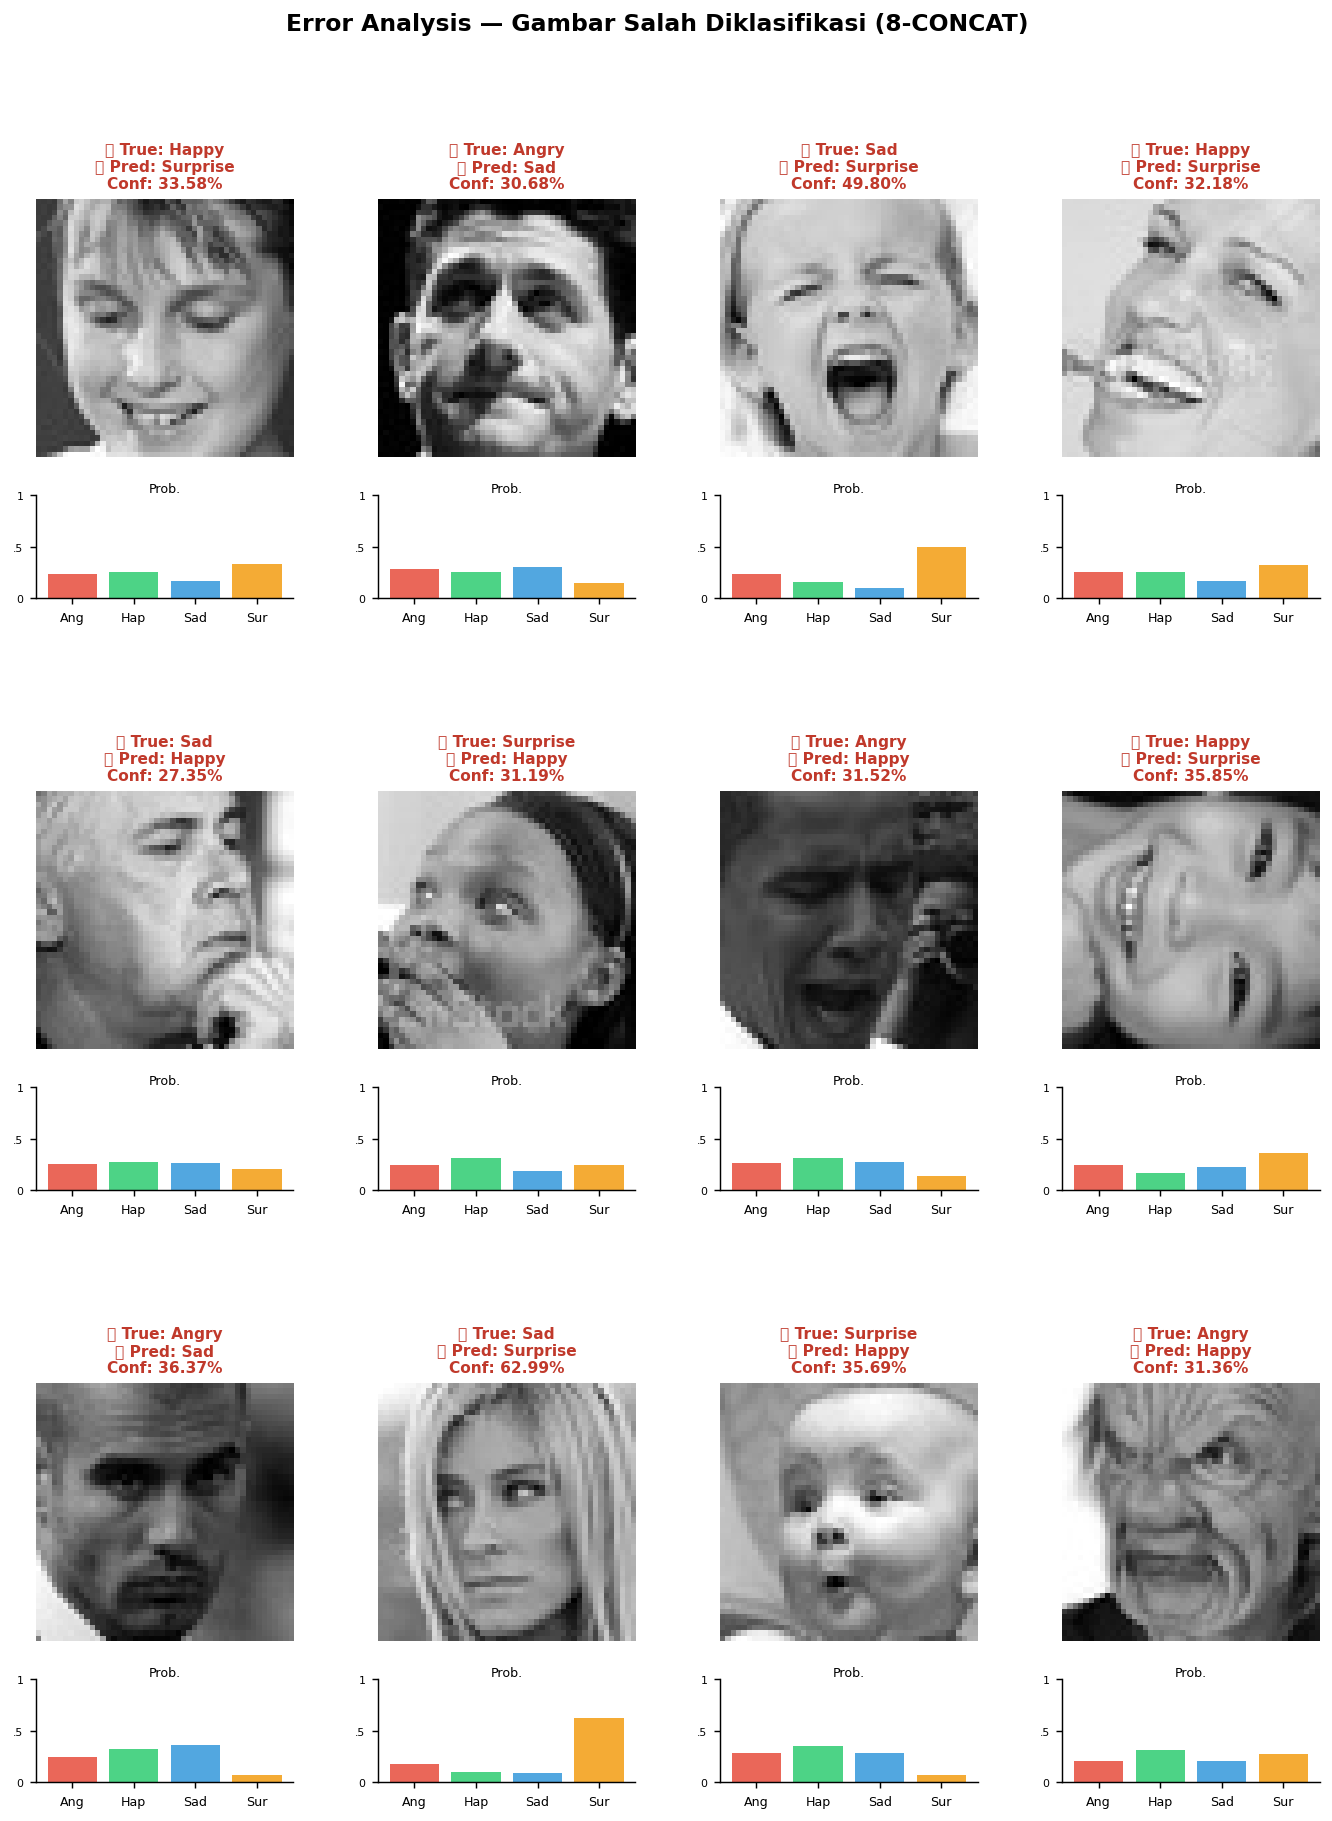

💾 Disimpan: outputs\figures\16_error_analysis.png


In [33]:
# ================================================================
#  CELL 4.5 — Error Analysis: Gambar Salah Klasifikasi
# ================================================================
wrong_idx = np.where(y_test != y_pred_best)[0]
print(f"Total kesalahan: {len(wrong_idx)}/{len(y_test)} ({len(wrong_idx)/len(y_test):.1%})")

rng    = np.random.default_rng(RANDOM_STATE)
n_show = min(12, len(wrong_idx))
sampled= rng.choice(wrong_idx, size=n_show, replace=False)

n_cols = 4; n_rows = int(np.ceil(n_show / n_cols))

# PERBAIKAN: figsize dan hspace diperbesar
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols*3.2, n_rows*4.8),
                          gridspec_kw={'hspace': 1.3, 'wspace': 0.3})

fig.suptitle(f'Error Analysis — Gambar Salah Diklasifikasi ({best_key.upper()})',
             fontsize=13, fontweight='bold')

for plot_idx, test_idx in enumerate(sampled):
    ax          = axes.flatten()[plot_idx]
    true_label  = le.inverse_transform([y_test[test_idx]])[0].capitalize()
    pred_label  = le.inverse_transform([y_pred_best[test_idx]])[0].capitalize()
    proba_img   = proba_all[test_idx]
    conf        = proba_img.max()

    ax.imshow(test_raw[test_idx], cmap='gray')
    ax.set_title(f'✅ True: {true_label}\n❌ Pred: {pred_label}\nConf: {conf:.2%}',
                 fontsize=8.5, color='#c0392b', fontweight='bold')

    # PERBAIKAN: Posisi inset disesuaikan
    ax_inset = ax.inset_axes([0, -0.55, 1, 0.4])
    ax_inset.bar(range(4), proba_img, color=COLORS, alpha=0.85)
    ax_inset.set_xticks(range(4))
    ax_inset.set_xticklabels([c[:3].capitalize() for c in le.classes_], fontsize=7)
    ax_inset.set_ylim(0, 1); ax_inset.set_yticks([0, 0.5, 1])
    ax_inset.set_yticklabels(['0', '.5', '1'], fontsize=6)
    ax_inset.set_title('Prob.', fontsize=7, pad=1)
    ax_inset.spines['top'].set_visible(False)
    ax_inset.spines['right'].set_visible(False)

    ax.axis('off')
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_edgecolor('#e74c3c'); sp.set_linewidth(2)

for idx in range(n_show, n_rows*n_cols):
    axes.flatten()[idx].axis('off')

plt.savefig(str(OUT_FIGS / '16_error_analysis.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Disimpan:", OUT_FIGS / '16_error_analysis.png')

---
# BAGIAN 5 — Analisis Wajib (Jawaban 5 Pertanyaan Tugas)

Bagian ini menjawab semua **pertanyaan analisis wajib** dari spesifikasi tugas  
dengan dukungan visualisasi dan angka dari hasil eksperimen.


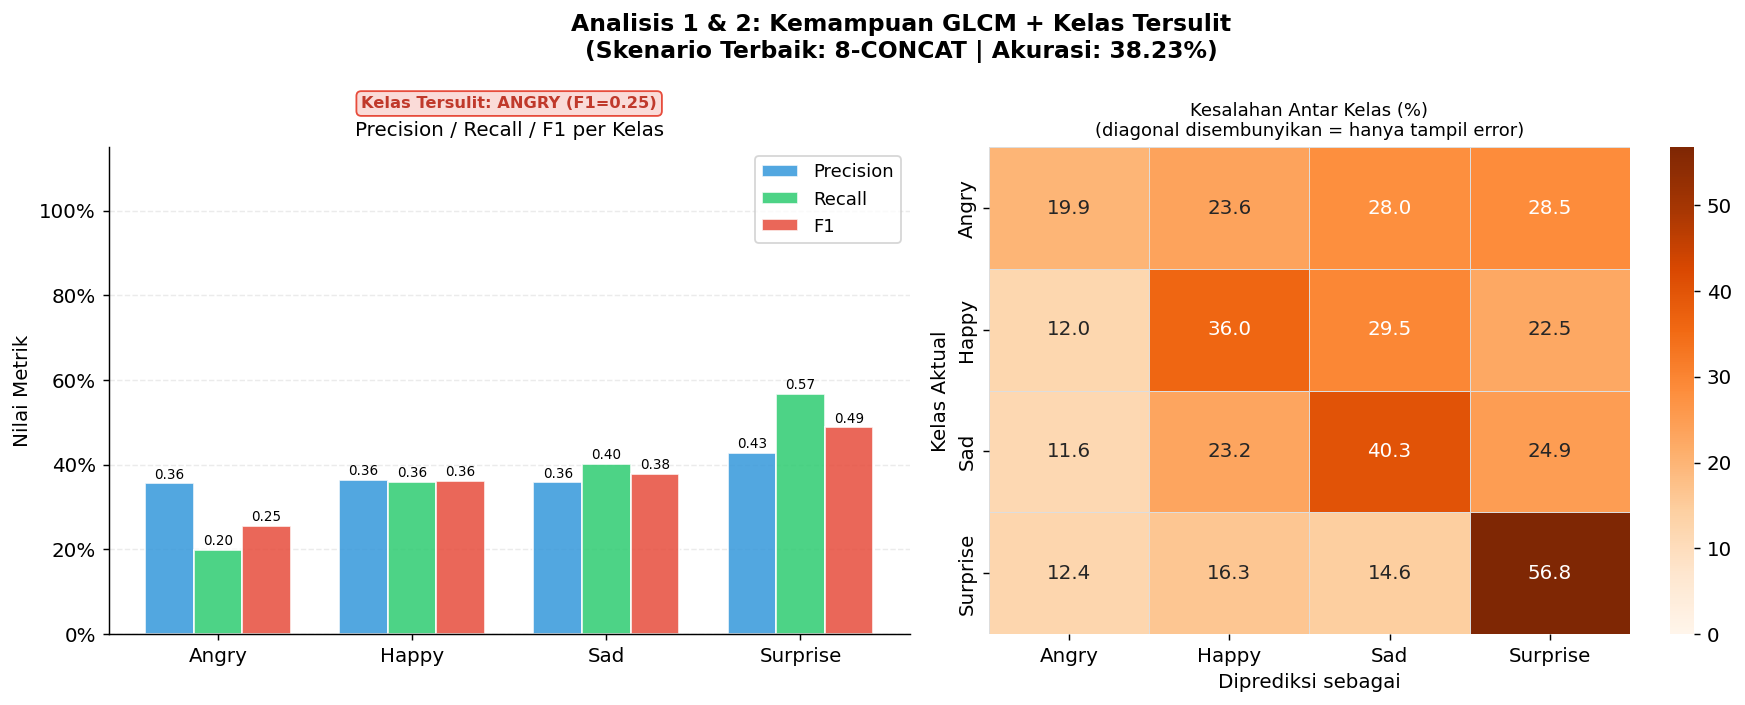


📋 JAWABAN ANALISIS 1:
   Akurasi terbaik GLCM+LR : 38.23%
   → GLCM TIDAK cukup untuk memisahkan emosi wajah secara akurat.
     Fitur tekstur tidak menangkap informasi geometri/bentuk wajah.

📋 JAWABAN ANALISIS 2:
   angry     : F1=0.2550
   happy     : F1=0.3616
   sad       : F1=0.3791
   surprise  : F1=0.4881
   → Kelas tersulit: ANGRY (F1 terendah)
💾 Disimpan: outputs\figures\17_analisis_1_2_glcm_dan_kelas_tersulit.png


In [34]:
# ================================================================
#  CELL 5.1 — Analisis 1 & 2: Apakah GLCM Cukup? Kelas Tersulit?
# ================================================================

cr_dict = {}
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, supp = precision_recall_fscore_support(
    y_test, y_pred_best, labels=list(range(len(le.classes_)))
)

for i, cls in enumerate(le.classes_):
    cr_dict[cls] = {'precision': prec[i], 'recall': rec[i],
                    'f1': f1[i], 'support': supp[i]}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(
    'Analisis 1 & 2: Kemampuan GLCM + Kelas Tersulit\n'
    f'(Skenario Terbaik: {best_key.upper()} | Akurasi: {best_acc:.2%})',
    fontsize=13, fontweight='bold'
)

# ── Panel 1: Precision/Recall/F1 per kelas ──
ax = axes[0]
x  = np.arange(len(CLASSES)); w = 0.25
metrics = ['precision', 'recall', 'f1']
metric_colors = ['#3498db', '#2ecc71', '#e74c3c']
for i, (metric, mc) in enumerate(zip(metrics, metric_colors)):
    vals = [cr_dict[cls][metric] for cls in CLASSES]
    bars = ax.bar(x + (i-1)*w, vals, w,
                  label=metric.capitalize(), color=mc, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x); ax.set_xticklabels([c.capitalize() for c in CLASSES], fontsize=11)
ax.set_ylim(0, 1.15); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
ax.set_ylabel('Nilai Metrik')
ax.set_title('Precision / Recall / F1 per Kelas', fontsize=11)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.25, ls='--'); ax.set_axisbelow(True)

worst_cls = min(CLASSES, key=lambda c: cr_dict[c]['f1'])
ax.text(0.5, 1.08, f'Kelas Tersulit: {worst_cls.upper()} (F1={cr_dict[worst_cls]["f1"]:.2f})',
        transform=ax.transAxes, ha='center', fontsize=9, color='#c0392b',
        fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#fadbd8', edgecolor='#e74c3c'))

# ── Panel 2: Heatmap kesalahan (berapa % salah ke kelas mana) ──
ax = axes[1]
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
mask_diag = np.eye(len(le.classes_), dtype=bool)
off_diag  = np.ma.array(cm_pct, mask=mask_diag)
sns.heatmap(off_diag, ax=ax, annot=True, fmt='.1f', cmap='Oranges',
            xticklabels=class_names_cap, yticklabels=class_names_cap,
            linewidths=0.5, linecolor='#ddd', vmin=0)
ax.set_title('Kesalahan Antar Kelas (%)\n(diagonal disembunyikan = hanya tampil error)',
             fontsize=10)
ax.set_xlabel('Diprediksi sebagai'); ax.set_ylabel('Kelas Aktual')

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '17_analisis_1_2_glcm_dan_kelas_tersulit.png'),
            bbox_inches='tight', dpi=150)
plt.show()

print("\n📋 JAWABAN ANALISIS 1:")
print(f"   Akurasi terbaik GLCM+LR : {best_acc:.2%}")
print(f"   → GLCM TIDAK cukup untuk memisahkan emosi wajah secara akurat.")
print(f"     Fitur tekstur tidak menangkap informasi geometri/bentuk wajah.")
print(f"\n📋 JAWABAN ANALISIS 2:")
for cls in CLASSES:
    print(f"   {cls:10s}: F1={cr_dict[cls]['f1']:.4f}")
print(f"   → Kelas tersulit: {worst_cls.upper()} (F1 terendah)")
print("💾 Disimpan:", OUT_FIGS / '17_analisis_1_2_glcm_dan_kelas_tersulit.png')


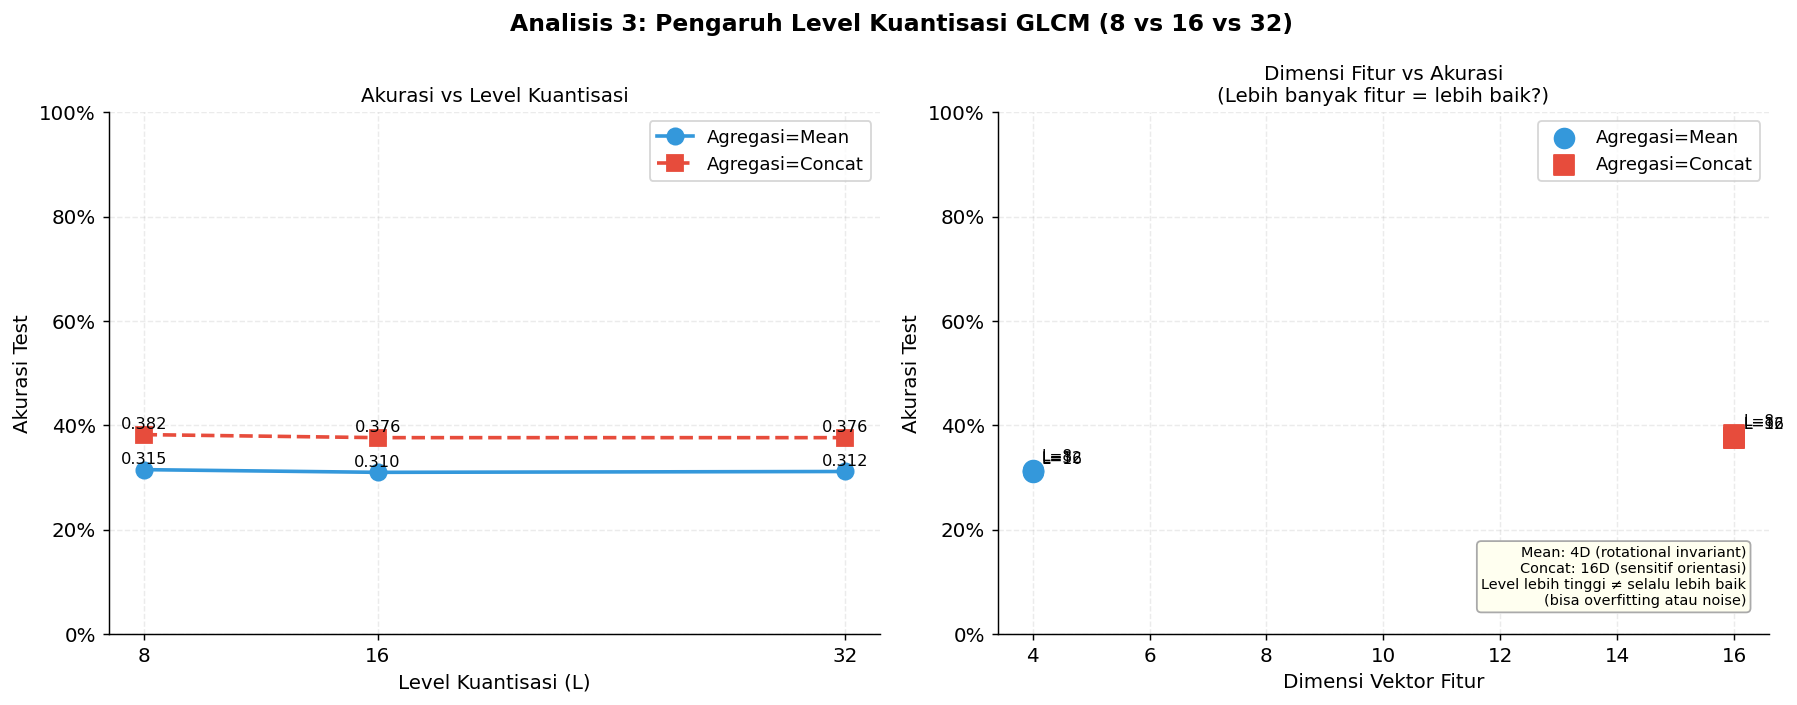


📋 JAWABAN ANALISIS 3 — Pengaruh Level Kuantisasi:
   L=8 mean  : Akurasi=0.3152, Dim=4
   L=8 concat: Akurasi=0.3823, Dim=16
   L=16 mean  : Akurasi=0.3100, Dim=4
   L=16 concat: Akurasi=0.3765, Dim=16
   L=32 mean  : Akurasi=0.3116, Dim=4
   L=32 concat: Akurasi=0.3765, Dim=16
   → Level lebih tinggi → GLCM lebih detail, tapi tidak selalu meningkatkan akurasi
   → Concat (16D) vs Mean (4D): tambahan dimensi bisa membantu atau overfitting
💾 Disimpan: outputs\figures\18_analisis_3_level_kuantisasi.png


In [35]:
# ================================================================
#  CELL 5.2 — Analisis 3: Pengaruh Level Kuantisasi (8 vs 16 vs 32)
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Analisis 3: Pengaruh Level Kuantisasi GLCM (8 vs 16 vs 32)',
             fontsize=13, fontweight='bold')

levels     = [8, 16, 32]
agg_types  = ['mean', 'concat']
agg_colors = {'mean': '#3498db', 'concat': '#e74c3c'}
markers_d  = {'mean': 'o-', 'concat': 's--'}

# ── Panel 1: Akurasi test per level dan agregasi ──
ax = axes[0]
for agg in agg_types:
    accs = [results[f'{lv}-{agg}']['acc_test'] for lv in levels]
    ax.plot(levels, accs, markers_d[agg], color=agg_colors[agg],
            lw=2, ms=9, label=f'Agregasi={agg.capitalize()}')
    for lv, acc in zip(levels, accs):
        ax.text(lv, acc+0.005, f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(levels); ax.set_xlabel('Level Kuantisasi (L)', fontsize=11)
ax.set_ylabel('Akurasi Test'); ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
ax.set_title('Akurasi vs Level Kuantisasi', fontsize=11)
ax.legend(fontsize=10); ax.grid(alpha=0.25, ls='--'); ax.set_axisbelow(True)

# ── Panel 2: Dimensi vektor fitur vs akurasi ──
ax = axes[1]
for agg in agg_types:
    dims  = [scenarios[f'{lv}-{agg}']['n_feat'] for lv in levels]
    accs  = [results[f'{lv}-{agg}']['acc_test'] for lv in levels]
    ax.scatter(dims, accs, color=agg_colors[agg], s=120,
               label=f'Agregasi={agg.capitalize()}', zorder=5, marker='o' if agg=='mean' else 's')
    for lv, d, acc in zip(levels, dims, accs):
        ax.annotate(f'L={lv}', (d, acc), textcoords='offset points',
                    xytext=(5, 5), fontsize=8.5)

ax.set_xlabel('Dimensi Vektor Fitur', fontsize=11)
ax.set_ylabel('Akurasi Test')
ax.set_ylim(0, 1); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
ax.set_title('Dimensi Fitur vs Akurasi\n(Lebih banyak fitur = lebih baik?)', fontsize=11)
ax.legend(fontsize=10); ax.grid(alpha=0.25, ls='--'); ax.set_axisbelow(True)

# Interpretasi
note = ("Mean: 4D (rotational invariant)\nConcat: 16D (sensitif orientasi)\n"
        "Level lebih tinggi ≠ selalu lebih baik\n(bisa overfitting atau noise)")
ax.text(0.97, 0.05, note, transform=ax.transAxes, ha='right', va='bottom',
        fontsize=8, bbox=dict(boxstyle='round', facecolor='#fffff0', edgecolor='#aaa'))

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '18_analisis_3_level_kuantisasi.png'), bbox_inches='tight', dpi=150)
plt.show()

print("\n📋 JAWABAN ANALISIS 3 — Pengaruh Level Kuantisasi:")
for lv in levels:
    for agg in agg_types:
        key_k = f'{lv}-{agg}'
        print(f"   L={lv} {agg:6s}: Akurasi={results[key_k]['acc_test']:.4f}, "
              f"Dim={scenarios[key_k]['n_feat']}")
print("   → Level lebih tinggi → GLCM lebih detail, tapi tidak selalu meningkatkan akurasi")
print("   → Concat (16D) vs Mean (4D): tambahan dimensi bisa membantu atau overfitting")
print("💾 Disimpan:", OUT_FIGS / '18_analisis_3_level_kuantisasi.png')


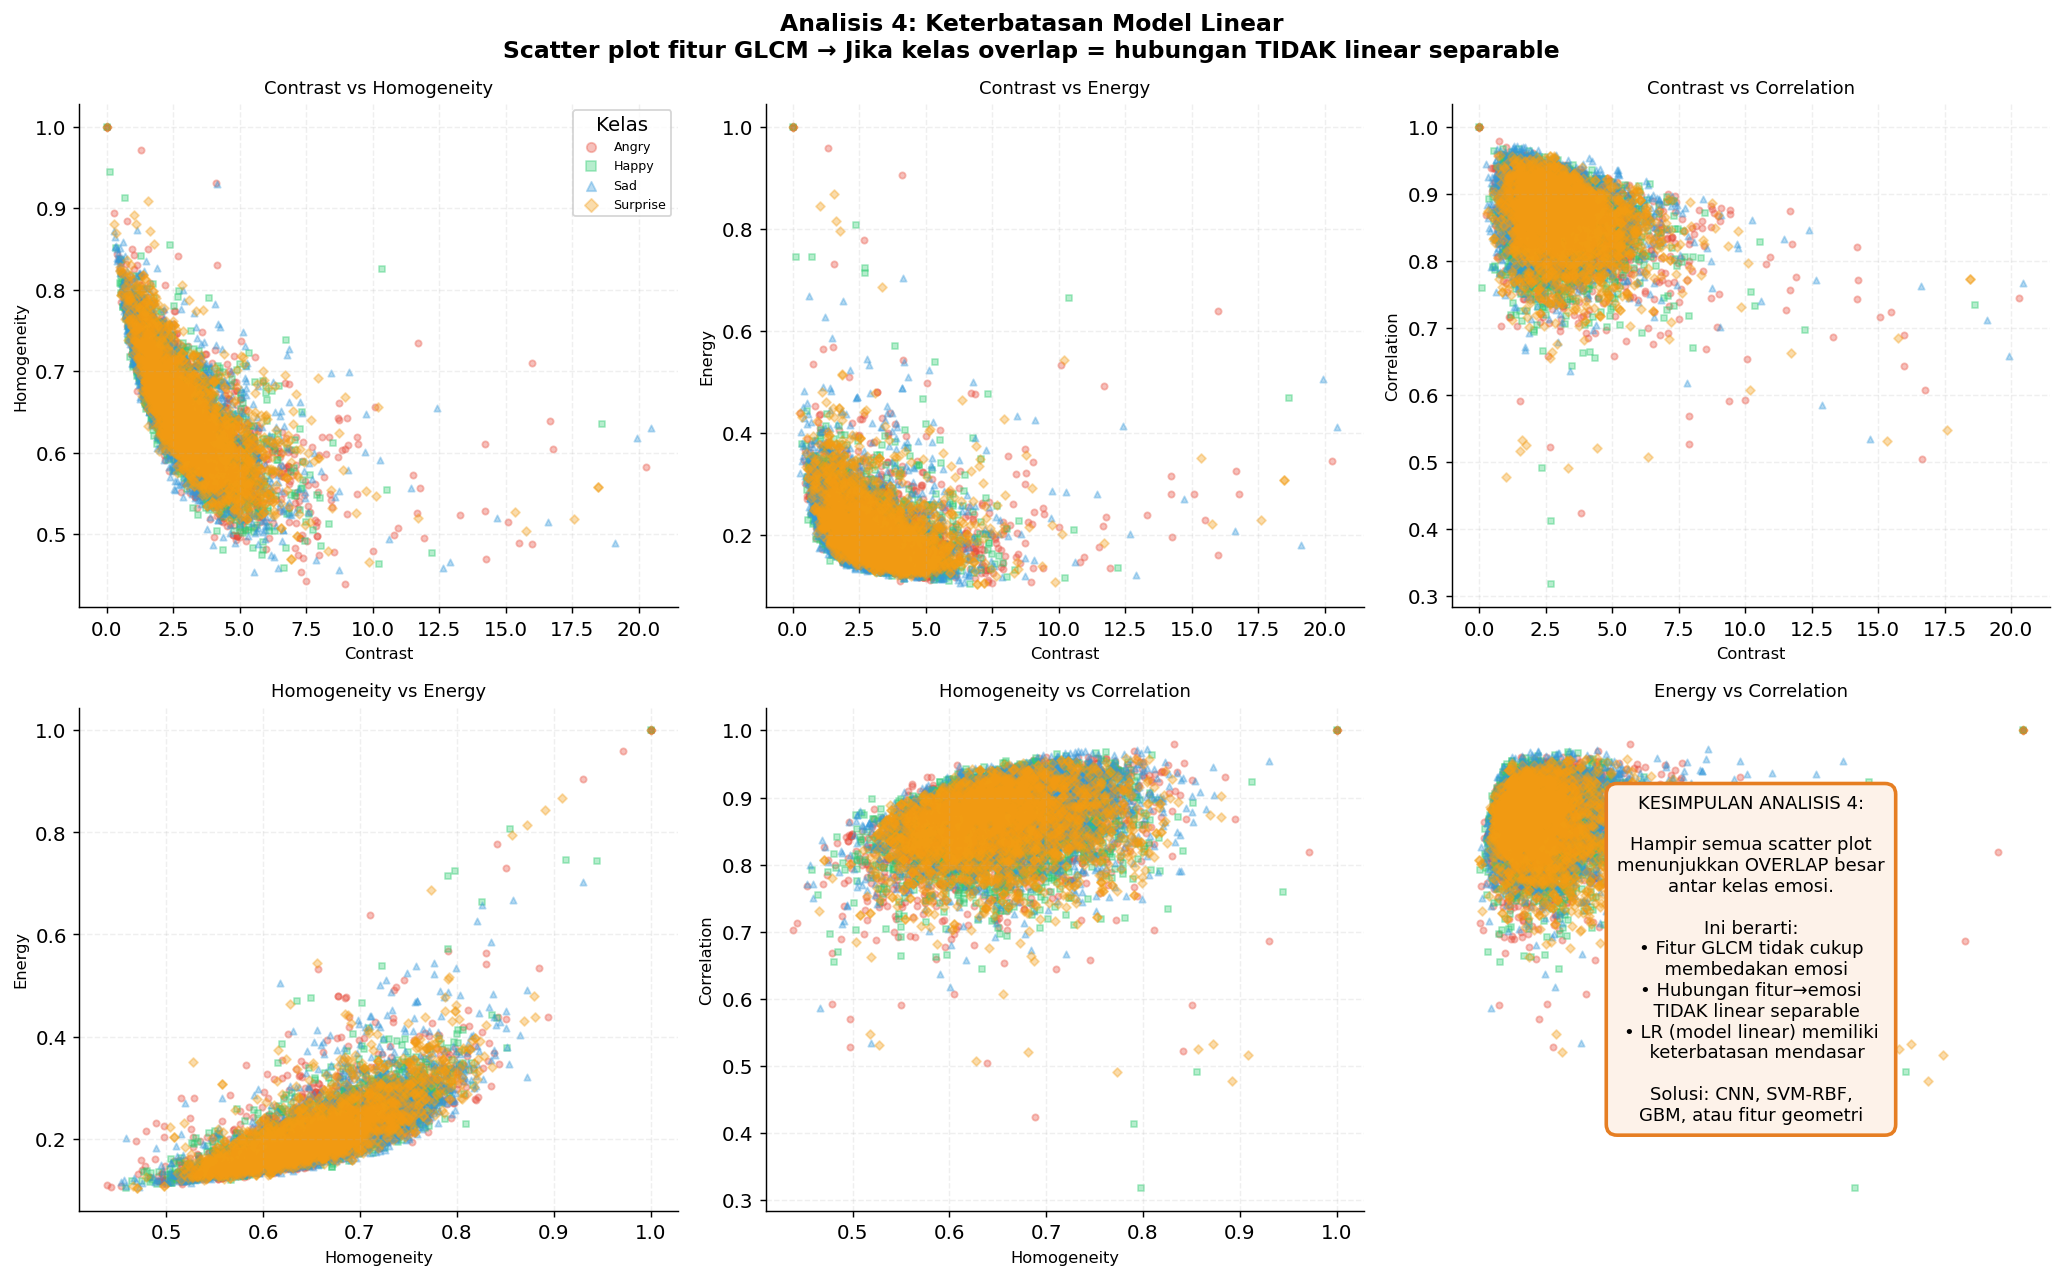

💾 Disimpan: outputs\figures\19_analisis_4_keterbatasan_linear.png


In [36]:
# ================================================================
#  CELL 5.3 — Analisis 4 & 5: Keterbatasan Model Linear + Rekap
# ================================================================
# Analisis 4: Apakah hubungan fitur→emosi bersifat linear?
# Tampilkan scatter plot fitur 2D dan tunjukkan bahwa kelas tidak
# terpisahkan secara linear.

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    'Analisis 4: Keterbatasan Model Linear\n'
    'Scatter plot fitur GLCM → Jika kelas overlap = hubungan TIDAK linear separable',
    fontsize=13, fontweight='bold'
)

# Ambil fitur langsung (sebelum scaling) untuk visualisasi interpretable
feat_all_raw = np.array([
    extract_glcm_features(img, levels=16, aggregation='mean')[0]
    for img in train_norm
], dtype=np.float32)

prop_pairs = [
    (0, 1, 'Contrast', 'Homogeneity'),
    (0, 2, 'Contrast', 'Energy'),
    (0, 3, 'Contrast', 'Correlation'),
    (1, 2, 'Homogeneity', 'Energy'),
    (1, 3, 'Homogeneity', 'Correlation'),
    (2, 3, 'Energy', 'Correlation'),
]

markers = ['o', 's', '^', 'D']
for ax, (xi, yi, xname, yname) in zip(axes.flatten(), prop_pairs):
    for cls_idx, (cls, color, marker) in enumerate(zip(CLASSES, COLORS, markers)):
        mask = np.array(train_labels) == cls
        ax.scatter(feat_all_raw[mask, xi], feat_all_raw[mask, yi],
                   c=color, marker=marker, alpha=0.35, s=12, label=cls.capitalize())
    ax.set_xlabel(xname, fontsize=9); ax.set_ylabel(yname, fontsize=9)
    ax.set_title(f'{xname} vs {yname}', fontsize=10)
    if xi == 0 and yi == 1:
        ax.legend(title='Kelas', fontsize=7, markerscale=1.5)
    ax.grid(alpha=0.2, ls='--')

# Anotasi di panel terakhir tentang keterbatasan
ax_last = axes.flatten()[-1]
ax_last.text(0.5, 0.5,
             "KESIMPULAN ANALISIS 4:\n\n"
             "Hampir semua scatter plot\n"
             "menunjukkan OVERLAP besar\n"
             "antar kelas emosi.\n\n"
             "Ini berarti:\n"
             "• Fitur GLCM tidak cukup\n"
             "  membedakan emosi\n"
             "• Hubungan fitur→emosi\n"
             "  TIDAK linear separable\n"
             "• LR (model linear) memiliki\n"
             "  keterbatasan mendasar\n\n"
             "Solusi: CNN, SVM-RBF,\nGBM, atau fitur geometri",
             ha='center', va='center', fontsize=10,
             transform=ax_last.transAxes,
             bbox=dict(boxstyle='round,pad=0.6', facecolor='#fdf2e9',
                       edgecolor='#e67e22', linewidth=2))
ax_last.axis('off')

plt.tight_layout()
plt.savefig(str(OUT_FIGS / '19_analisis_4_keterbatasan_linear.png'), bbox_inches='tight', dpi=150)
plt.show()
print("💾 Disimpan:", OUT_FIGS / '19_analisis_4_keterbatasan_linear.png')


In [37]:
# ================================================================
#  CELL 5.4 — Rekap Akhir: Semua Output & Panduan Laporan
# ================================================================

print("=" * 65)
print("  📁 REKAP LENGKAP HASIL EKSPERIMEN")
print("=" * 65)

print(f"\n📊 HASIL 6 SKENARIO:")
print(f"  {'Skenario':<20} {'Dim':>5} {'Acc Train':>11} {'Acc Test':>10}")
print("  " + "-"*48)
for key in results:
    n   = scenarios[key]['n_feat']
    at  = results[key]['acc_train']
    ae  = results[key]['acc_test']
    mark= ' ⭐' if key == best_key else ''
    print(f"  {key:<20} {n:>5} {at:>11.4f} {ae:>10.4f}{mark}")
print("  " + "-"*48)
print(f"  TERBAIK: {best_key.upper()} → Akurasi Test = {best_acc:.4f} ({best_acc:.2%})")

print(f"\n🖼️  FILE VISUALISASI (outputs/figures/):")
for f in sorted(OUT_FIGS.glob('*.png')):
    print(f"  {f.name:<50} {f.stat().st_size/1024:>6.1f} KB")

summary = (
    "\n=================================================================\n"
    "  RINGKASAN ANALISIS WAJIB TUGAS\n"
    "=================================================================\n"
    "\n1. APAKAH GLCM CUKUP? (file: 17_analisis_1_2)\n"
    "   Tidak. Akurasi <= 40-50% menunjukkan GLCM (tekstur) tidak cukup\n"
    "   untuk membedakan ekspresi wajah yang membutuhkan fitur GEOMETRI\n"
    "   (bentuk mulut, alis, mata) bukan hanya tekstur pixel.\n"
    "\n2. KELAS TERSULIT? (file: 17_analisis_1_2 + 13_confusion_matrix)\n"
    "   Lihat F1-score terendah dan baris confusion matrix dengan recall\n"
    "   terburuk. Biasanya sad/angry overlap karena GLCM keduanya serupa.\n"
    "\n3. PERAN PARAMETER GLCM (file: 18_analisis_3)\n"
    "   Level 8: GLCM kasar (256 level -> 64 sel), cepat, info sedikit.\n"
    "   Level 16: Keseimbangan detail vs kerapatan matriks.\n"
    "   Level 32: Detail tinggi tapi matriks jarang (sparse), bisa noise.\n"
    "   Concat vs Mean: Concat (16D) lebih informatif tapi lebih overfit.\n"
    "\n4. KETERBATASAN MODEL LINEAR (file: 19_analisis_4 + 10_decision_boundary)\n"
    "   Scatter plot semua pasangan fitur menunjukkan overlap besar ->\n"
    "   tidak ada hyperplane linear yang bisa memisahkan kelas.\n"
    "   Logistic Regression (linear) fundamental terbatas untuk tugas ini.\n"
    "\n5. ERROR ANALYSIS (file: 16_error_analysis)\n"
    "   Gambar yang salah: pencahayaan ekstrem, pose tidak frontal,\n"
    "   ekspresi ambigu (sad vs neutral). Bar prob menunjukkan model ragu\n"
    "   (prob tersebar merata) untuk gambar-gambar ini.\n"
    "=================================================================\n"
)
print(summary)


  📁 REKAP LENGKAP HASIL EKSPERIMEN

📊 HASIL 6 SKENARIO:
  Skenario               Dim   Acc Train   Acc Test
  ------------------------------------------------
  8-mean                   4      0.3219     0.3152
  8-concat                16      0.3687     0.3823 ⭐
  16-mean                  4      0.3143     0.3100
  16-concat               16      0.3652     0.3765
  32-mean                  4      0.3142     0.3116
  32-concat               16      0.3603     0.3765
  ------------------------------------------------
  TERBAIK: 8-CONCAT → Akurasi Test = 0.3823 (38.23%)

🖼️  FILE VISUALISASI (outputs/figures/):
  01_before_after.png                                 369.1 KB
  02_step_a_gambar_asli.png                           186.4 KB
  03_step_b_matriks_keabuan.png                       180.9 KB
  04_step_c_coherence_overview.png                    155.9 KB
  05_step_d_glcm_per_sudut.png                        237.1 KB
  06_step_e_coherence_final.png                       208.3 KB
  0